# Molecular representations and visualizations

In this section, we study how RDKit handles different molecular representations and visualizations.



Let's install some packages first. We can do this directly from the notebook:

In [1]:
%pip install py3Dmol networkx seaborn rdkit ipywidgets tqdm chembl_webresource_client

Note: you may need to restart the kernel to use updated packages.


1. Import all necessary libraries

First, we need to import all necessary libraries and modules for data visualization, network analysis, numerical operations, 3D visualization of molecular structures, and chemoinformatics:

In [2]:
# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import networkx for creating, manipulating, and studying the structure, dynamics, and functions of complex networks
import networkx as nx

# Import numpy for handling large, multi-dimensional arrays and matrices of numeric data
import numpy as np

# Import time to track how long operations take
import time

import copy

from ipywidgets import interact, fixed

# Import RDKit, a collection of cheminformatics and machine learning tools
from rdkit import Chem

# Import IPythonConsole from RDKit for better integration with Jupyter Notebook
from rdkit.Chem.Draw import IPythonConsole

# Import Draw from RDKit for molecule drawing
from rdkit.Chem import Draw, PandasTools

# Import AllChem and rdDistGeom from RDKit for various chemoinformatics operations
from rdkit.Chem import AllChem, rdDistGeom

# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import py3Dmol for 3D visualization of molecular structures
import py3Dmol

# Set RDKit to use SVG graphics in Jupyter Notebook (better quality images)
IPythonConsole.ipython_useSVG = True
PandasTools.RenderImagesInAllDataFrames(images=True)
PandasTools.molRepresentation='svg'

In [3]:
import rdkit

print(rdkit.__version__)

2025.03.1


The last line sets the RDKit to use SVG (Scalable Vector Graphics) for generating images, which are more scalable and maintain quality at any resolution compared to raster graphics.

2. We define the caffeine molecule based on a SMILES string and find the visualization in a line-angle formula:

In [4]:
# coffeine smiles string
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"

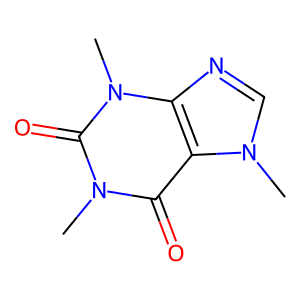

In [5]:
# Here define caffeine molecule from Smiles and show it.


caffeine_mols = Chem.MolFromSmiles(caffeine_smiles)

img = Draw.MolToImage(caffeine_mols)
img

3. Presentation of chirality. 2-Butanol molecule has two configurations that are mirror images of each other (they are enantiomers):

In [6]:
mol_smiles = "CC[CH](C)O" # without chiral information
mol_smiles_en_1 = "CC[C@H](C)O" # enantiomer 1 - The [C@H] part specifies a stereocenter (carbon) with one hydrogen explicitly defined.
mol_smiles_en_2 = "CC[C@@H](C)O" # enantiomer 2 - The [C@@H] part specifies a stereocenter (carbon) with one hydrogen explicitly defined.

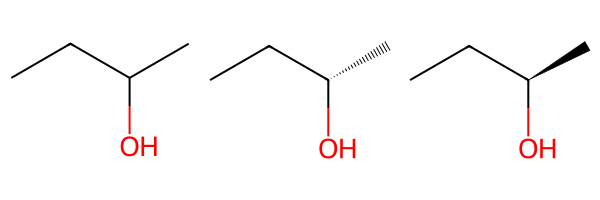

In [7]:
# show this 3 mols as grid (1 row, 3 col) - use RDKit Draw module
list_of_smiles = [mol_smiles,mol_smiles_en_1,mol_smiles_en_2]

mols_list = []
for smiles in list_of_smiles:
    mols_list.append(Chem.MolFromSmiles(smiles))


Draw.MolsToGridImage(mols=mols_list)



An alternative to NGLView is Py3DMol. It allows us to view a ball-and-stick visualization:

In [8]:
# function for 3D visualisation
def drawit(mols, chiral_idx=2):
    for m in mols:
        # Create a Py3Dmol viewer
        view = py3Dmol.view(width=400, height=400)
        # Convert the molecule to a MolBlock string
        mb = Chem.MolToMolBlock(m)
        view.addModel(mb, 'sdf')
        # Use stick style for bonds and add spheres for atoms
        view.setStyle({'stick':{'colorscheme':'cyanCarbon', 'radius': 0.1}, 
                       'sphere':{'scale':0.25}})
        
        # Highlight the chiral center:
        # Get the coordinates of the chiral center (adjust the atom index if needed)
        conf = m.GetConformer()
        pos = conf.GetAtomPosition(chiral_idx)
        view.addSphere({
            'center': {'x': pos.x, 'y': pos.y, 'z': pos.z},
            'radius': 0.3,
            'color': 'red',
            'alpha': 0.6
        })
        
        view.setBackgroundColor('0xeeeeee')
        view.zoomTo()
        view.show()

In [9]:
# Generate 3D coordinates for second molecule that you generated from mol_smiles_en_1 (enantiomer 1)
second_molecule=mols_list[1]

AllChem.EmbedMolecule(second_molecule, randomSeed=0xf00d, useExpTorsionAnglePrefs=True, useBasicKnowledge=True)



drawit([second_molecule])

[13:23:00] Molecule does not have explicit Hs. Consider calling AddHs()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
# Generate 3D coordinates for third molecule that you generated from mol_smiles_en_2 (enantiomer 2)

third_molecule = mols_list[2]
AllChem.EmbedMolecule(third_molecule, randomSeed=0xf00d, useExpTorsionAnglePrefs=True, useBasicKnowledge=True)

drawit([third_molecule])

[13:23:00] Molecule does not have explicit Hs. Consider calling AddHs()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
# Visualize enantiomer 1 and enantiomer 2 side by side with highlighted chiral centers (so the difference can be obvious)
drawit([second_molecule, third_molecule])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Now you can compare enantiomers using 3D structures.

4. Conformers

We can generate a set of n conformers using rdkit’s conformer generator. Molecules are not rigid. They can adopt various 3D shapes (conformers) due to rotations around single bonds. Conformers represent different 3D shapes a molecule can adopt due to rotations around single bonds. Generating 200 conformers provides a good sample size for analysis.

**Question: Why do we need to generate conformers?**

We use aspirin as example molecule for generating conformers.

In [12]:
# generate molecule from aspirin_smiles
aspirin_smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"

# code for that
aspirin = Chem.MolFromSmiles(aspirin_smiles)

Add explicit hydrogens

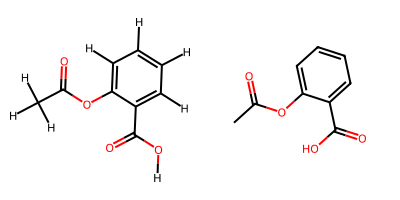

In [13]:
# add explicit hydrogens to aspirin molecule
aspirin_with_h = Chem.AddHs(aspirin)

Draw.MolsToGridImage([aspirin_with_h, aspirin], molsPerRow=2, subImgSize=(200, 200))

Here you've created a new molecule object called `aspirin_h` by adding explicit hydrogens to the aspirin molecule.

RDKit relies on explicit hydrogens for conformer generation. Hydrogens define the bonding environment and allow for proper calculation of different 3D arrangements (conformers).

Generate 200 conformers

In [14]:
# generate conformers
# 1-st way
num_conformers = 200

copy_aspirin_with_h_1 = copy.deepcopy(aspirin_with_h)

# Creates an RDKit conformer generation object using the ETKDGv3 algorithm
ps = rdDistGeom.ETKDGv3()
# Sets a random seed for reproducibility (optional, ensures the same conformers are generated each time with this seed).
ps.randomSeed = 0xD06F00D
# Sets the number of threads to use for faster calculation (utilizes 10 CPU cores if available).
ps.numThreads = 10

# This is the core line. It generates 200 conformers (num_conformers) for the molecule in copy_aspirin_with_h_1 using the settings defined in ps.
# The function returns a list of conformer IDs stored in conf_ids variable.
start_time_method_1 = time.time()
conf_ids_1 = rdDistGeom.EmbedMultipleConfs(copy_aspirin_with_h_1, num_conformers, ps)
end_time_method_1 = time.time()

# confirming successful generation of 200 conformers
print(f"Number of conformers generated 1-st way: {len(conf_ids_1)}")
print(f"Number of conformers for copy_aspirin_with_h_1: {copy_aspirin_with_h_1.GetNumConformers()}")
print(f"Number of conformers for aspirin_with_h: {aspirin_with_h.GetNumConformers()}")

Number of conformers generated 1-st way: 200
Number of conformers for copy_aspirin_with_h_1: 200
Number of conformers for aspirin_with_h: 0


The Role of Random Seed:

*   A random seed is a specific number used to initialize the random number generator within the algorithm.
*   By setting the same random seed for multiple runs, you ensure the algorithm uses the same sequence of random numbers.
*   This guarantees that the exact same conformers are generated each time you run the code with that specific seed.

--> For reproducibility on each iteration



In [15]:
# generate conformers
# 2-nd way
copy_aspirin_with_h_2 = copy.deepcopy(aspirin_with_h)

# Generate multiple conformers
start_time_method_2 = time.time()
conf_ids_2 = AllChem.EmbedMultipleConfs(copy_aspirin_with_h_2, numConfs=num_conformers)
end_time_method_2 = time.time()

# confirming successful generation of 200 conformers
print(f"Number of conformers generated 2-st way: {len(conf_ids_2)}")
print(f"Number of conformers for copy_aspirin_with_h_2: {copy_aspirin_with_h_2.GetNumConformers()}")
print(f"Number of conformers for aspirin_with_h: {aspirin_with_h.GetNumConformers()}")

Number of conformers generated 2-st way: 200
Number of conformers for copy_aspirin_with_h_2: 200
Number of conformers for aspirin_with_h: 0


**What is the difference between this 2 ways? Where should we use 1-st? Where 2-nd?**

The two methods both used to generate conformers for a molecule, but they differ in the level of control and customization they offer:


*   ***First Method (ETKDGv3)***: This method uses the ETKDGv3 algorithm for conformer generation. It allows for a high degree of customization and control over the process. You can set a random seed for reproducibility, which ensures that the same conformers are generated each time with this seed. You can also set the number of threads to use for faster calculation if multiple CPU cores are available. This method is more suitable when you need to generate a large number of conformers and have specific requirements for the generation process.
This method is **more suitable when we have specific requirements for the conformer generation process**.

  *   If we need to ensure that the same conformers are generated each time you run the code, you can set a random seed. This is useful in research settings where *reproducibility* of results is important.
  *   If we’re working with a large molecule or a large number of conformers, *performance* might be a concern. In such cases, we can set the number of threads to use for the calculation to speed up the process.
  *   The ETKDGv3 algorithm used in this method offers several parameters that we can tweak to *customize the conformer generation process*.


*   ***Second Method (AllChem.EmbedMultipleConfs)***: This method is a simpler and more straightforward way to generate conformers. It doesn’t offer as much control over the process as the first method, but it’s easier to use and requires fewer lines of code. This method is more suitable when you just need to quickly generate a set number of conformers without any specific requirements.
This method is **simpler and more straightforward, making it more suitable for general use cases**.

  *   If you’re *new to RDKit or chemoinformatics*, or if *you don’t have any specific requirements for the conformer generation process*, this method is easier to use. It requires fewer lines of code and less understanding of the underlying algorithm.
  *   If you’re *quickly prototyping or testing an idea*, this method allows you to generate conformers with minimal code.
  *    If you *don’t need the level of control and customization* offered by the first method, this method is a good choice. It’s a versatile method that can handle a wide range of molecules and conditions.


Both methods generate conformers and return a list of conformer IDs. The choice between the two methods depends on specific needs and requirements. If you need more control and customization, the first method is a better choice. If you prefer simplicity and ease of use, the second method is more suitable.



In [16]:
# A molecule can have multiple conformers attached:

copy_aspirin_with_h_1.GetNumConformers()

200

In [17]:
# get first conformer
conformer = copy_aspirin_with_h_1.GetConformer(conf_ids_1[0])

conformer

In [18]:
# check if it is represented in 3D
conformer.Is3D()

True

In [19]:
def drawit_conformers_set(m,p=None,confId=-1):
    p.removeAllModels()
    mb = Chem.MolToMolBlock(m, confId=confId)
    p.addModel(mb, 'sdf')
    p.setStyle({'stick':{'colorscheme':'cyanCarbon', 'radius': 0.1}, 'sphere':{'scale':0.25}})
    p.setBackgroundColor('0xeeeeee')
    p.zoomTo()
    return p.show()

def view_conformers(mol, width=400, height=400):
    p = py3Dmol.view(width=width, height=height)
    print(f"Number of conformers for this molecule: {mol.GetNumConformers()}")
    interact(drawit_conformers_set, m=fixed(mol), p=fixed(p), confId=(0, mol.GetNumConformers()-1));

In [20]:
view_conformers(copy_aspirin_with_h_1)

Number of conformers for this molecule: 200


interactive(children=(IntSlider(value=0, description='confId', max=199), Output()), _dom_classes=('widget-inte…

In [21]:
# Get the first conformer
first_conformer = copy_aspirin_with_h_1.GetConformer(0)

first_conformer

This method retrieves first conformer (indexing starts from 0) from the set of conformers generated earlier.

In [22]:
# print the x,y,z coordinates of the 4 atoms of the first conformer.
positions = first_conformer.GetPositions()

positions

array([[ 3.15987641e+00,  1.17566666e+00,  5.56089570e-01],
       [ 1.96983490e+00,  4.51907070e-01,  2.90463360e-03],
       [ 1.90241828e+00,  1.05413955e-01, -1.20424633e+00],
       [ 9.22339350e-01,  1.72063798e-01,  8.90885106e-01],
       [-1.76149064e-01, -4.99241011e-01,  3.67780467e-01],
       [-1.63191875e-01, -1.87917661e+00,  4.03548104e-01],
       [-1.25154159e+00, -2.54770083e+00, -1.14652121e-01],
       [-2.33914499e+00, -1.87201267e+00, -6.61153961e-01],
       [-2.29972394e+00, -4.98815617e-01, -6.71155758e-01],
       [-1.23281320e+00,  2.13872885e-01, -1.64384406e-01],
       [-1.23221614e+00,  1.67320227e+00, -1.95212054e-01],
       [-2.23673766e+00,  2.27885436e+00, -6.99583031e-01],
       [-1.42211808e-01,  2.36024728e+00,  3.23420532e-01],
       [ 3.97088207e+00,  1.06751457e+00, -2.08381732e-01],
       [ 3.48580005e+00,  7.37931027e-01,  1.52508302e+00],
       [ 2.92241659e+00,  2.25525623e+00,  6.48923204e-01],
       [ 6.30913437e-01, -2.47219771e+00

 This method is applied to the retrieved conformer. It extracts the x, y, and z coordinates of all atoms in that specific conformer.

 The result is a NumPy array where each row represents the (x, y, z) coordinates for a single atom.

**How can you use the positions directly in your analysis?**


*   **Distance Calculations**: You can calculate the distance between pairs of atoms, which can be useful in understanding the 3D structure of the molecule
*   **Angle Calculations**: You can calculate the angle between three atoms, which can be useful in understanding the 3D structure of the molecule.

Such geometric meassures can also be used as input to machine learning methods, i.e. representing molecules in internal coordinates instead of cartesian xyz coordinates.


In [23]:
# Positions of atom is your array of atomic coordinates
atom1_pos = positions[0]
atom2_pos = positions[1]

distance = np.linalg.norm(atom1_pos - atom2_pos)
print(f"Distance between atom 1 and atom 2: {distance:.3f} Å")

Distance between atom 1 and atom 2: 1.499 Å


In [24]:
# Assuming positions is your array of atomic coordinates
atom1_pos = positions[0]
atom2_pos = positions[1]
atom3_pos = positions[2]

vector1 = atom1_pos - atom2_pos
vector2 = atom3_pos - atom2_pos

cosine_angle = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))
angle = np.arccos(cosine_angle)

print(f"Angle between atom 1, atom 2 and atom 3: {np.degrees(angle):.3f} °")

Angle between atom 1, atom 2 and atom 3: 121.998 °


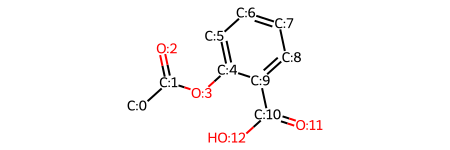

In [25]:
# 2D
import copy

mol_with_idx = copy.deepcopy(aspirin)

# draw the molecule with property
for i, atom in enumerate(mol_with_idx.GetAtoms()):
    atom.SetProp("molAtomMapNumber", str(atom.GetIdx()))

mol_with_idx

In [26]:
drawit([copy_aspirin_with_h_1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

----------------------------------------------------------------

**But `aspirin` is a molecule without hydrogens and `aspirin_3d` is a molecule without hydrogens. What is the difference? Why can't we use `aspirin` ?**

Both aspirin and aspirin_3d in the provided code represent the same molecule without explicit hydrogens.

But:
*   `aspirin`: This represents the initial molecule loaded from the SMILES string. It does not have explicit hydrogens.
*   `aspirin_h`: This molecule is created by adding hydrogens to aspirin. This step is necessary for conformer generation because RDKit relies on explicit hydrogens to determine the bonding environment and calculate appropriate conformations.
*   `aspirin_3d`: After generating conformers using aspirin_h, the hydrogens are removed again using Chem.RemoveHs. This is done because some cheminformatics tasks (like property calculation) might not require explicit hydrogens. However, the crucial point is that aspirin_3d retains the conformational information generated based on the temporary aspirin_h with hydrogens.

Conclusion:

1.   `aspirin_3d` retains conformer information even after hydrogens are removed
2.   `aspirin` (the original molecule) doesn't have the conformer information because it wasn't used for conformer generation.




-------------------------------------------------------------------

# Molecular Representation as a Graph

A molecule can also be represented as a graph, consisting of nodes (atoms) connected by edges (bonds). Representing a molecule in such a way can be advantageous since graph theory is a very mature field, with algorithms available to solve many of the problems that crop up in chemoinformatics.

The adjacency matrix, the node attribute matrix, and the edge attribute network provide a way to capture the structure and properties of the molecule in a format that can be easily processed by computational methods, particularly those used in machine learning and data analysis.

Here's how to create the adjacency matrix, node attribute matrix, and edge attribute network for caffeine from SMILES using RDKit:

In [27]:
# define the smiles string and covert it into a molecule sturcture
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"

# Here define caffeine molecule from Smiles and show it.
mol = Chem.MolFromSmiles(caffeine_smiles)

The ***adjacency matrix*** is a square matrix where each entry adjacency_matrix[i][j] is 1 if there is a bond between atoms i and j, and 0 otherwise. This represents the connectivity of the atoms in the molecule. Each entry in the matrix indicates whether a pair of atoms are bonded or not. This captures the basic structure of the molecule.

An adjacency matrix is a mathematical representation of a graph, which is a set of objects (in this case, atoms) where some pairs of the objects are connected by links (in this case, bonds).

In an adjacency matrix, each row and each column represent an atom in the molecule, and the value in the i-th row and j-th column is 1 if there is a bond between atom i and atom j, and 0 otherwise.

In [28]:
def create_adjacency_matrix(mol):
    n_atoms = mol.GetNumAtoms()
    adjacency_matrix = np.zeros((n_atoms, n_atoms))
    for atom in mol.GetAtoms():
        i = atom.GetIdx()
        for neighbor in atom.GetNeighbors():
            j = neighbor.GetIdx()
            adjacency_matrix[i][j] = 1
    return adjacency_matrix

In [29]:
adjacency_matrix = create_adjacency_matrix(mol)

adjacency_matrix

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

This adjacency matrix represents a molecule with 14 atoms. Each row and each column corresponds to an atom in the molecule. The value at the intersection of row i and column j (i.e., adjacency_matrix[i][j]) is 1 if there is a bond between atom i and atom j, and 0 otherwise.

For example:

*   Row 1, Column 2 is 1, indicating that Atom 1 and Atom 2 are bonded.
*   Row 2, Column 1 is 1, which is the same bond as above (since bonding is mutual, the adjacency matrix is symmetric along the diagonal).
*   Row 2, Column 3 and Row 3, Column 2 are 1, indicating that Atom 2 and Atom 3 are bonded.
*   Row 2, Column 6 and Row 6, Column 2 are 1, indicating that Atom 2 and Atom 6 are bonded.

This adjacency matrix is a compact way to represent the bonding structure of a molecule. It tells you which atoms are directly bonded to each other.


The ***node attribute matrix*** is a matrix where each row corresponds to an atom, and each column corresponds to an attribute of the atom. In this example, we use the atomic number as the attribute.

This represents the properties of the atoms in the molecule. Each row corresponds to an atom, and each column corresponds to a property or attribute of the atom, such as atomic number or atomic mass. This captures the types of atoms in the molecule and their properties.

Each row in the matrix corresponds to an atom in the molecule. If the molecule has n atoms, there will be n rows.

Each column in the matrix corresponds to an attribute or property of the atoms. The number of columns depends on how many attributes you are considering. For example, if you are considering atomic number and atomic mass as attributes, there will be 2 columns.

The value at the intersection of row i and column j (i.e., node_attribute_matrix[i][j]) is the j-th attribute of the i-th atom.

In the function below the atomic number is used as the attribute.  

*   node_attribute_matrix[i][0] would give the atomic number of the i-th atom
*   node_attribute_matrix[i][1] would give the atomic mass of the i-th atom

This kind of representation is useful in cheminformatics and machine learning, where you might want to feed these attributes into a model to predict properties of the molecule.

In [30]:
def create_node_attribute_matrix(mol):
    n_atoms = mol.GetNumAtoms()
    node_attribute_matrix = np.zeros((n_atoms, 2))  # 2 attributes: atomic number and atomic mass
    for atom in mol.GetAtoms():
        i = atom.GetIdx()
        node_attribute_matrix[i][0] = atom.GetAtomicNum()  # Atomic number
        node_attribute_matrix[i][1] = atom.GetMass()  # Atomic mass
    return node_attribute_matrix

In [31]:
node_attribute_matrix = create_node_attribute_matrix(mol)

node_attribute_matrix

array([[ 6.   , 12.011],
       [ 7.   , 14.007],
       [ 6.   , 12.011],
       [ 7.   , 14.007],
       [ 6.   , 12.011],
       [ 6.   , 12.011],
       [ 6.   , 12.011],
       [ 8.   , 15.999],
       [ 7.   , 14.007],
       [ 6.   , 12.011],
       [ 8.   , 15.999],
       [ 7.   , 14.007],
       [ 6.   , 12.011],
       [ 6.   , 12.011]])

This is a node attribute matrix for a molecule with 14 atoms. Each row in the matrix corresponds to an atom in the molecule, and each column corresponds to an attribute of the atom.

In this specific matrix, it appears that the same attribute is repeated four times for each atom. The numbers 6, 7, and 8 are atomic numbers corresponding to Carbon (C), Nitrogen (N), and Oxygen (O), respectively. So, this matrix is telling us the type of each atom in the molecule, four times over.

For example:

*   Rows 1, 3, 5, 6, 7, 10, 13, and 14 all have the value 6, indicating these atoms are Carbon atoms.
*   Rows 2, 4, 9, and 12 have the value 7, indicating these atoms are Nitrogen atoms.
*   Rows 8 and 11 have the value 8, indicating these atoms are Oxygen atoms.

The repetition of the same attribute four times could be a placeholder for additional attributes that you might want to include. For example, you could replace the second, third, and fourth columns with other atomic properties such as atomic mass, electronegativity, or the number of bonds. The specific attributes you choose would depend on the problem you’re trying to solve.

The ***edge attribute network*** is a dictionary where each key is a tuple (i, j) representing a bond, and each value is an attribute of the bond. In this example, we use the bond type as the attribute.

An edge attribute network represents the properties of the bonds in the molecule. Each key-value pair in the network corresponds to a bond and its property, such as bond type (single, double, aromatic, etc.). This captures the types of bonds in the molecule and their properties.

In this context, each key in the dictionary is a tuple (i, j), where i and j are the indices of two atoms in the molecule. If there is a bond between atom i and atom j, then (i, j) is a key in the dictionary.

Each value in the dictionary is an attribute of the corresponding bond. In the example you quoted, the bond type is used as the attribute. The bond type could be a single bond, double bond, triple bond, etc., often represented as numerical values (e.g., 1 for a single bond, 2 for a double bond).

In [32]:
def create_edge_attribute_network(mol):
    edge_attribute_network = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_attribute_network[(i, j)] = bond.GetBondTypeAsDouble()  # Bond type as edge attribute
    return edge_attribute_network

In [33]:
edge_attribute_network = create_edge_attribute_network(mol)

edge_attribute_network

{(0, 1): 1.0,
 (1, 2): 1.5,
 (2, 3): 1.5,
 (3, 4): 1.5,
 (4, 5): 1.5,
 (5, 6): 1.5,
 (6, 7): 2.0,
 (6, 8): 1.5,
 (8, 9): 1.5,
 (9, 10): 2.0,
 (9, 11): 1.5,
 (11, 12): 1.0,
 (8, 13): 1.0,
 (5, 1): 1.5,
 (11, 4): 1.5}

This is an edge attribute network for a molecule. It’s a dictionary where each key is a tuple representing a bond, and each value is an attribute of the bond. In this case, the attribute is the bond type.


*   The keys in the dictionary are tuples (i, j), where i and j are the indices of two atoms in the molecule. If there is a bond between atom i and atom j, then (i, j) is a key in the dictionary.

*   The values in the dictionary represent the type of bond between the atoms. In this case, the bond type is represented as a numerical value: 1.0 for a single bond, 1.5 for an aromatic bond, and 2.0 for a double bond.

For example, the key-value pair ((0, 1), 1.0) means that there is a single bond between atom 0 and atom 1. The key-value pair ((1, 2), 1.5) means that there is an aromatic bond between atom 1 and atom 2. The key-value pair ((6, 7), 2.0) means that there is a double bond between atom 6 and atom 7.

This kind of representation is useful in cheminformatics and machine learning, where you might want to feed these attributes into a model to predict properties of the molecule.



***Distance matrix*** can also be a part of the graph representation of a molecule.

A distance matrix is a square matrix where each entry distance_matrix[i][j] represents the shortest path (in terms of the number of bonds) between atoms i and j in the molecule.

For example, if atoms i and j are bonded directly to each other, the distance is 1. If atom i is bonded to atom k, and atom k is bonded to atom j, but i and j are not directly bonded, then the distance between i and j is 2, and so on.

The distance matrix provides information about the spatial arrangement of the atoms in the molecule, which can be very useful for understanding the molecule’s 3D structure and for certain types of computational analyses.

However, it’s important to note that the distance matrix does not provide information about the types of atoms or bonds, or about the angles between bonds, which are also important aspects of the molecule’s structure. Therefore, the distance matrix is often used in combination with other representations, such as the adjacency matrix, node attribute matrix, and edge attribute network, to provide a more complete description of the molecule.

In [34]:
from rdkit.Chem import rdMolTransforms as rdmt

def get_atom_distance(mol, i, j):
    """Get the distance between two atoms in a molecule."""
    return rdmt.GetBondLength(mol.GetConformer(), i, j)

def create_distance_matrix(mol):
    """Create a distance matrix for a molecule."""
    n_atoms = mol.GetNumAtoms()
    distance_matrix = np.zeros((n_atoms, n_atoms))

    for i in range(n_atoms):
        for j in range(i+1, n_atoms):
            distance = get_atom_distance(mol, i, j)
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance  # The matrix is symmetric

    return distance_matrix

In [35]:
# Add explicit hydrogens to coffeine molecule

mol_with_h = Chem.AddHs(caffeine_mols)

In [36]:
AllChem.EmbedMolecule(mol_with_h)

# create distance matrix
distance_matrix = create_distance_matrix(mol_with_h)
distance_matrix

array([[0.        , 1.44202389, 2.45914164, 3.56070857, 3.5959955 ,
        2.47414864, 3.18381278, 2.99869484, 4.51621501, 5.20376956,
        6.45642241, 4.81243901, 5.99230888, 5.4971842 , 1.12701124,
        1.09757753, 1.08703554, 2.82090829, 6.72396058, 6.63266682,
        5.93907985, 5.48858744, 5.65516864, 6.49174675],
       [1.44202389, 0.        , 1.34245578, 2.16919793, 2.19100706,
        1.32791133, 2.51573763, 2.93030611, 3.67732786, 4.06411872,
        5.32595456, 3.47032053, 4.57452555, 4.90933873, 2.12191884,
        2.1078209 , 2.12373291, 2.17263593, 5.33495584, 5.23656817,
        4.4982073 , 5.11070577, 5.21577592, 5.77806284],
       [2.45914164, 1.34245578, 0.        , 1.34884906, 2.20359202,
        2.18042386, 3.55933201, 4.20154071, 4.48649561, 4.48817491,
        5.69150156, 3.52968621, 4.2586968 , 5.85433308, 2.70948487,
        2.90820282, 3.34967213, 1.08054058, 5.07006211, 4.92127783,
        3.86994564, 6.16896783, 6.23044348, 6.59408899],
       [3.560

This is a distance matrix for a molecule with 24 atoms. Each row and each column corresponds to an atom in the molecule, and the value at the intersection of row i and column j (i.e., distance_matrix[i][j]) is the distance between atom i and atom j.



*   The diagonal of the matrix (from top left to bottom right) is all zeros. This is because the distance from any atom to itself is zero.
*   The entry at row 1, column 2 is 1.42278342 angstroms (Å), indicating that the distance between atom 1 and atom 2 is 1.42278342 angstroms (Å).
*   The entry at row 3, column 4 is 3.57606242, indicating that the distance between atom 3 and atom 4 is 3.57606242 angstroms (Å).
*   And so on for the other entries in the matrix.




***What if I create a distance matrix without adding explicit hydrogens?***

If you create a distance matrix without adding explicit hydrogens, the matrix will only represent the distances between the heavy atoms (non-hydrogen atoms) in the molecule.

In many cheminformatics applications, hydrogens are often left out because they can be inferred from the types and hybridizations of the other atoms. This is known as using a hydrogen-suppressed graph.

However, if the positions of the hydrogen atoms are important for your specific application (for example, if you're studying hydrogen bonding or proton transfers), you would need to include them.

In [37]:
AllChem.EmbedMolecule(mol)

# create distance matrix
distance_matrix = create_distance_matrix(mol)
distance_matrix

[13:23:02] Molecule does not have explicit Hs. Consider calling AddHs()


array([[0.        , 1.46500512, 2.4767016 , 3.55347982, 3.62514099,
        2.51629498, 3.17376552, 2.97222369, 4.52307756, 5.17460299,
        6.43017148, 4.83338686, 6.04870006, 5.5281653 ],
       [1.46500512, 0.        , 1.33655391, 2.13827117, 2.1983061 ,
        1.35271055, 2.50853293, 2.92714957, 3.69289878, 4.03049169,
        5.29845472, 3.47338022, 4.61139987, 4.95030287],
       [2.4767016 , 1.33655391, 0.        , 1.32536923, 2.2070642 ,
        2.19387128, 3.55643308, 4.19913192, 4.51546992, 4.47268265,
        5.68520203, 3.53802359, 4.30735967, 5.90137266],
       [3.55347982, 2.13827117, 1.32536923, 0.        , 1.35276679,
        2.16934284, 3.47754158, 4.44851475, 4.06329118, 3.64818493,
        4.75203833, 2.49012669, 3.02546871, 5.52040182],
       [3.62514099, 2.1983061 , 2.2070642 , 1.35276679, 0.        ,
        1.37468845, 2.37769237, 3.52845517, 2.73892879, 2.32608681,
        3.49397069, 1.3475295 , 2.42381108, 4.19912469],
       [2.51629498, 1.35271055, 2.1

This is a distance matrix for a molecule with 14 atoms.

***Create a graph using a combination of these matrices***

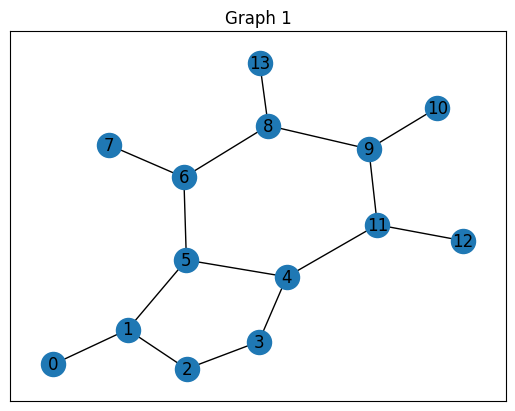

In [38]:
graph_1 = nx.from_numpy_array(adjacency_matrix)


plt.title("Graph 1")
nx.draw_networkx(graph_1, with_labels=True)

The process of manipulating molecules/atoms/bonds in RDKit provides the foundation for generating the graph form of molecular representation.

[13:23:02] Molecule does not have explicit Hs. Consider calling AddHs()


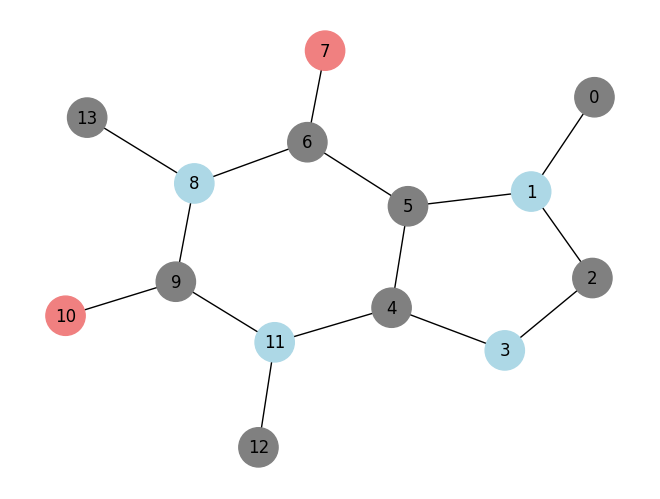

[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [39]:
# Convert SMILES string to a molecule object using rdkit

# without explicit hydrogens
caffeine_mol = Chem.MolFromSmiles(caffeine_smiles)
# with explicit hydrogens
# caffeine_mol = Chem.AddHs(Chem.MolFromSmiles(caffeine_smiles))

# Define a function to convert an rdkit molecule object to a networkx graph object
def mol_to_nx(mol):
  """
  Converts an RDKit molecule object to a NetworkX graph object.

  Args:
      mol: An RDKit molecule object.

  Returns:
      A NetworkX graph object representing the molecule.
  """
  G = nx.Graph()

  # Loop through each atom in the molecule
  for atom in mol.GetAtoms():
    # Add a node to the graph with atom properties as attributes
    G.add_node(atom.GetIdx(),
               atomic_num=atom.GetAtomicNum(),
               is_aromatic=atom.GetIsAromatic(),
               atom_symbol=atom.GetSymbol())

  # Loop through each bond in the molecule
  for bond in mol.GetBonds():
    # Add an edge to the graph between the connected atoms with bond type as attribute
    G.add_edge(bond.GetBeginAtomIdx(),
               bond.GetEndAtomIdx(),
               bond_type=bond.GetBondType())

  return G

# Convert the caffeine molecule object to a networkx graph object
caffeine_nx = mol_to_nx(caffeine_mol)

# Generate conformation (adjust parameters as needed)
conf_ids = Chem.AllChem.EmbedMultipleConfs(caffeine_mol, numConfs=1)


# Get the conformer object from the original molecule
conformer = caffeine_mol.GetConformer(conf_ids[0])  # Access the first conformation
# Extract atomic positions (take only x and y coordinates)
node_positions = [(p[0], p[1]) for p in conformer.GetPositions()]  # Extract (x, y) from (x, y, z)

# Set node positions in the graph using these extracted coordinates
nx.set_node_attributes(caffeine_nx, node_positions, name='pos')

# Define a color map for atom types
color_map = {'C': 'gray',
             'O': 'lightcoral',
             'N': 'lightblue'}

# Create a list to store node colors based on atom types
caffeine_colors = []
for idx in caffeine_nx.nodes():
  # Check if atom symbol exists in the color map
  if caffeine_nx.nodes[idx]['atom_symbol'] in color_map:
    # Assign color based on the map
    caffeine_colors.append(color_map[caffeine_nx.nodes[idx]['atom_symbol']])
  else:
    # Assign gray color for unknown atom types
    caffeine_colors.append('lightgray')

# Draw the caffeine molecule using networkx and matplotlib with manual layout
nx.draw(caffeine_nx,
        pos=node_positions,  # Use the extracted positions
        with_labels = True,
        node_color=caffeine_colors,
        node_size=800)

plt.show()

# print out the adjacency matrix
matrix = nx.to_numpy_array(caffeine_nx)
print(matrix)



---



# Substructures
Identifying substructures can be helpful for finding common scaffolds, locate functional groups and other common tasks in chemoinformatics.

In [40]:
# Define the substructure
substructure_smiles = 'c1ccccc1'

# generate molecule from substructure_smiles
substructure_mol = Chem.MolFromSmiles(substructure_smiles)

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_5449/587937461.py:2: SyntaxWarning: invalid escape sequence '\C'
  smiles_list = ['CC(C)C1=CC=C(C=C1)C(C)C(=O)O', 'CC1=CC=C(C=C1)C(=O)O', 'CO/N=C(\C(=O)N[C@@H]1C(=O)N2[C@@H]1SCC(=C2C(=O)O)COC(=O)N)/c1ccco1', 'CC(C)(CO)C(C(=O)NCCC(=O)O)O', 'CC(C)C1=CC=CC=C1C(=O)O', 'CC1(C)S[C@@H]2[C@H](N(C(=O)CC3=CC=CC=C3)[Si](C)(C)C)C(=O)N2[C@H]1C(=O)O', 'CC(C)C1=CC=C(C=C1)C(=O)O', 'CC1=CC=C(C=C1)C(=O)O', 'Cn1cnc2c1c(=O)n(C)c(=O)n2C', 'CC1=CC=CC=C1C(=O)O']


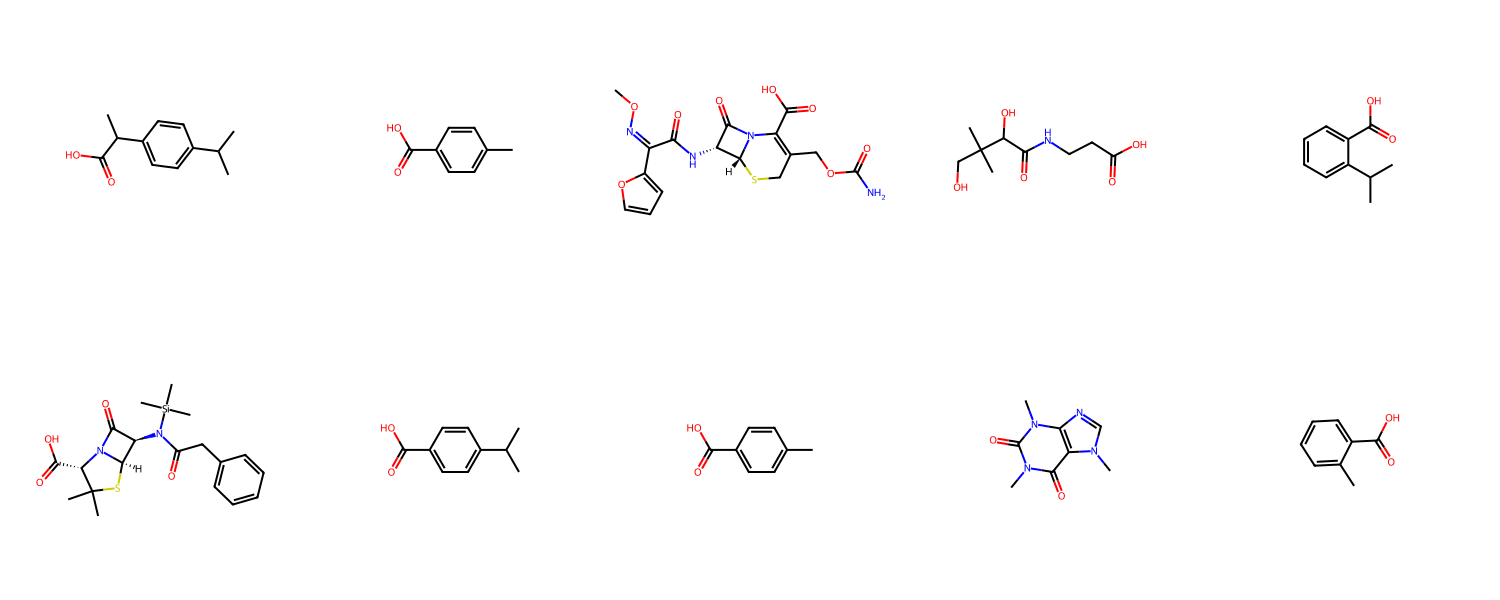

In [41]:
# List of 10 different SMILES strings
smiles_list = ['CC(C)C1=CC=C(C=C1)C(C)C(=O)O', 'CC1=CC=C(C=C1)C(=O)O', 'CO/N=C(\C(=O)N[C@@H]1C(=O)N2[C@@H]1SCC(=C2C(=O)O)COC(=O)N)/c1ccco1', 'CC(C)(CO)C(C(=O)NCCC(=O)O)O', 'CC(C)C1=CC=CC=C1C(=O)O', 'CC1(C)S[C@@H]2[C@H](N(C(=O)CC3=CC=CC=C3)[Si](C)(C)C)C(=O)N2[C@H]1C(=O)O', 'CC(C)C1=CC=C(C=C1)C(=O)O', 'CC1=CC=C(C=C1)C(=O)O', 'Cn1cnc2c1c(=O)n(C)c(=O)n2C', 'CC1=CC=CC=C1C(=O)O']

# Convert SMILES strings to RDKit Mol objects and show them as grid (3 col in 1 row)
# code for that
mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]

Draw.MolsToGridImage(mols,molsPerRow=5,subImgSize=(300,300))

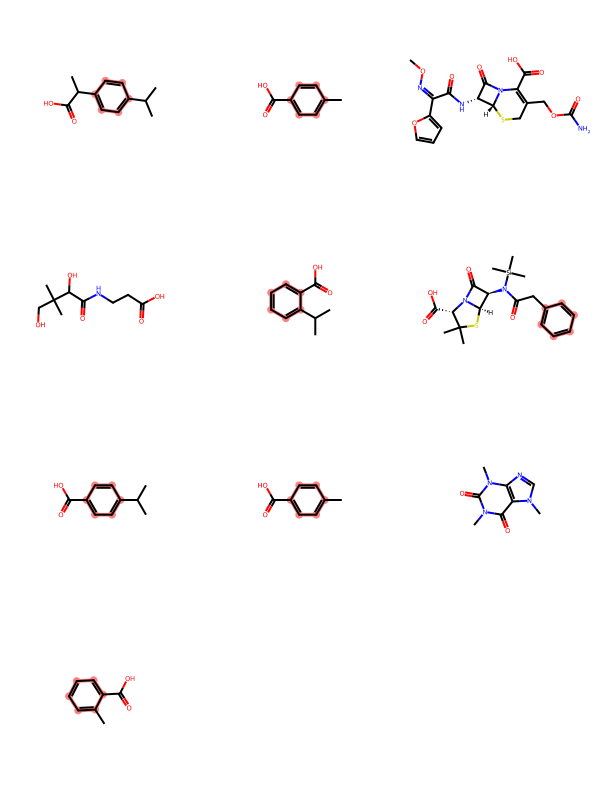

In [42]:
# Get the substructure matches for each molecule
matches = [mol.GetSubstructMatch(substructure_mol) for mol in mols]

# Draw the molecules with the substructure highlighted
Draw.MolsToGridImage(mols, molsPerRow=3, highlightAtomLists=matches)

In [43]:
# Filter molecules based on the existence of the substructure

filtered_mols = []
for mol in mols:
    if mol.HasSubstructMatch(substructure_mol):
        filtered_mols.append(mol)



# Generate a new matches list for the filtered molecules

# Now, filtered_mols contains only the molecules that have the substructure



---



# Working with data from prev step (data from ChEMBL)

Import necessary libraries

In [44]:
# Import necessary libraries
from rdkit import Chem
import pandas as pd
from IPython.display import HTML

pd.set_option('display.max_columns', None)

Load your prev CHEMBL data (that you saved beforehand as `csv` file) and save it in pandas df `chembl_df`

In [45]:
filepath_csv = "/Users/lukas/Desktop/mol_mol_pr/Day_1-2/bioactivity_and_smiles.csv"
chembl_df = pd.read_csv(filepath_csv,sep="\t")

chembl_df.head(3)


,Unnamed: 0,molecule_chembl_id,units,IC50,canonical_smiles,pIC50,mols
0,0,CHEMBL93558,nM,217000.000000,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,2.663540,<rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>
1,1,CHEMBL443622,nM,41000.000000,C[C@H](N)C(=O)N1CCCC1,3.387216,<rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>
2,2,CHEMBL403882,nM,12971.337244,O=C([C@@H]1CCCN1)N1CCCC1,3.887015,<rdkit.Chem.rdchem.Mol object at 0x7f870fd610e0>


In pandas, the `DataFrame.apply` method itself doesn't mutate the original DataFrame. It applies a function element-wise to each row or column (depending on the axis), returning a new Series or DataFrame object with the results.

In [46]:
# Create new Mol column with converted SMILES to Mol

from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(chembl_df, smilesCol="canonical_smiles",molCol="mols")

# check if each value in the ‘smiles’ column is a string and, if so, converts it to a Mol object

chembl_df.head(3)

Unnamed: 0 molecule_chembl_id units           IC50  \
0           0        CHEMBL93558    nM  217000.000000   
1           1       CHEMBL443622    nM   41000.000000   
2           2       CHEMBL403882    nM   12971.337244   

                  canonical_smiles     pIC50  \
0  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  2.663540   
1            C[C@H](N)C(=O)N1CCCC1  3.387216   
2         O=C([C@@H]1CCCN1)N1CCCC1  3.887015   

                                            mols  
0  <rdkit.Chem.rdchem.Mol object at 0x17eb5e3b0>  
1  <rdkit.Chem.rdchem.Mol object at 0x17eb5e420>  
2  <rdkit.Chem.rdchem.Mol object at 0x17eb5e2d0>

In [47]:
# reduce the number of columns so that you can see following columns 'molecule_chembl_id', 'smiles', 'Mol', 'IC50', 'pIC50' and save in separate pandas df

chembl_df.drop(["units"],axis=1)



Unnamed: 0 molecule_chembl_id           IC50  \
0              0        CHEMBL93558  217000.000000   
1              1       CHEMBL443622   41000.000000   
2              2       CHEMBL403882   12971.337244   
3              3       CHEMBL328795  188000.000000   
4              4        CHEMBL97674  247000.000000   
...          ...                ...            ...   
3810        3810      CHEMBL4297435      12.000000   
3811        3811      CHEMBL5418259       2.500000   
3812        3812      CHEMBL5430453       3.400000   
3813        3813      CHEMBL5434074       0.220000   
3814        3814      CHEMBL5425473    3500.000000   

                                       canonical_smiles     pIC50  \
0                       N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  2.663540   
1                                 C[C@H](N)C(=O)N1CCCC1  3.387216   
2                              O=C([C@@H]1CCCN1)N1CCCC1  3.887015   
3                               NC(=O)CC(N)C(=O)N1CCCC1  2.725842   
4                                NCCCCC(N)C(=O)N1CCCCC1  2.607303   
...                                                 ...       ...   
3810  COC(=O)c1nc(C(F)(F)F)n2c1CN(C(=O)C[C@H](N)Cc1c...  6.920819   
3811  N[C@H]1C[C@@H](N2Cc3nn4c(C(F)(F)F)cc(C(F)(F)F)...  7.602060   
3812  Cc1ccc2c(c1)CN(C(=O)CC(C)(C)NCC(=O)N1CCC[C@H]1...  7.468521   
3813  N#Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2cc(-c3c...  8.657577   
3814              N[C@H](C(=O)N1Cc2ccccc2C1)C1CCC(O)CC1  4.455932   

                                               mols  
0     <rdkit.Chem.rdchem.Mol object at 0x17eb5e3b0>  
1     <rdkit.Chem.rdchem.Mol object at 0x17eb5e420>  
2     <rdkit.Chem.rdchem.Mol object at 0x17eb5e2d0>  
3     <rdkit.Chem.rdchem.Mol object at 0x17eb5e340>  
4     <rdkit.Chem.rdchem.Mol object at 0x17eb5e1f0>  
...                                             ...  
3810  <rdkit.Chem.rdchem.Mol object at 0x17e9f0740>  
3811  <rdkit.Chem.rdchem.Mol object at 0x17e9f07b0>  
3812  <rdkit.Chem.rdchem.Mol object at 0x17e9f0820>  
3813  <rdkit.Chem.rdchem.Mol object at 0x17e9f0890>  
3814  <rdkit.Chem.rdchem.Mol object at 0x17e9f0900>  

[3815 rows x 6 columns]

In [48]:
# 'molecule_chembl_id', 'smiles', 'Mol', 'IC50', 'pIC50' and save in separate pandas df

reduced_chembl_df = chembl_df.loc[:,["molecule_chembl_id", "canonical_smiles", "mols", "IC50", "pIC50"]]
reduced_chembl_df = reduced_chembl_df.rename(columns={"mols":"Mol", "canonical_smiles":"smiles"})
reduced_chembl_df.head(2)

molecule_chembl_id                           smiles  \
0        CHEMBL93558  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1   
1       CHEMBL443622            C[C@H](N)C(=O)N1CCCC1   

                                             Mol      IC50     pIC50  
0  <rdkit.Chem.rdchem.Mol object at 0x17eb5e3b0>  217000.0  2.663540  
1  <rdkit.Chem.rdchem.Mol object at 0x17eb5e420>   41000.0  3.387216

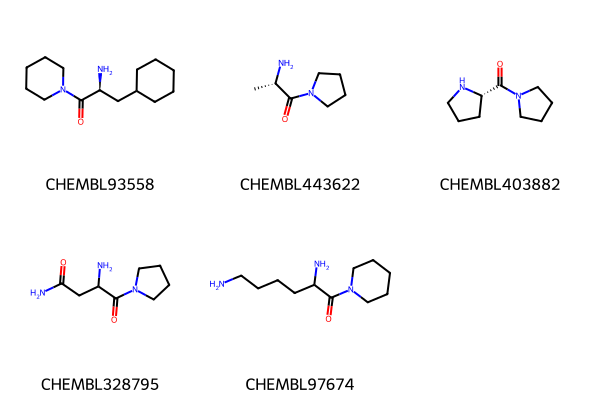

In [49]:
Chem.Draw.MolsToGridImage(
    list(reduced_chembl_df.head().Mol),
    legends=list(reduced_chembl_df.head().molecule_chembl_id),
)

We can do substructure searches across the table:

### Search Maximum Common Substructure (MCS) across whole table



In [50]:
from rdkit.Chem import rdFMCS
from copy import deepcopy

# Try different thresholds
res1 = rdFMCS.FindMCS(reduced_chembl_df.Mol.tolist(), timeout=30, threshold=0.7)
res2 = rdFMCS.FindMCS(reduced_chembl_df.Mol.tolist(), timeout=30, threshold=0.6)
res3 = rdFMCS.FindMCS(reduced_chembl_df.Mol.tolist(), timeout=30, threshold=0.5)


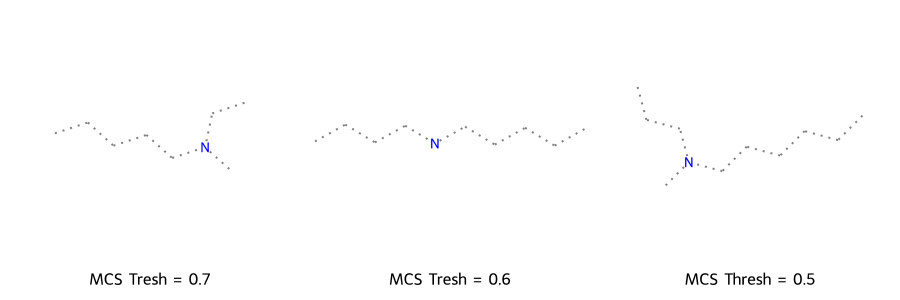

In [51]:
# Draw three MCS Molecules

m1 = Chem.MolFromSmarts(res1.smartsString)
m2 = Chem.MolFromSmarts(res2.smartsString)
m3 = Chem.MolFromSmarts(res3.smartsString)

Draw.MolsToGridImage([m1, m2, m3], legends=["MCS Tresh = 0.7", "MCS Tresh = 0.6", "MCS Thresh = 0.5"], subImgSize=(300, 300))

In [52]:
substr = Chem.MolFromSmiles("CCCC")



---



In [53]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import SVG, display
from rdkit.Chem.Draw import rdMolDraw2D

def highlight_substructures(mol, substructures):
    """
    This function takes a molecule and a list of substructures.
    It highlights the specified substructures in the molecule and displays it.
    """
    # Get all matches of the substructures in the molecule and flatten the matches
    matches = [atom for substructure in substructures for match in mol.GetSubstructMatches(substructure) for atom in match]

    # Draw the molecule with the substructures highlighted
    d = rdMolDraw2D.MolDraw2DSVG(400, 200)
    rdMolDraw2D.PrepareAndDrawMolecule(d, mol, highlightAtoms=matches)
    d.FinishDrawing()
    svg = d.GetDrawingText().replace('svg:', '')

    return SVG(svg)


# Apply the function to first 10 molecule in the DataFrame (just to see how it works)
first_10_rows = reduced_chembl_df.loc[:9]

display(HTML(first_10_rows.to_html()))



---



In [54]:
# apply fuunction to first 10 rows

first_10_rows["substructures"] = first_10_rows.loc[:9,"Mol"].apply(lambda x: highlight_substructures(x, [substr]))

display(HTML(first_10_rows.to_html()))

/var/folders/zl/tr4yyt811072b_l4prllbb4m0000gn/T/ipykernel_5449/2128193722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_10_rows["substructures"] = first_10_rows.loc[:9,"Mol"].apply(lambda x: highlight_substructures(x, [substr]))


### Perform Different Substructure Searches on the DataFrame

  

Benzene counts: 4234
Piperazine counts: 279
Pyrrolidine counts: 1917


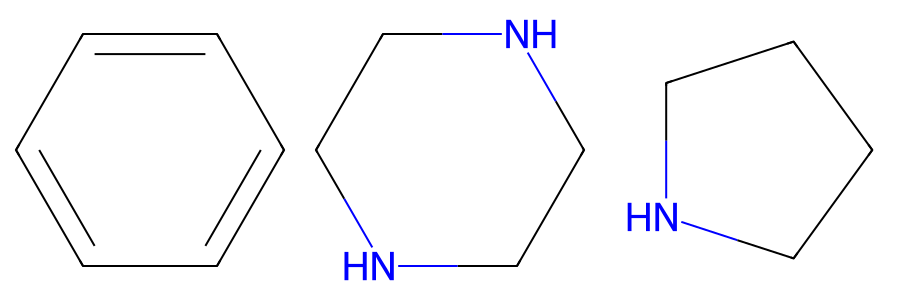

In [55]:
def count_substructure_match(mol,substrucure):
    """ 
    Counts if a substructure is present in a molecule.
    """
    return len(mol.GetSubstructMatches(substrucure))

# Make a list of substructures to count
benzene = Chem.MolFromSmiles("c1ccccc1")
piperazine =  Chem.MolFromSmiles("C1CNCCN1")
pyrrolidine = Chem.MolFromSmiles("C1CCNC1")
substructures = [benzene, piperazine, pyrrolidine]

# Count the number of matches for each substructure in each molecule
benzene_counts = reduced_chembl_df["Mol"].apply(lambda x: count_substructure_match(x, benzene))
piperazine_counts = reduced_chembl_df["Mol"].apply(lambda x: count_substructure_match(x, piperazine))
pyrrolidine_counts = reduced_chembl_df["Mol"].apply(lambda x: count_substructure_match(x, pyrrolidine))

# Sum up the counts
print (f"Benzene counts: {benzene_counts.sum()}")
print (f"Piperazine counts: {piperazine_counts.sum()}")
print (f"Pyrrolidine counts: {pyrrolidine_counts.sum()}")

# Draw substructures of substructure list

img = Draw.MolsToGridImage(substructures, molsPerRow=3, subImgSize=(300, 300))
img

# Descriptors

**Molecular descriptors** are numerical values that represent certain characteristics of a molecule. They play a crucial role in various fields such as chemistry, pharmaceutical sciences, environmental protection, and health researches. They can be broadly classified into four categories:

>**1D (One-Dimensional) Descriptors**: simple, global descriptors that represent the whole molecule with just one value. 
- solubility
- logP (a measure of the molecule's lipophilicity)
- molecular weight
- melting point
- etc. 

However, these descriptors usually do not contain enough information to be applied directly to machine learning (ML). They can be added to 2D fingerprints to improve molecular encoding for ML.

>**2D (Two-Dimensional) Descriptors**: 

These descriptors provide a more detailed representation of the molecule (2D). They include 
- molecular graphs 
- paths
- fragments 
- atom environments
- etc. 

Each molecule is represented by many features or bits, collectively called fingerprints. These fingerprints are often used in similarity search and ML.

>**3D (Three-Dimensional) Descriptors**: 

These descriptors provide a 3D representation of the molecule. They take into account 
- shape of the molecule
- stereochemistry of the molecule. 

However, they are less robust than 2D representations because of molecule flexibility. The challenge here is determining the "right" conformation of a molecule.

>**Biological Descriptors**: 

These are independent of the molecular structure and require experimental or predicted data. An example is the biological fingerprint, where individual bits represent bioactivity measure against different targets.

In essence, molecular descriptors transform the chemical information encoded within a molecule into a useful number or result, allowing some mathematical treatment of the chemical information. This transformation is crucial for various applications, including the development of new drugs and the prediction of chemical properties.

Now you need to work with the same data from ChEMBL Database.

Import the Descriptors module and calculate a few basic ones (related to **1D (One-Dimensional) Descriptors)**:

In [56]:
from rdkit.Chem import Descriptors

Add explicit hydrogens to molecules in `Mol` column - `reduced_chembl_df` df:

In [57]:
reduced_chembl_df["Mol"] = reduced_chembl_df["Mol"].apply(Chem.AddHs)

In [58]:
display(reduced_chembl_df.head())

molecule_chembl_id                           smiles  \
0        CHEMBL93558  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1   
1       CHEMBL443622            C[C@H](N)C(=O)N1CCCC1   
2       CHEMBL403882         O=C([C@@H]1CCCN1)N1CCCC1   
3       CHEMBL328795          NC(=O)CC(N)C(=O)N1CCCC1   
4        CHEMBL97674           NCCCCC(N)C(=O)N1CCCCC1   

                                             Mol           IC50     pIC50  
0  <rdkit.Chem.rdchem.Mol object at 0x17e9f2500>  217000.000000  2.663540  
1  <rdkit.Chem.rdchem.Mol object at 0x17e9f28f0>   41000.000000  3.387216  
2  <rdkit.Chem.rdchem.Mol object at 0x17e9f2b20>   12971.337244  3.887015  
3  <rdkit.Chem.rdchem.Mol object at 0x17e9f27a0>  188000.000000  2.725842  
4  <rdkit.Chem.rdchem.Mol object at 0x17e735d90>  247000.000000  2.607303

**MolLogP (octanol/water partition coefficient)**

Also known as the partition coefficient, MolLogP represents the logarithm of the partition coefficient of a solute between octanol and water at near infinite dilution. In other words, it quantifies how a molecule partitions between a hydrophobic (octanol) and a hydrophilic (water) environment. A higher MolLogP value indicates greater hydrophobicity, which can impact a compound's absorption, distribution, metabolism, and excretion (ADME) properties

In [59]:
# calculate LogP for each molecule and save in `molLogP` column

reduced_chembl_df["molLogP"] = reduced_chembl_df["Mol"].apply(Descriptors.MolLogP)

reduced_chembl_df.loc[:4, "molLogP"]

0    2.2966
1   -0.0440
2    0.3608
3   -1.1885
4    0.4552
Name: molLogP, dtype: float64

**TPSA (topological polar surface area)**

TPSA represents the surface sum over all polar atoms or molecules in a given molecule. These polar atoms primarily include oxygen and nitrogen, along with their attached hydrogen atoms.
It's a way to quantify the polarity of a molecule based on its surface area.

TPSA plays a vital role in drug discovery and development. Scientists use it to predict bioavailability: drug needs to permeate biological barriers to reach its intended targets.

*   Blood-Brain Barrier (BBB) Penetration: For a drug to act on receptors in the central nervous system, its TPSA should be less than 90 Å².
*   Placental Barrier (PB) Permeation: If a drug is intended to treat the fetus, a lower TPSA (below 60 Å²) is preferred to ensure it can pass through the placenta.
*   Blood-Mammary Barrier (BM) Permeation: For breastfeeding mothers, an optimal TPSA for a drug is around 60-80 Å² to allow it to reach breast tissue for milk production. Drugs exceeding 90 Å² are less likely to permeate the Blood-Mammary Barrier.

In [60]:
# calculate tpsa for each molecule and save in `tpsa` column
reduced_chembl_df["tpsa"] = reduced_chembl_df["Mol"].apply(Descriptors.TPSA)
reduced_chembl_df.loc[:4, "tpsa"]

0    46.33
1    46.33
2    32.34
3    89.42
4    72.35
Name: tpsa, dtype: float64

The **molecular weight** (often referred to as molecular mass) of a compound is the sum of the atomic weights of the atoms in a molecule.

In [61]:
# calculate molecular weight for each molecule and save in `MolWT` column
reduced_chembl_df["MolWT"] = reduced_chembl_df["Mol"].apply(Descriptors.MolWt)

reduced_chembl_df["MolWT"]

0       238.375
1       142.202
2       168.240
3       185.227
4       213.325
         ...   
3810    464.366
3811    507.385
3812    368.481
3813    460.538
3814    274.364
Name: MolWT, Length: 3815, dtype: float64

The **NumRotatableBonds** descriptor calculates the number of rotatable bonds in a molecule. Rotatable bonds are those that can freely rotate without breaking the chemical structure. These bonds are typically single bonds connecting non-terminal heavy atoms (i.e., atoms other than hydrogen). The more rotatable bonds a molecule has, the more flexible it is in terms of conformational changes and interactions with other molecules.

In RDKit, a rotatable bond is defined as any single bond, not in a ring, bound to a non-terminal heavy atom (non-hydrogen atom). Amide C-N bonds are not considered rotatable.

In [62]:
# calculate number of rotable bounds for each molecule and save in `NumRotatableBonds` column
reduced_chembl_df["NumRotatableBonds"] = reduced_chembl_df["Mol"].apply(Descriptors.NumRotatableBonds)

In [63]:
# calculate number of hydrogen donors and acceptors for each molecule and save in `NumHDonors` and `NumHAcceptors` columns
reduced_chembl_df["NumHDonors"] = reduced_chembl_df["Mol"].apply(Descriptors.NumHDonors)
reduced_chembl_df["NumHAcceptors"] = reduced_chembl_df["Mol"].apply(Descriptors.NumHAcceptors)

In [64]:
reduced_chembl_df.head(5)

molecule_chembl_id                           smiles  \
0        CHEMBL93558  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1   
1       CHEMBL443622            C[C@H](N)C(=O)N1CCCC1   
2       CHEMBL403882         O=C([C@@H]1CCCN1)N1CCCC1   
3       CHEMBL328795          NC(=O)CC(N)C(=O)N1CCCC1   
4        CHEMBL97674           NCCCCC(N)C(=O)N1CCCCC1   

                                             Mol           IC50     pIC50  \
0  <rdkit.Chem.rdchem.Mol object at 0x17e9f2500>  217000.000000  2.663540   
1  <rdkit.Chem.rdchem.Mol object at 0x17e9f28f0>   41000.000000  3.387216   
2  <rdkit.Chem.rdchem.Mol object at 0x17e9f2b20>   12971.337244  3.887015   
3  <rdkit.Chem.rdchem.Mol object at 0x17e9f27a0>  188000.000000  2.725842   
4  <rdkit.Chem.rdchem.Mol object at 0x17e735d90>  247000.000000  2.607303   

   molLogP   tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  
0   2.2966  46.33  238.375                  4           1              2  
1  -0.0440  46.33  142.202                  3           1              2  
2   0.3608  32.34  168.240                  1           1              2  
3  -1.1885  89.42  185.227                  4           2              3  
4   0.4552  72.35  213.325                  7           2              3

The `describe()` method in Python is used to generate descriptive statistics of a DataFrame or Series. It provides information such as the mean, standard deviation, minimum, maximum, and quartiles for numerical columns.

*   count: The number of non-null values in each column.
*   mean: The average value of each column.
*   std: The standard deviation, which measures the spread of data around the mean.
*   min: The minimum value in each column.
*   25%, 50%, and 75%: The quartiles (percentiles) of the data. The 25th percentile (Q1) represents the value below which 25% of the data falls, the 50th percentile (Q2) is the median, and the 75th percentile (Q3) represents the value below which 75% of the data falls.
*   max: The maximum value in each column.



In [65]:
# get statistics using provided method
reduced_chembl_df.describe()

,IC50,pIC50,molLogP,tpsa,MolWT,NumRotatableBonds,NumHDonors,NumHAcceptors
count,3.815000e+03,3815.000000,3815.000000,3815.000000,3815.000000,3815.000000,3815.000000,3815.000000
mean,3.024362e+05,6.021045,2.213598,89.347945,402.281852,6.673657,1.629882,5.491481
std,1.780984e+07,1.325308,1.445568,29.422031,98.581719,2.776630,0.888278,2.135270
min,1.200000e-02,-1.041393,-3.449230,3.240000,129.167000,1.000000,0.000000,1.000000
25%,1.100000e+01,5.292430,1.318350,70.120000,337.653500,5.000000,1.000000,4.000000
50%,6.900000e+01,6.161151,2.267800,85.670000,402.367000,6.000000,1.000000,5.000000
75%,5.100000e+02,6.958607,3.114650,105.630000,468.719500,8.000000,2.000000,7.000000
max,1.100000e+09,9.920819,12.047300,351.810000,1174.445000,51.000000,10.000000,17.000000


Let's write down some code to show histograms related to pIC50, molecular mass, logP, etc. (all the calculated and existed props). Make conclusions based on them.

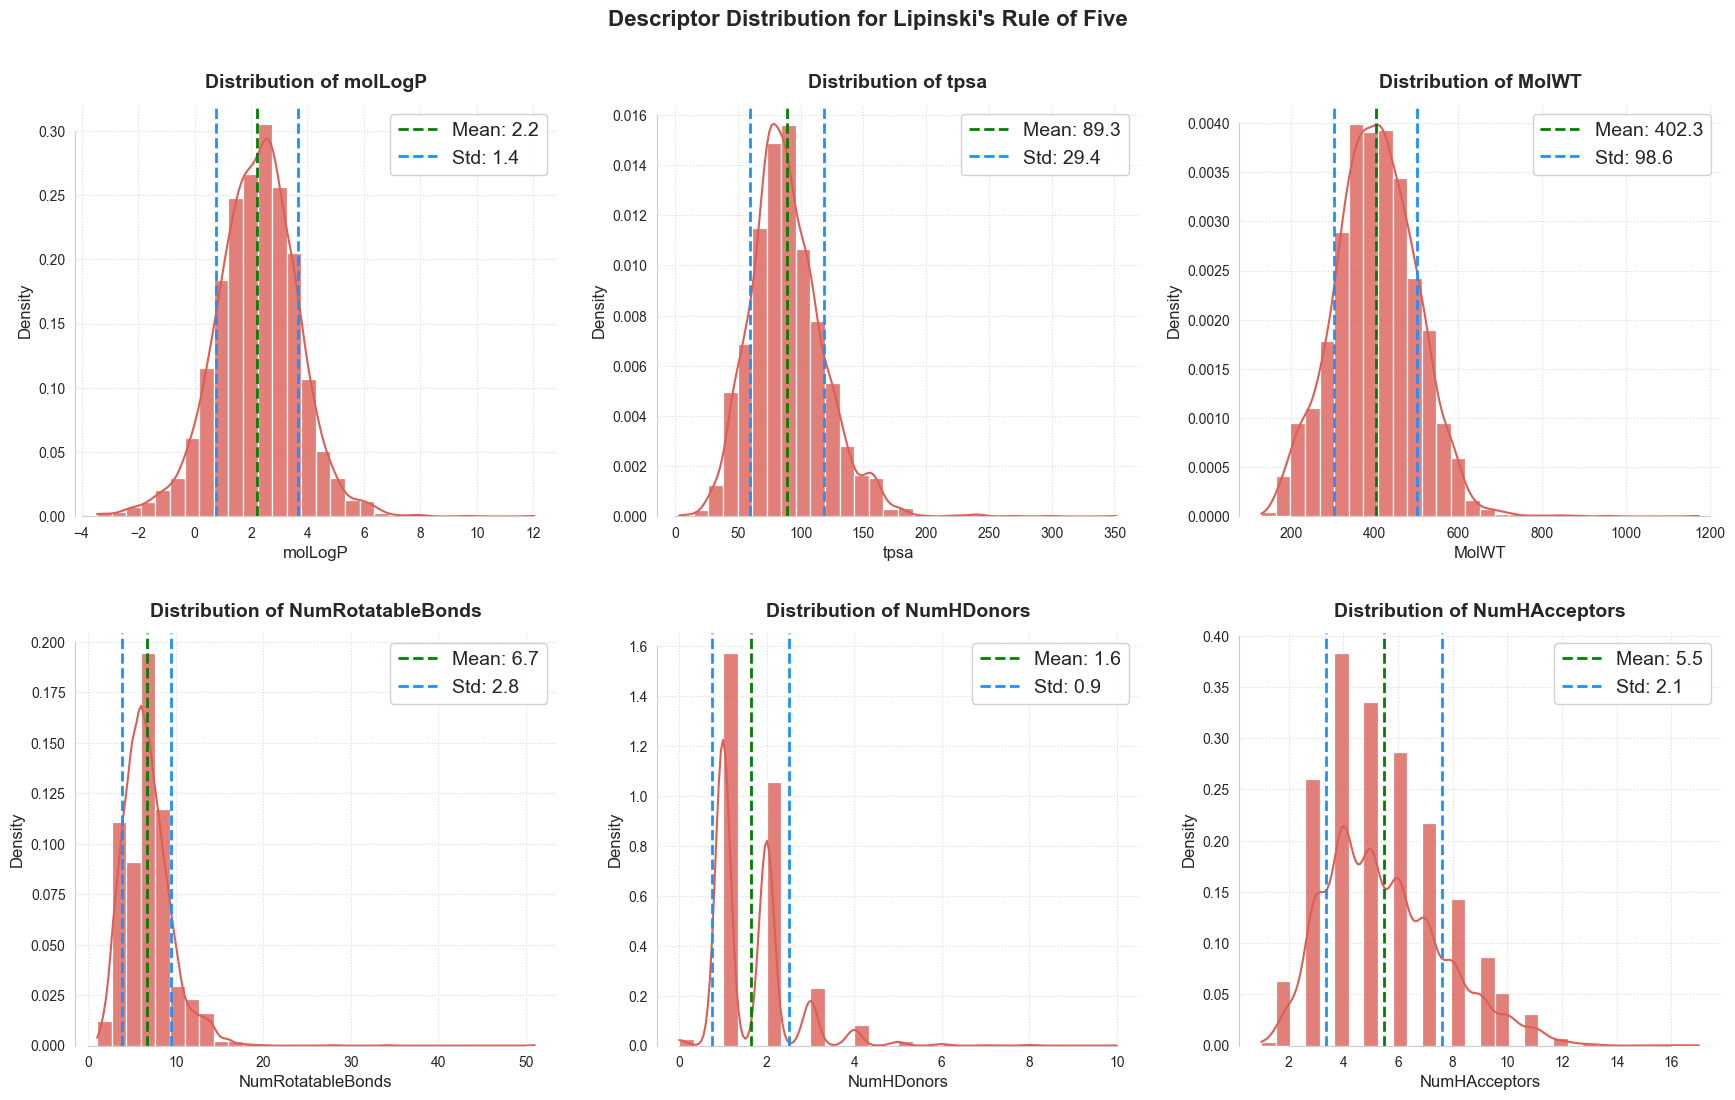

In [66]:
# Select The Columns
import seaborn as sns
import matplotlib.pyplot as plt

# Set global style
sns.set_style("whitegrid")
sns.set_palette("hls")

# Define columns to plot
columns = ["molLogP", "tpsa", "MolWT", "NumRotatableBonds", "NumHDonors", "NumHAcceptors"]

# Calculate subplot layout
n = len(columns)
cols = 3  # plots per row
rows = (n + cols - 1) // cols

# Create figure with adjusted size and spacing
fig, axes = plt.subplots(rows, cols, figsize=(18, 5.5*rows))
if rows == 1:  # Handle case when there's only one row
    axes = axes.reshape(1, -1)

# Flatten axes array for easy iteration
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    ax = axes_flat[i]
    
    # Create histogram with density curve
    sns.histplot(
        data=reduced_chembl_df, 
        x=col,
        kde=True,
        ax=ax,
        bins=30,
        edgecolor='white',
        alpha=0.8,
        stat='density',  # Show density instead of count
    )
    
    # Calculate and show mean/median
    mean_val = reduced_chembl_df[col].mean()

    # calulate std
    std_val = reduced_chembl_df[col].std()


    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}') 
    ax.axvline(mean_val + std_val, color='dodgerblue', linestyle='--', linewidth=2, label=f'Std: {std_val:.1f}')
    ax.axvline(mean_val - std_val, color='dodgerblue', linestyle='--', linewidth=2)
    # Customize appearance
    ax.set_title(f"Distribution of {col}", fontsize=14, pad=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Add legend
    ax.legend(fontsize=14, framealpha=0.9)
    
    # Customize grid
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Remove top and right spines
    sns.despine(ax=ax, trim=True)

# Hide any empty subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

# Adjust layout
plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)

# Add overall title
fig.suptitle("Descriptor Distribution for Lipinski's Rule of Five", y=1.02, fontsize=16, fontweight='bold')
plt.savefig("lipinski_rule_of_five.png", dpi=600, bbox_inches='tight')
plt.show()

Why are this distributions of properties important in our analysis?

**Result of your today's work PART 2**: you've learned:
- in which formats molecules can be presented 
- different 2D and 3D ways of molecules visualization
- what are substructures and how they can be used
- what are descriptors, which types of descriptors exist and how they can be used for dataset (consisted of molecules) filtering.



---



# Molecular filtering

In the context of drug design, it is important to filter candidate molecules by some of their properties. 

Here you'll get familiar with several ways of filtering out potential candidates.

In a virtual screening, it is aimed to predict whether a compound might bind to and interact with a specific target. 

However, it is also important that this compound:
- reaches the target to interact with it 
- can be removed from the body in a favorable way. 

Therefore, it should be considered whether a compound is actually taken up into the body and whether it is able to cross certain barriers in order to reach its target. Is it metabolically stable and how will it be excreted once it is not acting at the target anymore? 

These processes are investigated in the field of pharmacokinetics. In contrast to pharmacodynamics that answers the question “What does the drug do to our body?”, pharmacokinetics deals with the question “What does our body do to the drug? (what happens to the drug in our body)?”.

Pharmacokinetics are mainly divided into four steps: Absorption, Distribution, Metabolism, and Excretion. These are summarized as ADME. Often, ADME also includes Toxicology and is thus referred to as ADMET or ADMETox. 

More info about it you can get from: 
- https://en.wikipedia.org/wiki/ADME

## Molecular filtering based on descriptors

It's quite common to filter potential molecules by different properties during the drug discovery or molecular modeling process.

Lead compounds [https://en.wikipedia.org/wiki/Lead_compound] are developmental drug candidates with promising properties. They are used as starting structures and modified with the aim to develop effective drugs. 

Besides bioactivity (compound binds to the target of interest), also favorable ADME properties are important criteria for the design of efficient drugs.

The bioavailability of a compound is an important ADME property. Lipinski’s rule of five (Ro5) was introduced to estimate the bioavailability of a compound solely based on its chemical structure. 

**Lead-likeness and Lipinski’s rule of five (Ro5)**

Lipinski’s Rule of Five, also known as Pfizer’s Rule of Five or simply the Rule of Five (RO5), is a rule of thumb in the field of drug discovery to evaluate druglikeness or determine if a chemical compound with a certain pharmacological or biological activity has properties that would make it a likely orally active drug in humans.

The rule was formulated by Christopher A. Lipinski in 1997, based on the observation that most orally administered drugs are relatively small and moderately lipophilic molecules. The rule describes molecular properties important for a drug’s pharmacokinetics in the human body, including their absorption, distribution, metabolism, and excretion (“ADME”).

The Ro5 states that poor absorption or permeation of a compound is more probable if the chemical structure violates more than one of the following rules:

*  **Number of hydrogen bond donors (HBD) <= 5** (the total number of nitrogen–hydrogen and oxygen–hydrogen bonds)
*  **Number of hydrogen bond acceptors (HBAs) <= 10** (all nitrogen or oxygen atoms): Hydrogen bonds play a crucial role in the interaction between a drug and its target, as well as in the drug’s solubility and permeability. Too many hydrogen bonds can make a compound too polar to cross cell membranes, limiting its bioavailability.
*  **Molecular weight (MWT) <= 500 Da**: This is because larger molecules may have difficulty reaching their target site of action and may be removed from the body before they have a chance to work.
*  **Calculated LogP (octanol-water coefficient) <= 5**: LogP is a measure of a compound’s lipophilicity. Compounds that are too lipophilic (high LogP) tend to be poorly soluble in water and may accumulate in fatty tissues, while compounds that are too hydrophilic (low LogP) may not cross cell membranes efficiently. A LogP value under 5 is a balance between these extremes.

The name “rule of five” comes from the fact that all the conditions have multiples of five as the determinant conditions.

It’s important to note that while Lipinski’s Rule of Five is a useful guideline in drug discovery, there are many exceptions, and a molecule that violates more than one of these rules could still be an effective drug. Also, the rule does not predict if a compound is pharmacologically active


**Question to answer**: In what way can the chemical properties described by the Ro5 affect ADME?

### Investigate compliance with Ro5

... by applying the Ro5 to the target dataset.

Create a function `check_if_ro5_fulfilled` what will take as input dataset after calculating all the descriptors, check it up, add new 'ro5_fulfilled' column with bool value if this specific molecule fulfill of not RO5, and return this dataset with new `ro5_fulfilled` column (bool).

In [67]:
def check_if_ro5_fulfilled(df):
    """
    Function that checks Lipinski Rule of 5
    """
    def lipinski_row(row):
        match True:
            case _ if row["MolWT"] > 500:
                return False
            case _ if row["molLogP"] > 5:
                return False
            case _ if row["NumHDonors"] > 5:
                return False
            case _ if row["NumHAcceptors"] > 10:
                return False
            case _:
                return True
    df["ro5_fulfilled"] = df.apply(lipinski_row,axis=1)
    return df

# Apply Function 
check_if_ro5_fulfilled(reduced_chembl_df)
ro5_chembl_df = reduced_chembl_df

Now filter out the molecules corresponding to RO5 and save them in separate file.

Note: don't forget to remove 'Mol' field beforehand.

In [68]:



molecules_ro5_fulfilled = reduced_chembl_df[reduced_chembl_df["ro5_fulfilled"]==True]
molecules_ro5_fulfilled.drop(["Mol"],axis=1)
molecules_ro5_violated = reduced_chembl_df[reduced_chembl_df["ro5_fulfilled"]==False]
molecules_ro5_violated.drop(["Mol"],axis=1)



print(f"# compounds in unfiltered data set: {ro5_chembl_df.shape[0]}")
print(f"# compounds in filtered data set (follow RO5): {molecules_ro5_fulfilled.shape[0]}")
print(f"# compounds not compliant with the Ro5 (don't follow RO5): {molecules_ro5_violated.shape[0]}")

# compounds in unfiltered data set: 3815
# compounds in filtered data set (follow RO5): 3141
# compounds not compliant with the Ro5 (don't follow RO5): 674


In [69]:
# Save filtered data in a separate csv file. NB: don't forget to drop 'Mol' column

molecules_ro5_fulfilled.to_csv("molecules_r05_fulfilled.csv")
molecules_ro5_violated.to_csv("molecules_ro5_violated.csv")

### Radar charts in the context of lead-likeness

Molecular properties, such as the Ro5 properties, can be visualized in multiple ways (e.g. craig plots, flower plots, or golden triangle) to support the interpretation by medicinal chemists.

Due to their appearance, radar charts are sometimes also called “spider” or “cobweb” plots. They are arranged circularly in 360 degrees and have one axis, starting in the center, for each condition. The values for each parameter are plotted on the axis and connected with a line. A shaded area can indicate the region where the parameters meet the conditions.

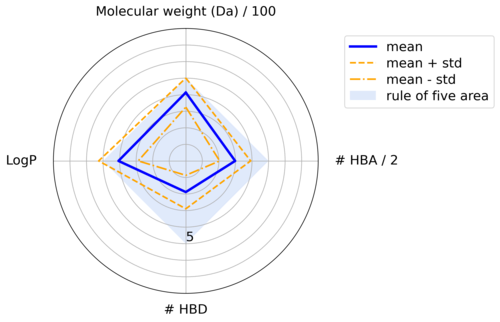

Radar plot displaying physico-chemical properties of a compound dataset.



First you need to calculate statistics on Ro5 properties to use this data for radar chart.

Define a helper function to calculate the mean and standard deviation for an input `DataFrame`. Name it `calculate_mean_std`.

Hint: you need to calculate mean and standard deviation for EACH of different properties.

In [70]:
def calculate_mean_std(dataframe):
    summary = dataframe.describe().loc[["mean","std"]].T
    # This is shit
    summary = summary.drop(index="IC50")
    summary = summary.drop(index="pIC50")
    summary = summary.drop(index="tpsa")
    summary = summary.drop(index="NumRotatableBonds")
    return summary

print(calculate_mean_std(molecules_ro5_fulfilled)) # looks good

                     mean        std
molLogP          2.015295   1.317900
MolWT          372.787777  76.511203
NumHDonors       1.507482   0.724255
NumHAcceptors    5.063992   1.828485


As a next step you need to define several helper functions to prepare data for x and y axis to use it then for radar plotting.

**Y-axis data preparation**

In the first helper function you need to prepare y values: the properties used for the Ro5 criteria are of different magnitudes. 

The MWT has a threshold of 500, whereas the number of HBAs and HBDs and the LogP have thresholds of only 10, 5, and 5, respectively. In order to visualize these different scales most simplistically, we will scale all property values to a scaled threshold of 5:

`scaled property value = property value / property threshold * scaled property threshold`

- scaled MWT = MWT / 500 * 5 = MWT / 100
- scaled HBA = HBA / 10 * 5 = HBA / 2
- scaled HBD = HBD / 5 * 5 = HBD
- scaled LogP = LogP / 5 * 5 = LogP

This results in a downscaling of the MWT by 100, HBA by 2, while HBD and LogP stay unchanged.

The following helper function performs such a scaling and will be used later during radar plotting.

In [71]:
def _scale_by_thresholds(stats, thresholds, scaled_threshold):
    """
    Scale values for different properties that have each an individually defined threshold.

    Parameters
    ----------
    stats : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.

    Returns
    -------
    pd.DataFrame
        DataFrame with scaled means and standard deviations for each physiochemical property.
    """
    # Raise error if scaling keys and data_stats indicies are not matching
    for property_name in stats.index:
        if property_name not in thresholds.keys():
            raise KeyError(f"Add property '{property_name}' to scaling variable.")
    # Scale property data
    stats_scaled = stats.apply(lambda x: x / thresholds[x.name] * scaled_threshold, axis=1)
    return stats_scaled

**X-axis data preparation**

Prepare x values: following helper function returns the angles of the physicochemical property axes for the radar chart as radians. 

For example, if you want to generate a radar plot for 4 properties, we want to set the axes at 0°, 90°, 180°, and 270°. 

In [72]:
import math

def _define_radial_axes_angles(n_axes):
    """Define angles (radians) for radial (x-)axes depending on the number of axes."""
    x_angles = [i / float(n_axes) * 2 * math.pi for i in range(n_axes)]
    x_angles += x_angles[:1]
    return x_angles

Both functions will be used as helper functions in the radar plotting function, which is defined next.

Now, let's define a function that visualizes the compounds’ chemical properties in the form of a radar chart. 

Hint: you can follow these instructions on stackoverflow [https://stackoverflow.com/questions/42227409/tutorial-for-python-radar-chart-plot].

In [73]:
def plot_radar(
    y,
    thresholds,
    scaled_threshold,
    properties_labels,
    title=None,
    y_max=None,
    output_path=None,
):
    """
    Plot a radar chart based on the mean and standard deviation of a data set's properties.

    Parameters
    ----------
    y : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.
    properties_labels : list of str
        List of property names to be used as labels in the plot.
    y_max : None or int or float
        Set maximum y value. If None, let matplotlib decide.
    output_path : None or pathlib.Path
        If not None, save plot to file.
    """

    # Define radial x-axes angles -- uses our helper function!
    x = _define_radial_axes_angles(len(y))
    # Scale y-axis values with respect to a defined threshold -- uses our helper function!
    y = _scale_by_thresholds(y, thresholds, scaled_threshold)
    # Since our chart will be circular we append the first value of each property to the end
    y = pd.concat([y, y.head(1)])

    # Set figure and subplot axis
    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    # Plot data
#    ax.fill(x, [scaled_threshold] * len(x), "cornflowerblue", alpha=0.2)
#    ax.plot(x, y["mean"], "b", lw=3, ls="-")
#    ax.plot(x, y["mean"] + y["std"], "orange", lw=2, ls="--")
#    ax.plot(x, y["mean"] - y["std"], "orange", lw=2, ls="-.")

    ax.fill(x, [scaled_threshold] * len(x), "cornflowerblue", alpha=0.3)  # Rule of five area
    ax.plot(x, y["mean"], color="#0072B2", lw=3, ls="-", label="mean")
    ax.plot(x, y["mean"] + y["std"], color="#E69F00", lw=2, ls="--", label="mean + std")
    ax.plot(x, y["mean"] - y["std"], color="#E69F00", lw=2, ls="-.", label="mean - std")

    # From here on, we only do plot cosmetics
    # Set 0° to 12 o'clock
    ax.set_theta_offset(math.pi / 2)
    # Set clockwise rotation
    ax.set_theta_direction(-1)

    # Set y-labels next to 180° radius axis
    ax.set_rlabel_position(180)
    # Set number of radial axes' ticks and remove labels
    plt.xticks(x, [])
    # Get maximal y-ticks value
    if not y_max:
        y_max = int(ax.get_yticks()[-1])
    # Set axes limits
    plt.ylim(0, y_max)
    # Set number and labels of y axis ticks
    plt.yticks(
        range(1, y_max),
        [str(i*scaled_threshold/scaled_threshold) for i in range(1, y_max)],
        #["5" if i == scaled_threshold else "" for i in range(1, y_max)],
        fontsize=14,
    )

    # Draw ytick labels to make sure they fit properly
    # Note that we use [:1] to exclude the last element which equals the first element (not needed here)
    for i, (angle, label) in enumerate(zip(x[:-1], properties_labels)):
        if angle == 0:
            ha = "center"
        elif 0 < angle < math.pi:
            ha = "left"
        elif angle == math.pi:
            ha = "center"
        else:
            ha = "right"
        ax.text(
            x=angle,
            y=y_max + 1,
            s=label,
            size=16,
            horizontalalignment=ha,
            verticalalignment="center",
        )

    # Add legend relative to top-left plot
    labels = ("rule of five area", "mean", "mean + std", "mean - std")
    ax.legend(labels, loc=(1.1, 0.7), labelspacing=0.3, fontsize=16)

    # Save plot - use bbox_inches to include text boxes
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

You need to plot the radar chart for both datasets: 

1. Compounds that fulfill the Ro5 
2. Compounds that violate the Ro5

To see the difference between them.

In [74]:
molecules_ro5_fulfilled_stats = calculate_mean_std(molecules_ro5_fulfilled) # for each of properties of interest

print(molecules_ro5_fulfilled_stats)

                     mean        std
molLogP          2.015295   1.317900
MolWT          372.787777  76.511203
NumHDonors       1.507482   0.724255
NumHAcceptors    5.063992   1.828485


In [75]:
molecules_ro5_violated_stats = calculate_mean_std(molecules_ro5_violated) # for each of properties of interest
print(molecules_ro5_violated_stats)

                     mean        std
molLogP          3.137740   1.643173
MolWT          539.731245  69.155035
NumHDonors       2.200297   1.276115
NumHAcceptors    7.483680   2.326385


Input parameters should stay the same for both radar charts:

In [76]:
thresholds = {
    "MolWT": 500, 
    "NumHAcceptors": 10, 
    "NumHDonors": 5, 
    "molLogP": 5
}

scaled_threshold = 5

properties_labels = [
    "Molecular weight (Da) / 100",
    "HBAcc / 2",
    "HBDon",
    "LogP",
]

y_max = 8

First let's plot the radarplot for the dataset of compounds that fulfill the Ro5.

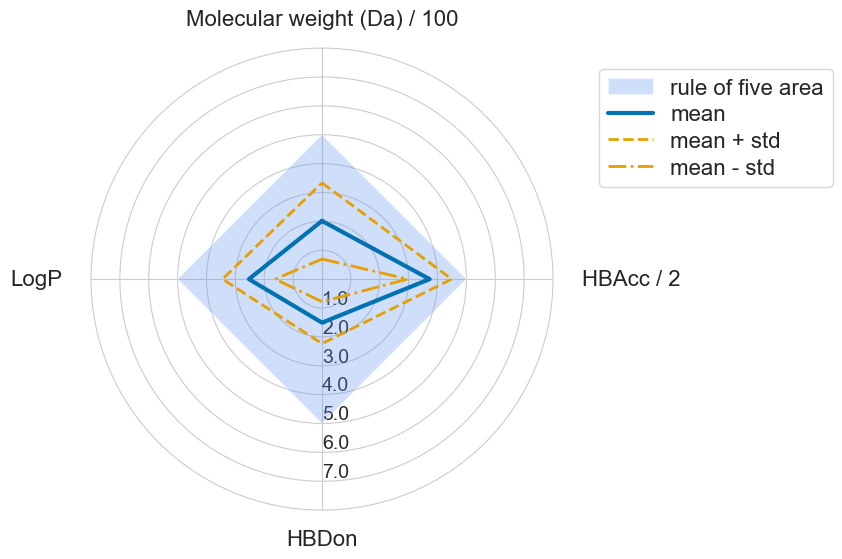

In [77]:
plot_radar(molecules_ro5_fulfilled_stats,
           thresholds=thresholds,
           scaled_threshold=scaled_threshold,
           properties_labels=properties_labels,
           y_max = y_max)

Now let's plot the radarplot for the dataset of compounds that fulfill the Ro5.

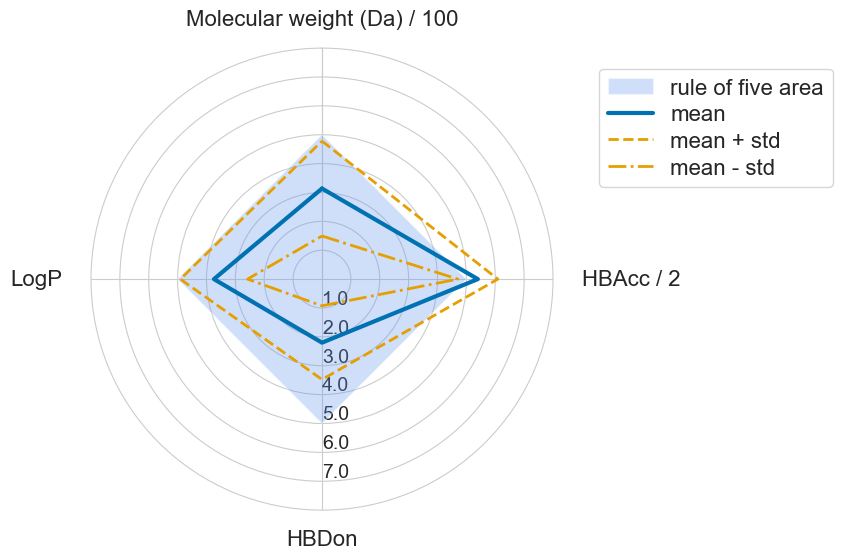

In [78]:
plot_radar(molecules_ro5_violated_stats,
           thresholds=thresholds,
           scaled_threshold=scaled_threshold,
           properties_labels=properties_labels,
           y_max=y_max)

**Questions to answer**: 

- Explain meaning of all geometrical forms on the graphs: what means if some of them overlap / not overlap each other? 
- What do you see on this graphs? 
- How can you evaluate them? 
- How can you explain the difference between them?
- Compare pIC50 histogram with results after applying RO5 (with dataset that fulfill RO5, with dataset that violate RO5): do you observe differences? 

**Result of your today's work PART 3**: you've learned about Lipinski’s Ro5 as a measure to estimate a compound’s oral bioavailability and we have applied the rule on a dataset using rdkit. Note that drugs can also be administered via alternative routes, i.e. inhalation, skin penetration and injection.



---



# Molecular filtering: unwanted substructures

**What means "unwanted"?**

Unwanted substructures refer to certain **parts of a molecule** that may be undesirable due to various reasons (this is why we prefer not to include them into our screening library). These could be because they are toxic, reactive, have unfavorable pharmacokinetic properties, or because they likely interfere with certain assays. Here are some types of unwanted substructures:

1.   Toxic or Reactive Substructures: These are parts of a molecule that may be harmful or react in undesirable ways. For example, nitro groups can be mutagenic.

2.   Substructures with Unfavorable Pharmacokinetic Properties: These are parts of a molecule that may result in the drug being poorly absorbed, distributed, metabolized, or excreted in the body. For instance, sulfates and phosphates can result in unfavorable pharmacokinetic properties.

3.   Interfering Substructures: These are parts of a molecule that may interfere with certain assays, making the results less reliable. For example, 2-halopyridines and thiols can be reactive.

4.   Pan Assay Interference Compounds (PAINS): PAINS are compounds that often occur as hits in high throughput screening (HTS) even though they are actually false positives. They show activity at numerous targets rather than one specific target. Such behavior results from unspecific binding or interaction with assay components. Learn more about them: 
- https://en.wikipedia.org/wiki/Pan-assay_interference_compounds

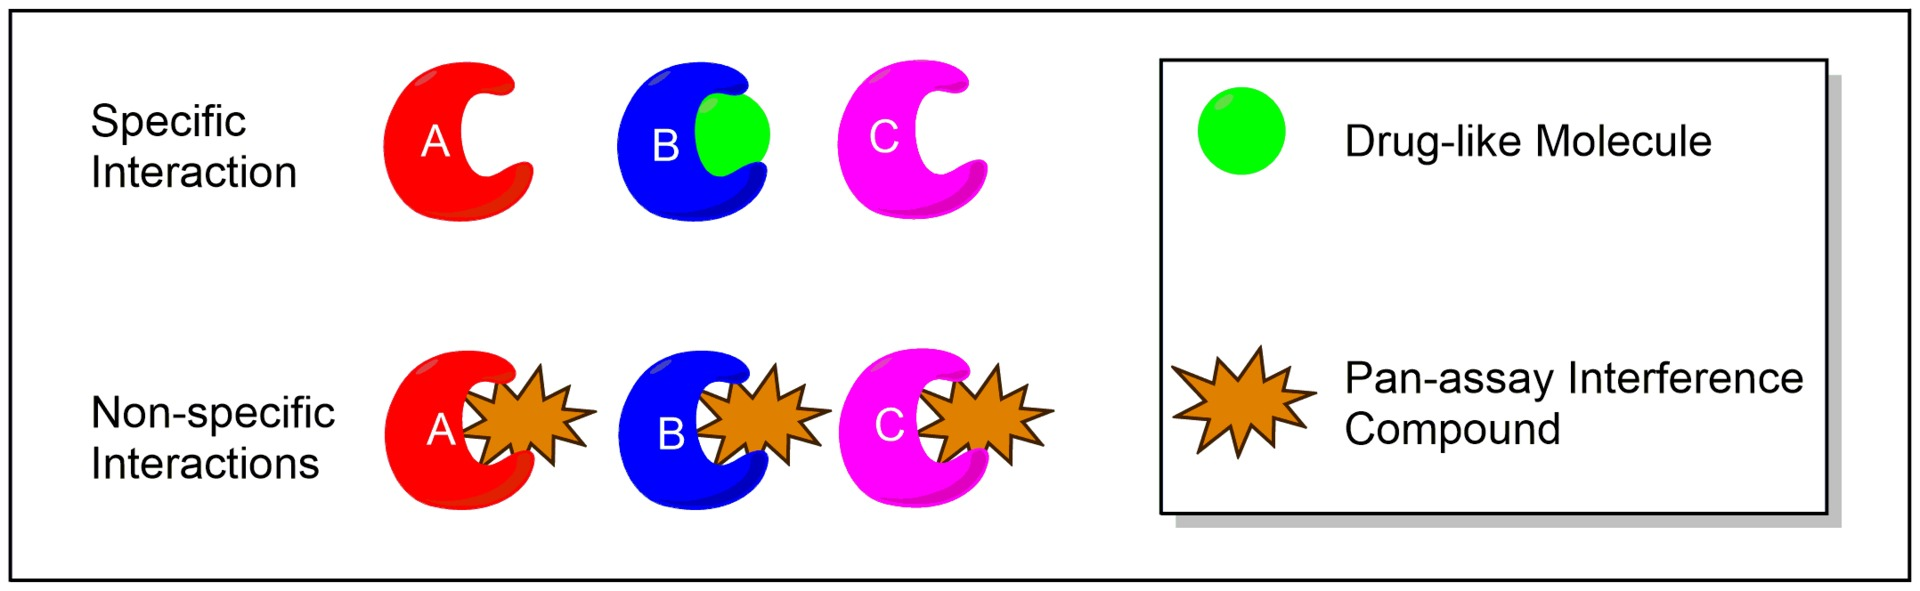

Filtering out these unwanted substructures can help in assembling more efficient screening libraries, saving time and resources in drug discovery campaigns. It’s important to note that these are just a few examples, and the actual list of unwanted substructures can be much larger and depends on the specific requirements of the drug discovery project.

**Questions to answer**:

1) Why should we consider removing “PAINS” from a screening library? What is the issue with these compounds?
2) Can you find situations when some unwanted substructures would not need to be removed?

**How to find, highlight and remove unwanted substructures with RDKit?**

We will try to implement it through filtering our data out of Pan Assay Interference Compounds (PAINS).

PAINS are a prominent source of false positives in the drug-discovery process. They are biologically active compounds that masquerade as potential drug candidates during the initial high volume screening used to search for possible new drugs.

A number of disruptive functional groups are shared by many PAINS. Common PAINS include toxoflavin, isothiazolones, hydroxyphenyl hydrazones, curcumin, phenol-sulfonamides, rhodanines, enones, quinones, and catechols.

The PAINS filter is already implemented in RDKit. Such pre-defined filters can be applied via the `FilterCatalog` class. Or you can use `HasSubstructMatch` (which only yields one match per compound) or `GetSubstructMatches` (to identify all occurrences of a particular substructure in a compound) if you have special pre-defined list of unwanted structures.

If you simply want to filter out all PAINS - one match is enough.

Some of the pre-defined collections can be found in the RDKit documentation [https://rdkit.org/docs/source/rdkit.Chem.rdfiltercatalog.html].

In [79]:
# import
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.


In [80]:
# initialize filter
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

Let's apply these filters to the dataset obtained from the previous stage (that fulfill RO5).

In [81]:
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors as rdescriptors

def get_pains_info(molecule, chembl_id):
    """
    This function takes a molecule and its corresponding chembl_id as input.
    It checks if the molecule has any PAINS (Pan Assay Interference Compounds).
    If PAINS are found, it returns a dictionary with the chembl_id, the molecule, and the description of the PAINS.
    If no PAINS are found, it returns None.
    """
    entry = catalog.GetFirstMatch(molecule)  # Get the first matching PAINS
    if entry is not None:
        return {
            "chembl_id": chembl_id,
            "rdkit_molecule": molecule,
            "pains": entry.GetDescription().capitalize(),
        }

def filter_pains(egfr_data):
    """
    This function takes a DataFrame of molecules (egfr_data) as input.
    It iterates over each row (molecule) in the DataFrame.
    For each molecule, it checks if there are any PAINS using the get_pains_info function.
    If PAINS are found, it adds the returned dictionary to the 'matches' list.
    If no PAINS are found, it adds the index of the molecule to the 'clean_indices' list.
    Finally, it returns a DataFrame of the matches and a DataFrame of the molecules without PAINS.
    """
    matches = []
    clean_indices = []

    for idx,row in egfr_data.iterrows():
        mol = row["Mol"]
        chembl_id = row["molecule_chembl_id"]

        pains_info = get_pains_info(mol,chembl_id)
        
        # if pains info is not None we have a math
        if pains_info is not None:
            matches.append(pains_info)
        else:
            clean_indices.append(idx)

    # Create the dataframes
    pains_df = pd.DataFrame(matches)
    clean_df = egfr_data.loc[clean_indices].reset_index(drop=True)

    return pains_df, clean_df


    # write code for that based on instructions

# Use the function to filter out PAINS

matches, cleaned_df = filter_pains(molecules_ro5_fulfilled)

In [82]:
# Print substructures of PAINS
matches["rdkit_molecule"].apply(lambda x: highlight_substructures(x, [substr]))
# Draw the substructures of PAINS



0     <IPython.core.display.SVG object>
1     <IPython.core.display.SVG object>
2     <IPython.core.display.SVG object>
3     <IPython.core.display.SVG object>
4     <IPython.core.display.SVG object>
5     <IPython.core.display.SVG object>
6     <IPython.core.display.SVG object>
7     <IPython.core.display.SVG object>
8     <IPython.core.display.SVG object>
9     <IPython.core.display.SVG object>
10    <IPython.core.display.SVG object>
11    <IPython.core.display.SVG object>
12    <IPython.core.display.SVG object>
13    <IPython.core.display.SVG object>
14    <IPython.core.display.SVG object>
15    <IPython.core.display.SVG object>
16    <IPython.core.display.SVG object>
17    <IPython.core.display.SVG object>
18    <IPython.core.display.SVG object>
19    <IPython.core.display.SVG object>
20    <IPython.core.display.SVG object>
21    <IPython.core.display.SVG object>
22    <IPython.core.display.SVG object>
23    <IPython.core.display.SVG object>
24    <IPython.core.display.SVG object>


In [83]:
print(f"Number of compounds with PAINS: {len(matches)}")
print(f"Number of compounds without PAINS: {len(cleaned_df)}")

Number of compounds with PAINS: 48
Number of compounds without PAINS: 3093


### Find Pains

we find the pains in molecules_ro5_fulfilled and molecules_ro5_violated datasets.

We print 3 PAINS each and get the counts and then explain what we did here

In [84]:
matches_ro5_fulfilled, cleaned_df_ro5_fulfilled = filter_pains(molecules_ro5_fulfilled)
matches_ro5_violated, cleaned_df_ro5_violated = filter_pains(molecules_ro5_violated)
print(f"Number of compounds with PAINS: {len(matches_ro5_fulfilled)}")
print(f"Number of compounds without PAINS: {len(cleaned_df_ro5_fulfilled)}")
print(f"Number of compounds with PAINS: {len(matches_ro5_violated)}")
print(f"Number of compounds without PAINS: {len(cleaned_df_ro5_violated)}")

Number of compounds with PAINS: 48
Number of compounds without PAINS: 3093
Number of compounds with PAINS: 10
Number of compounds without PAINS: 664


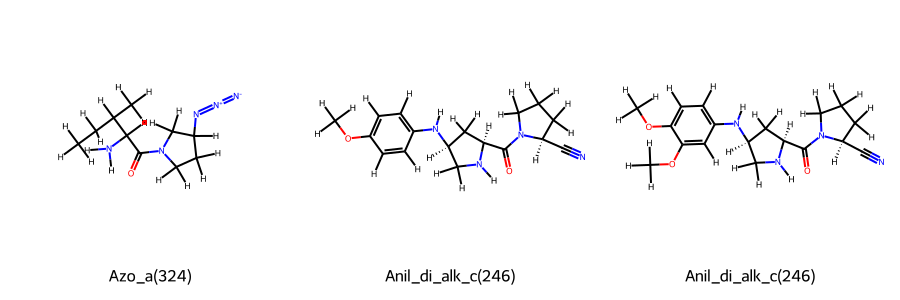

In [85]:
# visualize 3 pains in molecules_ro5_fulfilled

# Draw the first 3 PAINS
first_3_mols = matches_ro5_fulfilled["rdkit_molecule"].head(3).tolist()
legends = matches_ro5_fulfilled["pains"].head(3).tolist()
img = Draw.MolsToGridImage(first_3_mols, legends=legends, molsPerRow=3, subImgSize=(300, 300))
img



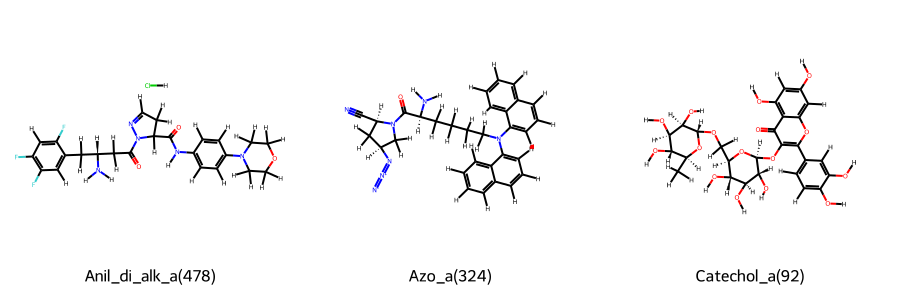

In [86]:
# Same for molecules_ro5_violated
# Draw the first 3 PAINS
first_3_mols = matches_ro5_violated["rdkit_molecule"].head(3).tolist()
legends = matches_ro5_violated["pains"].head(3).tolist()
img = Draw.MolsToGridImage(first_3_mols, legends=legends, molsPerRow=3, subImgSize=(300, 300))
img

Let’s have a look at the first 10 identified PAINS.

<class 'IPython.core.display.Image'>


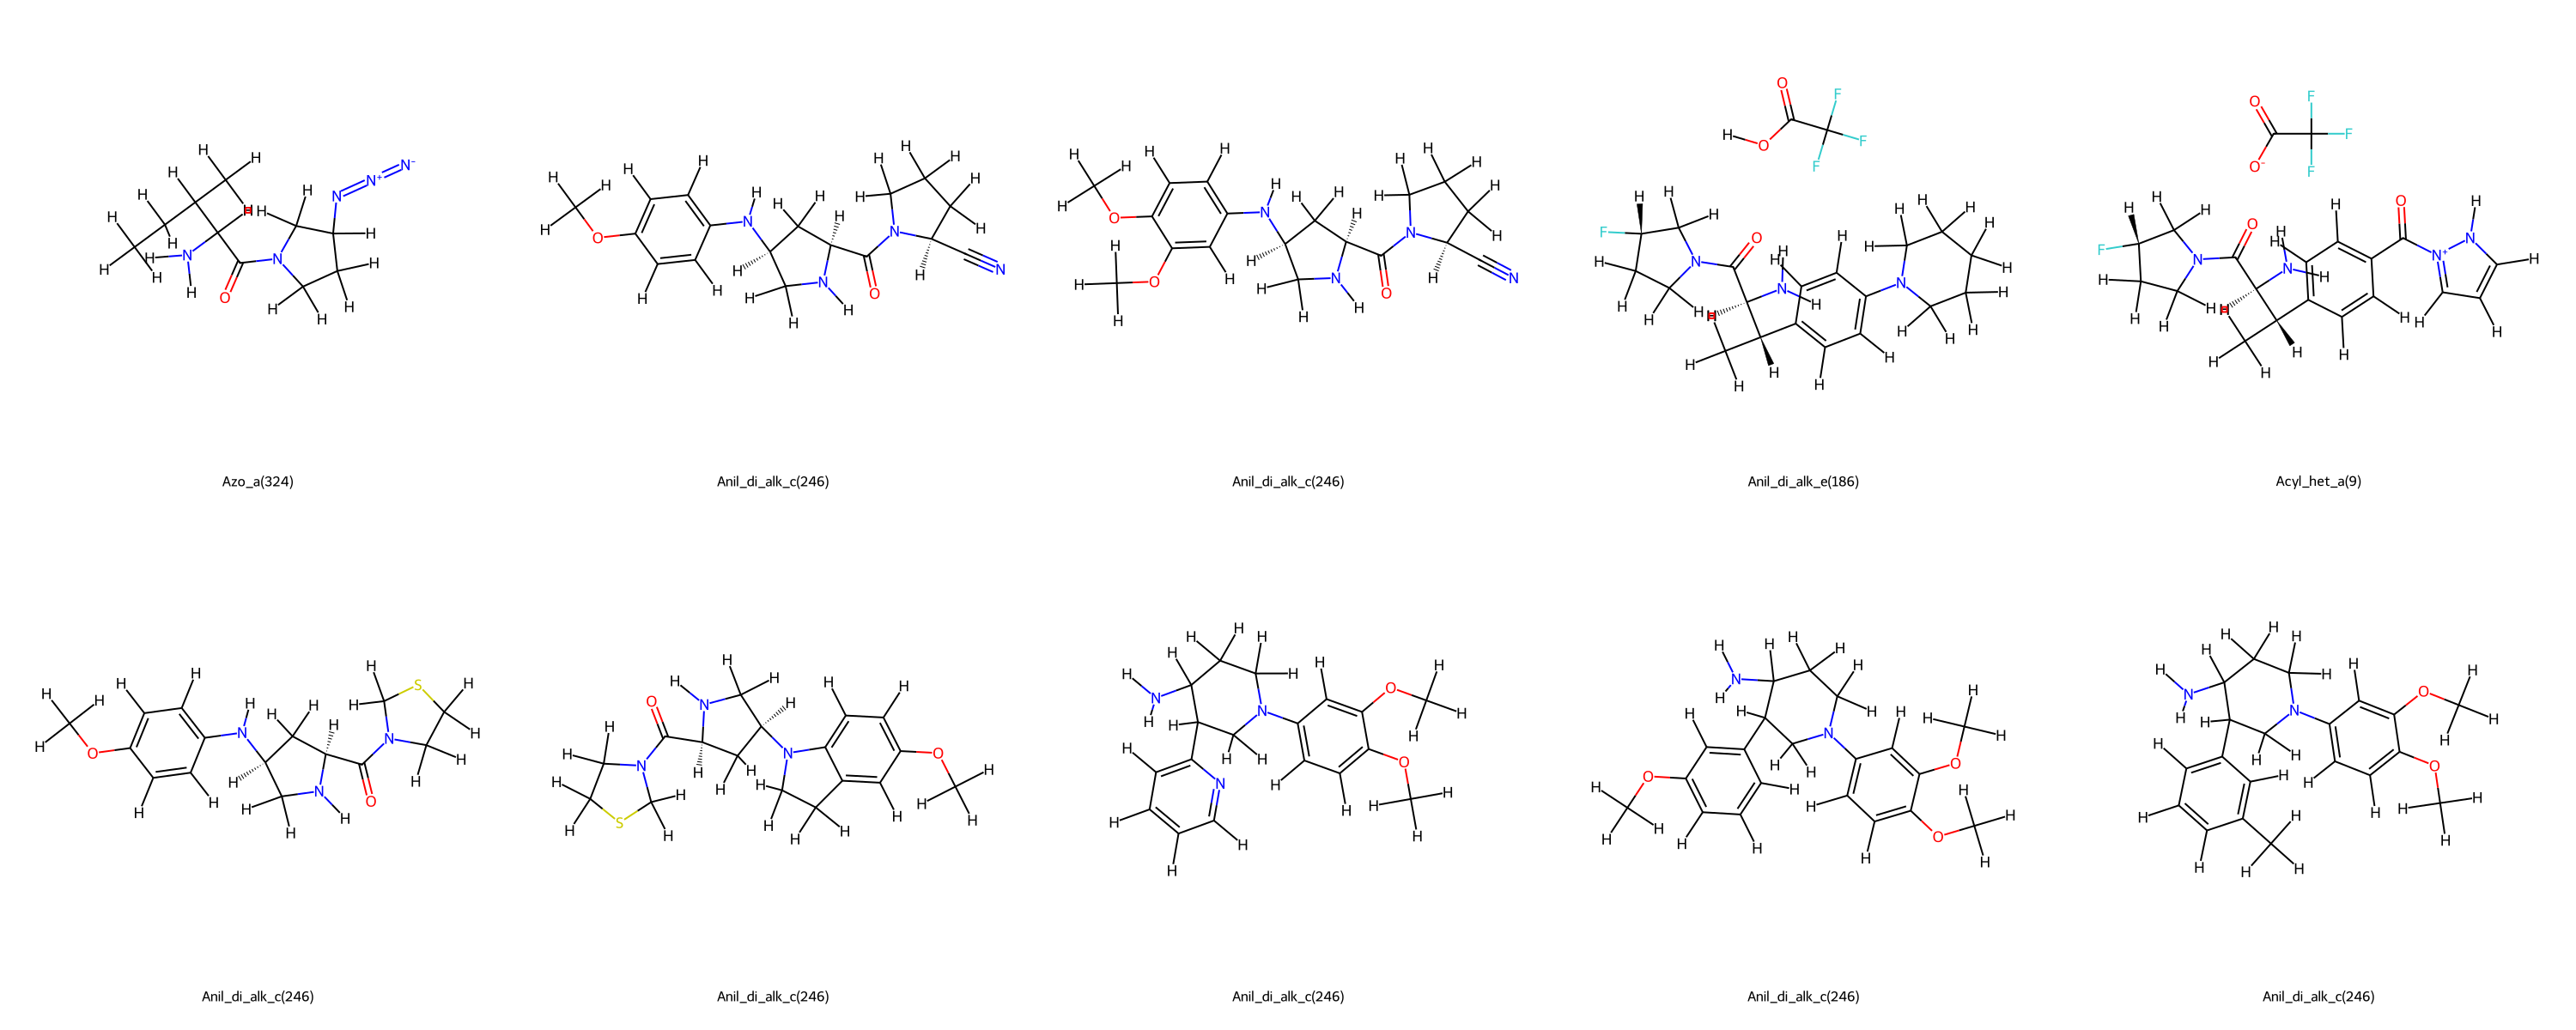

In [87]:
first_10_mols = matches["rdkit_molecule"].head(10).to_list()

legends = matches["pains"].head(10).to_list()

img = Draw.MolsToGridImage(first_10_mols, molsPerRow=5,subImgSize=(600,600),legends=legends,useSVG=False)

print(type(img))

img

**Question**: Why catechols are "bad"? Select 3 PAINS and explain why they're "bad". What could happen if you'll have one of this structures in your ligand molecule? Why should we exclude this structures from further analysis? Check the literature to find questions.

In the "pains" column you can see why this specific molecule matched PAINS filter (because of which substructure in the entire molecule structure).

These are compounds that often give false positive results in screenings for biological activity.

The legends parameter is used to display the description of the PAINS below each molecule.

**Questions to answer**:
*   Find information what does `Azo_a(324)` PAINS means? Why do we need to exclude it from further analysis?
*   Find information what does `Catechol_a(92)` PAINS mean? Why do we need to exclude it from further analysis?
*   Find information what do `Anil_di_alk_c(246)` and `Anil_no_alk(40)` PAINS mean? Why do we need to exclude them from further analysis?
*   Find information what does `Indol_3yl_alk(461)` PAINS mean? Why do we need to exclude it from further analysis?
*   Find information what does `Quinone_a(370)` PAINS mean? Why do we need to exclude it from further analysis?
*   Find information what does `Het_pyridiniums_a(39)` PAINS mean? Why do we need to exclude it from further analysis?

In [88]:
def draw_filtered_mols_with_highlighted_substructures(matches, smarts_pattern):
    # Define the SMARTS pattern for the substructure
    pattern = Chem.MolFromSmarts(smarts_pattern)

    # Generate a new matches list for the filtered molecules
    filtered_matches = [mol.GetSubstructMatch(pattern) for mol in matches['rdkit_molecule'] if mol.HasSubstructMatch(pattern)]

    # Get the molecules that have the substructure
    filtered_mols = [mol for mol in matches['rdkit_molecule'] if mol.HasSubstructMatch(pattern)]

    # Get the corresponding legends for the filtered molecules
    filtered_legends = [legend for mol, legend in zip(matches['rdkit_molecule'], matches["pains"]) if mol.HasSubstructMatch(pattern)]

    # Now, filtered_mols contains only the molecules that have the substructure
    return Chem.Draw.MolsToGridImage(
        filtered_mols,
        legends=filtered_legends,
        highlightAtomLists=filtered_matches
    )

Now let's hightlight specific PAINS substructure in molecules using specially prepared for that `draw_filtered_mols_with_highlighted_substructures` function.

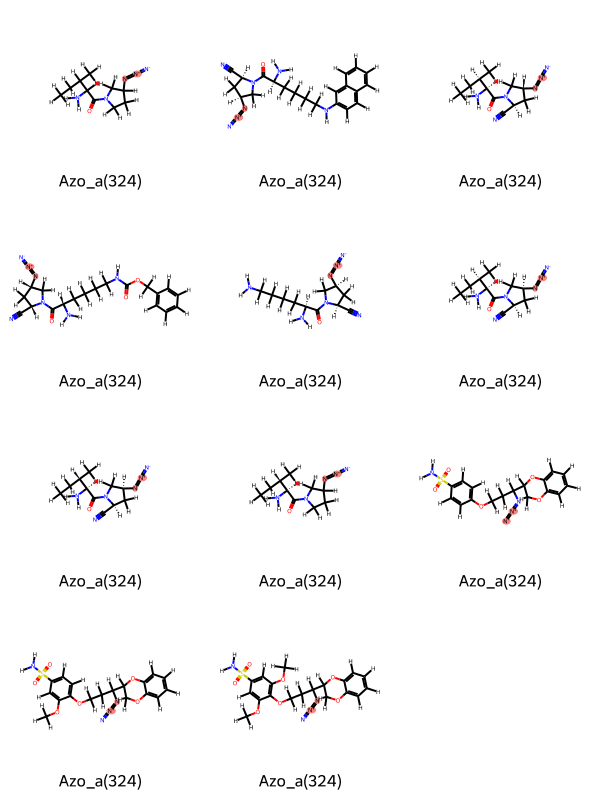

In [89]:
azo_a_324_pattern = 'N=N'

azo_structures = draw_filtered_mols_with_highlighted_substructures(matches, azo_a_324_pattern)

# Display the images
display(azo_structures)

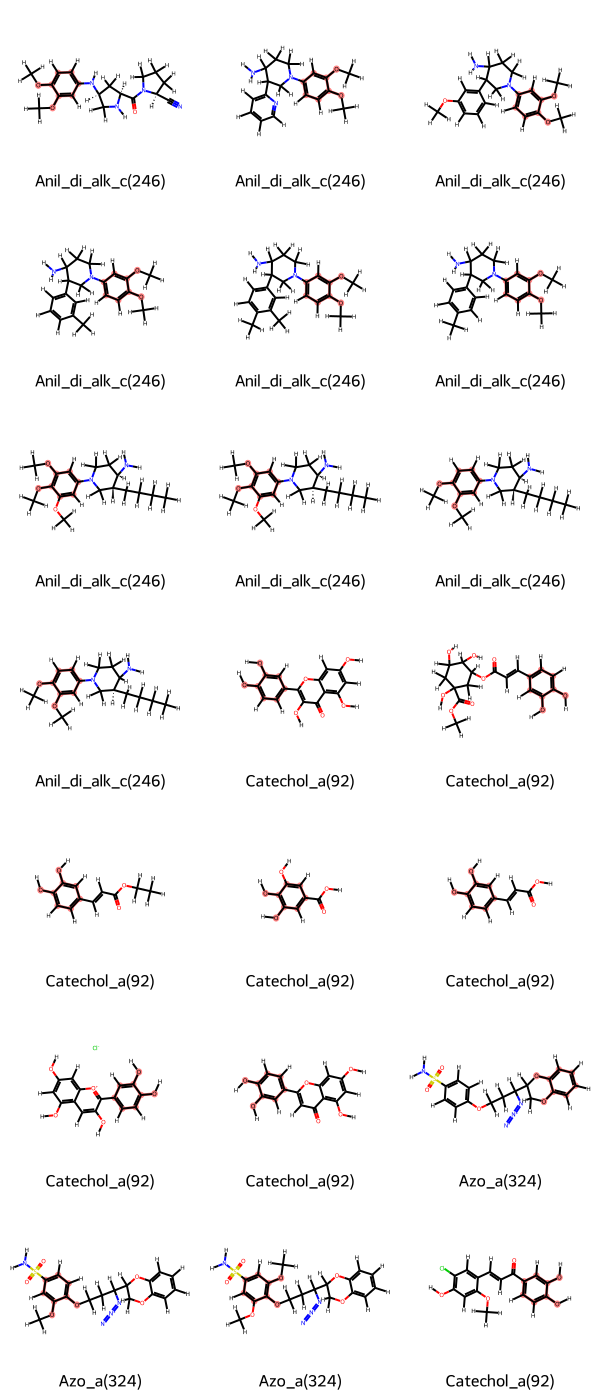

In [90]:
catechol_a_92_pattern = 'c1cc(O)c(O)cc1'

catechol_structures = draw_filtered_mols_with_highlighted_substructures(matches, catechol_a_92_pattern)

# Display the images
display(catechol_structures)

Let’s have a look at the first 10 compounds without PAINS.

In [91]:
display(HTML(cleaned_df.head().to_html()))

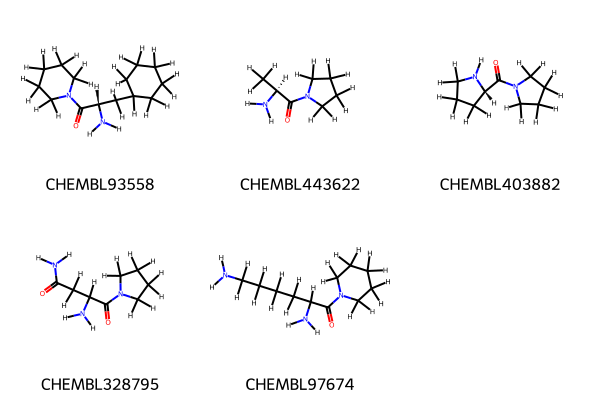

In [92]:
Chem.Draw.MolsToGridImage(
    list(cleaned_df.head().Mol),
    legends=list(cleaned_df.head()["molecule_chembl_id"]),
)

Now let's save filtered by RO5 and PAINS molecules in `csv` file.

Note: don't forget to remove 'Mol' column.

In [93]:
matches_write_csv = matches.drop(["rdkit_molecule"],axis=1)
matches_write_csv.to_csv("pains_matches.csv")

cleaned_df_csv = cleaned_df.drop(["Mol"],axis=1)
cleaned_df_csv.to_csv("ro5_cleaned_pains.csv")


**Result of your today's work PART 4**: you've learned how to perform a search for unwanted substructures with RDKit.

----------------------

# Ligand-based virtual screening (LBVS)

In this section you'll:
- find out what is ligand-based screening (based on compound similarity to ligand that is known to interact with target).
- get familiar with different approaches to encode (descriptors, fingerprints) and compare (similarity measures) molecules
- perform a virtual screening in the form of a similarity search for the EGFR inhibitor AFATINIB against the dataset of EGFR-tested molecules from the ChEMBL database filtered by Lipinski’s rule of five and PAINS.

Molecular similarity is a well known and often used concept in chemoinformatics. Comparing molecules and their properties can be used in many different ways and help us to identify new molecules with desired properties and biological activity.

The similar property principle (SPP) as well as the structure-activity relationship (SAR) approaches are based on the assumption that structurally similar molecules have similar properties and, thus, similar biological activity. In this context, virtual screening follows this idea to search for similar molecules in given a set of molecules with known binding affinity and to propose those as potentially new active molecules.

Similarity can be assessed in many different ways depending on the application. For more details: https://pubmed.ncbi.nlm.nih.gov/24151987/.

## Molecular fingerprints - 2D descriptors

**Molecular fingerprints** are a way to represent molecules as mathematical objects. They are related to **2D molecular descriptors**. Due to their, mostly, uniqueness per molecule, these descriptors are called fingerprints.

Molecular fingerprints are mathematical representations of molecular structures that encode structural information into a form that computers can easily process. They're crucial in cheminformatics for similarity searching (evaluating fingerpring **similarity** of different molecules), virtual ligand-based screening, and machine learning applications.

A fingerprint is a simplified code for a molecule (drug). It's like a tag that captures the key features (chemical and molecular features) of the molecule without all the complex details.

This features are represented in the form of bitstrings, bitvectors or arrays. Each bit corresponds to a predefined molecular feature or environment, where “1” represents the presence and “0” the absence of a feature. This 0s and 1s, kind of like a barcode, represent these features.

Molecular fingerprints are used in drug discovery for many reasons:

*   **For classification and clustering and comparison tasks**: We need molecular fingerprints to calculate molecular similarity. They are useful when trying to conduct similarity searches and other comparison tasks. This is useful when trying to perform classification and clustering.
*   **Fast searching based on similarity**: Instead of comparing every single molecule in the keychain (millions of possibilities!), fingerprints allow researchers to quickly identify similar ones based on their codes.
*   **Finding similar effects**: If an existing drug has a known effect, scientists can use its fingerprint to find other molecules with similar codes. These might have similar effects and become potential new drugs.
*   **Predicting properties**: By analyzing fingerprint similarities, scientists can make educated guesses about a molecule's properties, like its potential biological activity.


Molecular fingerprints are a computational representation of molecules that encode chemical and molecular features in the form of bitstrings, bitvectors or arrays. Each bit corresponds to a predefined molecular feature or environment, where “1” represents the presence and “0” the absence of a feature. Note that some implementations are count-based. Thus, they count how often a specific feature is present.

There are multiple types of 2D fingerprints:

1. MACCS (Molecular ACCess System Keys) Keys (predefined fragments): consist of 166 predefined structural fragments that are common building blocks used to construct molecules. The MACCS fingerprint is a 166-bit code (like a barcode with 166 positions), where each bit represents one common building blocks used to construct molecules.

- A "1" in a position means that particular building block is present in the molecule.
- A "0" means that building block is absent.  

That's like a list of presence / absence specific parts of molecule (structural fragment or key) in molecule's structure, with only 2 options: present and absent. MACCS fingerprints are like a basic checklist, good for quick screening.

Mechanism:
- Checks for the presence/absence of 166 predefined substructures (e.g., carbonyls, halogens, rings).
- Each bit represents a specific SMARTS pattern.

Usage in LBVS:
- Quick triaging of large libraries and initial exploratory clustering before more specialized approaches
- Baseline benchmark in ML studies
- Clustering based on pharmacologically relevant features
- For datasets where functional group patterns drive the property of interest

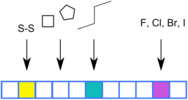

The individual keys (166) were empirically defined by medicinal chemists and are simple to use and interpret.

The RDKit supports a number of different fingerprinting algorithms and fingerprint types. `rdkit` documentation on MACCS keys you can find here: http://rdkit.org/Python_Docs/rdkit.Chem.MACCSkeys-module.html.

2. Morgan Fingerprints (circular fingerprints; ECFP):  these are more flexible for complex comparisons, based on the Morgan algorithm.

Imagine zooming in on each atom and looking at its surrounding within a certain distance (like a circle). The bits correspond to the circular environments (circle) of each atom in a molecule. The fingerprint encodes the types of atoms and bonds within that circle. It considers the types of atoms and bonds present within that circle. A larger radius captures more complex features. It's like describing the neighborhood around each atom in a molecule.

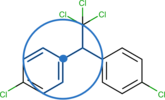

Morgan fingerprint is not limited to a certain number of bits. 

More about the Morgan fingerprint can be found in the `rdkit` documentation [http://www.rdkit.org/docs/GettingStartedInPython.html#morgan-fingerprints-circular-fingerprints]. 

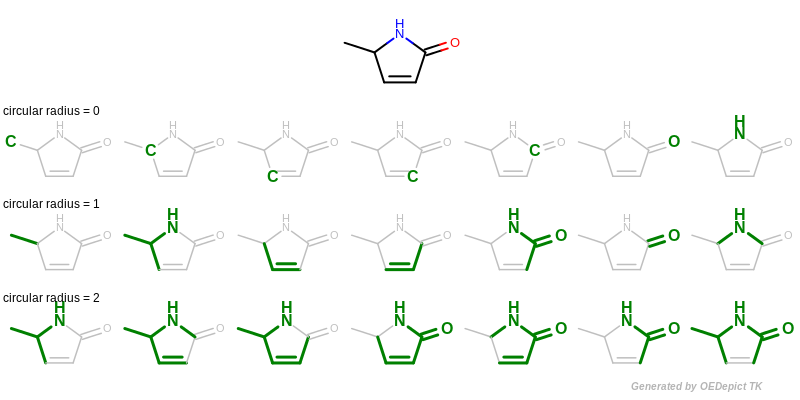

Captures: local atomic environments. Focuses on circular environments around atoms.

Morgan fingerprints work by:
1) Starting at each atom in the molecule.
2) Looking at circular environments around that atom (radius 2 means looking up to 2 bonds away)
3) Generate for this atom a unique identifier based on atom types, bonds, and connectivity (within circular environments). This way it hashes circular atom neighborhoods (radius defines substructure size).

--> The result (unique identifier) captures local chemical environments

Usage in LBVS:
- Most popular choice for similarity-based virtual screening
- Ideal as input features for machine learning models (due to their ability to capture local structural information), clustering, SAR analysis
- When searching for analogues of a known active ligand

To learn more about Morgan fingerprints read: https://pubs.acs.org/doi/10.1021/ci100050t, https://pubs.acs.org/doi/full/10.1021/ci100050t. 

3.  Topological Torsion Fingerprint (RDKit Fingerprints)

Topological Torsion fingerprints focus on sequences of four connected atoms (torsions), capturing information about the molecule's topology.

Mechanism:

- All sequences of four connected atoms are identified and ensoded (to capture local topology and stereoelectronic effects in the sequences of this 4 atoms)
- Each sequence is characterized by the atom types and bond types.
- These sequences are hashed to generate the fingerprint bits.​

Usage in LBVS:

- When stereochemistry or conformational detail matters
- modeling conformational flexibility analysis (conformational analysis)
- 3D-QSAR studies.
- Datasets where molecular flexibility is critical to function
- Distinguishing between rigid and flexible scaffold systems
- When conformational preferences are believed to drive the property of interest

4. Atom Pair Fingerprint

Atom Pair fingerprints encode information about all pairs of atoms in a molecule, considering the types of atoms and the topological distance between them.​

Mechanism:

- For every pair of atoms, a tuple is created containing the atom types and the number of bonds separating them.
- These tuples (each tuple = separate atoms pair) are hashed (based on atom types and distance) to set bits in the fingerprint vector.​

Captures: atom pairs & distances

Usage in LBVS:
- When scaffold diversity is important
- In quantitative structure-activity relationship (QSAR) modeling
- For 3D surrogate methods or rough shape filtering (capturing global molecular features)
- Good in early exploratory phases
- When molecular shape and topology are key determinants of your property
- Clustering scaffold-related compounds with varying substituents
- Datasets where atom distribution throughout the molecule matters

5. RDKit Fingerprint (RDKFingerprint)

The RDKit fingerprint is a topological fingerprint that focuses on linear paths through the molecule.

Mechanism:

- Identifies all possible linear subgraphs (linear paths of atoms through the molecule) up to a specified length (default path length = 7). Each path is characterized by the sequence of atom and bond types.
- Enumerate them.
- For each path:
    - Generate a descriptor of the path (atoms and bonds involved)
    - Hash this to determine which bits to set in the fingerprint vector.​

Usage in LBVS:
- When doing classic Tanimoto similarity = quick similarity comparison (due to their simplicity and speed)
- For substructure-based searching

Learn more about fingerprints via:

- https://www.blopig.com/blog/2022/06/exploring-topological-fingerprints-in-rdkit/
- https://www.rdkit.org/UGM/2012/Landrum_RDKit_UGM.Fingerprints.Final.pptx.pdf
- https://nextmovesoftware.com/talks/Mayfield_FingerprintHotTakes_RDKIT_UGM2022.pdf
- https://pure.tue.nl/ws/portalfiles/portal/324082367/s13321-024-00830-3.pdf 


In ligand-based virtual screening (LBVS), choosing the right molecular fingerprint is crucial for capturing relevant chemical features and optimizing hit discovery. 

**How to choose the appropriate for dataset situation fingerprint?**

The choice between these fingerprints depends on the specific needs of your drug discovery project.

*  For rapid initial large-scale screening and fast similarity searching: use MACCS (MACCS keys offer speed and simplicity).
*  For in-depth analysis and predictive modeling: use Morgan fingerprints (provide detailed structural insights).
*  For exploring diverse scaffolds (distinct core structures): use Atom Pair fingerprints. Their ability to capture global molecular topology (considering all pairs of atoms and their topological distances) makes them effective for scaffold hopping and assembling diverse compound libraries. It is crucial for discovering novel chemotypes and avoiding redundancy. 
*  For SAR (Structure-Activity Relationship) & analog search: use Morgan fingerprints with an appropriate radius (classic = 2). In SAR and analog search, where understanding the impact of small structural changes on biological activity is crucial, ECFP4 (Morgan fingerprints with radius 2) is the preferred choice. Its ability to capture detailed local structural information makes it highly effective for identifying and analyzing analogs in medicinal chemistry.
    - Structure-Activity Relationship (SAR) refers to the process of understanding how changes in a molecule's structure affect its biological activity. This involves analyzing a series of related compounds (analogs) to determine which structural features are critical for activity.​
    - Analog search is a method used to identify compounds structurally similar to a known active molecule. The goal is to find new compounds (analogs) that may exhibit similar or improved biological activity.
*  For studying conformational aspects: use Topological Torsion fingerprints
*  for fast similarity searching (classic Tanimoto similarity) and substructure-focused searches: use RDKFingerprint

In [94]:
from rdkit import Chem, DataStructs

We are going to use filtered from PAINS dataset that follows RO5 from previous section of exercises  (`cleaned_df`) to compare different types of descriptors and possibility of using them to measure molecular similarity.

Let's sort molecules by molecular weight

In [95]:
cleaned_df = cleaned_df.sort_values(by="MolWT",ascending=False)
cleaned_df.head(5)

molecule_chembl_id                                             smiles  \
2196      CHEMBL2147056  Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2c3ccc(C(=...   
1446       CHEMBL482154  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc(C(=O)O)cc2)...   
1436       CHEMBL480550  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc3c(c2)OCO3)C...   
1448       CHEMBL475654  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2cccc(C(=O)O)c2)...   
2656      CHEMBL3675624  CC(C)=CCn1c(N2CCC[C@@H](N)C2)nc2c1C(=O)N(Cc1nc...   

                                                Mol    IC50     pIC50  \
2196  <rdkit.Chem.rdchem.Mol object at 0x17efe09e0>    0.55  8.259637   
1446  <rdkit.Chem.rdchem.Mol object at 0x17efc7990>  223.00  5.651695   
1436  <rdkit.Chem.rdchem.Mol object at 0x17efc7450>  490.00  5.309804   
1448  <rdkit.Chem.rdchem.Mol object at 0x17efc7c30>   50.00  6.301030   
2656  <rdkit.Chem.rdchem.Mol object at 0x17eff00b0>    1.61  7.793174   

      molLogP    tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
2196  3.43152  106.38  499.974                  7           2              8   
1446  2.85850  103.94  499.917                  7           2              5   
1436  2.88900   85.10  499.917                  6           1              5   
1448  2.85850  103.94  499.917                  7           2              5   
2656  2.86042  108.77  499.623                  9           1              9   

      ro5_fulfilled  
2196           True  
1446           True  
1436           True  
1448           True  
2656           True

- We're not interested in metals - please, remove them from dataset
- It case you have salts (cation + anoin) - please remove the smaller fragment.

In [96]:
from rdkit.Chem.MolStandardize import rdMolStandardize

remover = rdMolStandardize.FragmentRemover()

cleaned_df["Mol"] = cleaned_df["Mol"].apply(lambda mol: remover.remove(mol) if mol is not None else None)

# Make Largest Fragment Chooser()

lfg = rdMolStandardize.LargestFragmentChooser()

cleaned_df["Mol"] = cleaned_df["Mol"].apply(lambda mol: lfg.choose(mol) if mol is not None else None)

# Sanity Check Drop Molecules that are None or Empty
cleaned_df = cleaned_df[cleaned_df["Mol"].notnull()]
cleaned_df = cleaned_df[cleaned_df["Mol"].apply(lambda m: m.GetNumAtoms() > 0)]
cleaned_df = cleaned_df.reset_index(drop=True)





[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running FragmentRemover
[13:25:06] Running F

In [97]:
cleaned_df.shape

(3093, 12)

Is the **molecular weight** a feasible descriptor **(1D descriptor)** for molecule similarity? Why / why not?

Researchers often use multiple descriptors (such as molecular weight, fingerprints, and physicochemical properties) to enhance similarity assessments.
Combining molecular weight with other features provides a more comprehensive view of structural similarity.

In order to account for more detailed properties of a molecule, now let's take a look at 2D molecular descriptors.

**2D molecular descriptors = molecular fingerprints**

In `rdkit`, molecular fingerprints are algorithms that encode molecular structures into numerical representations, facilitating tasks like similarity searches and machine learning. 

In `rdkit` all supported fingerprinting algorithms can be used the same way: first you need create a **generator** for that fingerprint algorithm with the appropriate parameters set, and then ask the generator to give you the fingerprint type you want for each molecule.

There are different functions to initialize fingerprint generators from `rdkit`:

- for Morgan fingerprint (Circular Fingerprint): `GetMorganGenerator`
- for RDKit fingerprint: `GetRDKitFPGenerator`
- for atom pair fingerprint: `GetAtomPairGenerator`
- for topological torsion fingerprint: `GetTopologicalTorsionGenerator`

In [98]:
from rdkit.Chem import rdFingerprintGenerator

# Initialize fingerprint generators for all 4 types of fingerprints
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
ap_gen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
tt_gen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)

Fingerprinting algorithms supported by the fingerprint generators are:

- Morgan
- Feature Morgan (this is a variation of the Morgan fingerprint)
- RDKit
- Atom pairs
- Topological torsions

You can find out which options are available by introspecting the functions which create generators: `help(rdFingerprintGenerator.GetRDKitFPGenerator)`

In RDKit, MACCS keys are implemented separately from the other fingerprint generators like Morgan, Atom Pair, Topological Torsion, and RDKit fingerprints. 

They are accessed through the `MACCSkeys` module.

**MACCS fingerprint**

The MACCS (Molecular ACCess System) keys are a set of 166 predefined structural keys used to represent molecular structures as binary fingerprints. Each bit in the MACCS fingerprint corresponds to a specific substructure or molecular feature, and the bit is set to 1 if the feature is present in the molecule, otherwise it's set to 0.

MACCS fingerprints can be easily generated using `rdkit` module `Chem.MACCSkeys` (`GenMACCSKeys` function).

Let's add MACCS fingerprints for all molecules to the DataFrame.

In [99]:
from rdkit.Chem import MACCSkeys

cleaned_df["MACCS"] = cleaned_df["Mol"].apply(MACCSkeys.GenMACCSKeys)




`GenMACCSKeys` function will output a 167-bit string (including a leading bit that's always zero), where each bit represents the presence or absence of a specific structural feature as defined in the MACCS keys.​

MACCS keys are not generated using generator. Instead, they rely on a set of SMARTS patterns defined in the RDKit source code. Each SMARTS pattern corresponds to a specific structural feature, and the presence of that feature in the molecule sets the corresponding bit in the fingerprint.

**2D molecular descriptors: Morgan fingerprint**

Morgan Fingerprint encodes the circular environments around each atom in a molecule, capturing local structural features.

We can also calculate the circular Morgan fingerprints with `rdkit`. 

As always: 

- 1 - create generator
- 2 - using this generator you can generate fingerprint for the molecule.

The Morgan fingerprint can be calculated as 

- int vector
- bit vector. 


Let's generate the Morgan fingerprint as *int* vector first.

The fingerprint generator knows how to create four separate types of fingerprints:

- `fpgen.GetFingerprint(m)`: returns a bit vector of size fpSize
- `fpgen.GetCountFingerprint(m)`: returns a count vector of size fpSize
- `fpgen.GetSparseFingerprint(m)`: returns a sparse bit vector
- `fpgen.GetSparseCountFingerprint(m)`: returns a sparse count vector

The sparse bit and count vectors are of variable size, depending on the fingerprint type, but are always very large (at least 2^32-1).


Here’s a demonstration of that:

In [100]:
test_mol = cleaned_df["Mol"].iloc[0]



# bit vectors:
fp = morgan_gen.GetFingerprint(test_mol)
sfp = morgan_gen.GetSparseFingerprint(test_mol)

# count vectors:
cfp = morgan_gen.GetCountFingerprint(test_mol)
scfp = morgan_gen.GetSparseCountFingerprint(test_mol)

print(f'fp: {type(fp)} {len(fp)}')
print(f'sfp: {type(sfp)} {len(sfp)}')
print(f'cfp: {type(cfp)} {cfp.GetLength()}')
print(f'scfp: {type(scfp)} {scfp.GetLength()}')

fp: <class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'> 2048
sfp: <class 'rdkit.DataStructs.cDataStructs.SparseBitVect'> 4294967295
cfp: <class 'rdkit.DataStructs.cDataStructs.UIntSparseIntVect'> 2048
scfp: <class 'rdkit.DataStructs.cDataStructs.ULongSparseIntVect'> 18446744073709551615


In [101]:
from rdkit.DataStructs import ConvertToNumpyArray


def get_morgan_int_vector(mol: Chem.Mol):
    """
    Returns the Morgan count (integer) fingerprint as uint32 array.
    """
    
    fp = morgan_gen.GetCountFingerprintAsNumPy(mol)  # RD Kit Vector
    return fp

def get_morgan_bit_vector(mol: Chem.Mol):
    """
    Returns the Morgan bitvector fingerprint as uint8 array.
    """
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    return fp

Generate and add Morgan fingerprints (as int vector) for all molecules to the DataFrame.

In [102]:
# Apply to all molecules: calculate for morgan integer fingerprint and save in separate column `morgan_int_fingerprint`
cleaned_df["morgan_int_fingerprint"] = cleaned_df["Mol"].apply(get_morgan_int_vector)
cleaned_df["morgan_bit_fingerprint"] = cleaned_df["Mol"].apply(get_morgan_bit_vector)


- In the integer representation, each circular substructure (environment) is assigned a unique integer value.
- The fingerprint is essentially an array of integers, where each integer corresponds to a specific circular substructure.
- This is a compressed format where multiple bits are packed into a single integer.
- The integers represent the presence or absence of these substructures in the molecule.
- The length of the integer array was assigned before = 2048 bits.

**Advantages:**

- Can be faster for some operations like comparisons if efficiently implemented.

**Disadvantages:**

- Requires additional processing to convert between the integer representation and the actual bit positions.
- Might be less intuitive for human interpretation, as the meaning of specific bits within the integer is not directly obvious.
- less memory-efficient.

Generate and add Morgan fingerprints (as bit vector) for all molecules to the DataFrame.

In [103]:
# same for bit fingerprint - in `morgan_bit_fingerprint` column

- In the bit vector representation (also called the bit string), each circular substructure is mapped to a specific bit position.
- The fingerprint is an array of bits (0s and 1s) directly represents the fingerprint. Each bit corresponds to a specific feature in the molecule (each bit represents the presence (1) or absence (0) of a substructure).
- The length of the integer array was assigned before = 2048 bits.

**Advantages:**

- More flexible for operations that require access to individual bits.
- memory-efficient.
- handles collisions better.
- aligns well with similarity calculations.

**Disadvantages:**

- Might be slower for some comparison operations depending on the implementation.

There's no single "best" format. The choice depends on your specific needs, considering factors like storage requirements, processing speed, and the level of interpretation needed.

**Differences:**
 - Data Type:
      - Integers: Use integer values (e.g., 0, 1, 2, 3, …).
      - Bit Vectors: Use binary values (0 or 1).

 - Sparse vs. Dense:
      - Integers: Can be sparse (many zeros) if there are few circular substructures.
      - Bit Vectors: Typically sparse (fewer 1s) due to the nature of circular substructures.

 - Collision Handling:
      - Integers: May have collisions (different molecules producing the same integer fingerprint).
      - Bit Vectors: Less prone to collisions due to the binary representation.

 - Memory Efficiency:
      - Integers: Require more memory due to their larger array size.
      - Bit Vectors: Are indeed more memory-efficient, providing a compact representation.

**Use Cases:**

- Integer Representation:
    - When you need a unique integer-based representation for each circular substructure.
    - Useful for certain machine learning algorithms that work directly with integers.

- Bit Vector Representation:
    - Widely used in similarity searches (Tanimoto or Dice similarity) and virtual screening.
    - Efficient for large-scale comparisons of molecular fingerprints.
    - Commonly used in cheminformatics toolkits (like RDKit).

Let's add other fingerprint types in the table.

In [104]:
# Generate fingerprint from different types for each of the molecules and save them in separate columns
# "rdkit_fingerprint" for RDKit fingerprint, "ap_fingerprint" for Atom pairs fingerprint, "tt_fingerprint" for Topological torsions fingerprint

# This is done !morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
#rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
#ap_gen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
#tt_gen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)

cleaned_df["rdkit_fingerprint"] = cleaned_df["Mol"].apply(rdkit_gen.GetFingerprintAsNumPy)
cleaned_df["ap_fingerprint"] = cleaned_df["Mol"].apply(ap_gen.GetCountFingerprintAsNumPy)
cleaned_df["tt_fingerprint"] = cleaned_df["Mol"].apply(tt_gen.GetCountFingerprintAsNumPy)

print(cleaned_df.head(5))

  molecule_chembl_id                                             smiles  \
0      CHEMBL2147056  Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2c3ccc(C(=...   
1       CHEMBL482154  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc(C(=O)O)cc2)...   
2       CHEMBL480550  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc3c(c2)OCO3)C...   
3       CHEMBL475654  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2cccc(C(=O)O)c2)...   
4      CHEMBL3675624  CC(C)=CCn1c(N2CCC[C@@H](N)C2)nc2c1C(=O)N(Cc1nc...   

                                             Mol    IC50     pIC50  molLogP  \
0  <rdkit.Chem.rdchem.Mol object at 0x18021d8c0>    0.55  8.259637  3.43152   
1  <rdkit.Chem.rdchem.Mol object at 0x18021d930>  223.00  5.651695  2.85850   
2  <rdkit.Chem.rdchem.Mol object at 0x18021d9a0>  490.00  5.309804  2.88900   
3  <rdkit.Chem.rdchem.Mol object at 0x18021da10>   50.00  6.301030  2.85850   
4  <rdkit.Chem.rdchem.Mol object at 0x18021da80>    1.61  7.793174  2.86042   

     tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
0  106

In [105]:
cleaned_df.head(3)

molecule_chembl_id                                             smiles  \
0      CHEMBL2147056  Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2c3ccc(C(=...   
1       CHEMBL482154  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc(C(=O)O)cc2)...   
2       CHEMBL480550  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc3c(c2)OCO3)C...   

                                             Mol    IC50     pIC50  molLogP  \
0  <rdkit.Chem.rdchem.Mol object at 0x18021d8c0>    0.55  8.259637  3.43152   
1  <rdkit.Chem.rdchem.Mol object at 0x18021d930>  223.00  5.651695  2.85850   
2  <rdkit.Chem.rdchem.Mol object at 0x18021d9a0>  490.00  5.309804  2.88900   

     tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
0  106.38  499.974                  7           2              8   
1  103.94  499.917                  7           2              5   
2   85.10  499.917                  6           1              5   

   ro5_fulfilled                                              MACCS  \
0           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_int_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
2  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                              morgan_bit_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
2  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                                   rdkit_fingerprint  \
0  [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...   
1  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...   
2  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...   

                                      ap_fingerprint  \
0  [0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0,...   
1  [0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, ...   
2  [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, ...   

                                      tt_fingerprint  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...

# Molecular similarity measures

Molecular similarity is a well known and often used concept in chemical informatics. Comparing molecules and their properties can be used in many different ways and help us to identify new molecules with desired properties and biological activity.

The similar property principle (SPP) as well as the structure-activity relationship (SAR) approaches are based on the assumption that structurally similar molecules have similar properties and, thus, similar biological activity. In this context, virtual screening follows this idea to search for similar molecules in given a set of molecules with known binding affinity and to propose those as potentially new active molecules.

Once the descriptors/fingerprints are calculated, they can be compared to assess the similarity between two molecules. Molecular similarity can be quantified with a number of different similarity coefficients, two common similarity measures are the Tanimoto and Dice index.

Both Tanimoto and Dice coefficients are ways to quantify how similar two molecules are based on their fingerprints.

**1.  Tanimoto Coefficient (Jaccard Index):**

The Tanimoto coefficient (also known as the Jaccard index) measures the similarity between two sets. In the context of molecular fingerprints, it assesses the overlap between the features (bits) present in two molecules.

Formula:

**Tc(A, B) = c / (a + b - c)**

Imagine each bit in the fingerprint is like a light switch. A "1" means the feature is present (light is on), and a "0" means it's absent (light is off).

*  a: The number of features present in molecule A (number of "1"s in its fingerprint).
*  b: The number of features present in molecule B (number of "1"s in its fingerprint).
*  c: The number of features shared by both molecules A and B (number of bits that are "1" in both fingerprints).

**Tanimoto = (shared features) / (total unique features)**

The Tanimoto coefficient ranges from 0 (completely different; no similarity) to 1 (identical; perfect similarity). This coefficient focuses on the proportion of shared features relative to the total number of features observed in either molecule.

A higher Tc indicates more shared features compared to the total features observed, meaning the molecules are more similar.

Tc is quite stringent and penalizes size differences.

Researchers often apply the Tanimoto coefficient for similarity-based searches in chemical databases. For example, when screening a compound library, they compare a query molecule’s fingerprint to existing molecules to find similar candidates.

**2. Dice Coefficient:**

The Dice coefficient is another similarity measure that considers the overlap between sets. It is closely related to the Tanimoto coefficient.

Formula:

**Dc(A, B) = 2c / (a + b)**

*  a: The number of features present in molecule A (number of "1"s in its fingerprint).
*  b: The number of features present in molecule B (number of "1"s in its fingerprint).
*  c: The number of features shared by both molecules A and B (number of bits that are "1" in both fingerprints).

**Dice = (2 × shared features) / (features in A + features in B)**

Result: Range: 0 (completely different) to 1 (identical)

This coefficient focuses on the ratio of shared features to the average number of features present in both molecules. 

Dc is more forgiving of size differences, emphasizes common features.

Learn more via: https://pubmed.ncbi.nlm.nih.gov/24151987/

**Questions to answer**: 
- Why Dice gives higher values than Tanimoto?

## Virtual screening: Finding candidate drugs

The challenge in early stages of drug discovery is to narrow down a set of small molecules (molecules) from the large existing chemical space that are potentially binding to the target under investigation. 

**Problem: Chemical space is huge**

In the early stages of drug discovery, researchers face the daunting task of sifting through a vast chemical space to identify potential drug candidates.

The chemical space contains an astronomical number of possible small molecules—approximately 10^20 combinations of chemical moieties. Since experimental high-throughput screening (HTS) for the activity of all those small molecules against the target of interest is cost and time intensive, computer-aided methods are invoked to propose a focused list of small molecules to be tested. This process is called virtual (high-throughput) screening: a large library of small molecules is filtered by rules and/or patterns, in order to identify those small molecules that are most likely to bind a target under investigation.

**Solution: Virtual Screening**

To address this challenge, computer-aided methods are employed. Virtual screening aims to narrow down the list of molecules that are likely to bind to a specific target. Virtual screening (VS) is a powerful tool in drug discovery that helps researchers sift through a vast ocean of potential drug candidates (small molecules) to identify those most likely to interact with a specific biological target (like a protein). The process involves filtering a large library of small molecules based on specific rules, patterns, or similarity criteria. By using computational tools, researchers can propose a focused set of molecules for further testing (filter and prioritize candidate molecules).

### Virtual screening using similarity search

One common, first approach in virtual screening is **similarity search**. Virtual screening using similarity search is a valuable tool for drug discovery. It helps researchers navigate the vast chemical space and identify promising drug candidates for further investigation.

The idea is to compare a set of new molecules (e.g., potential drug candidates) against known active molecules (already known to bind the target = known inhibitors or ligands).
The assumption is based on the similar property principle: If two molecules are structurally similar, they may exhibit similar biological effects (similar structures often have similar effects). We need to compare fingerprints (molecular codes) to assess similarity.

Imagine a scenario where researchers have a known inhibitor for a specific enzyme.
They want to find novel compounds that might also inhibit the same enzyme.
By comparing the fingerprint of the known inhibitor with those of other molecules, they can identify structurally similar candidates.
These candidates become the focus of further experimental testing.

Benefits:

- Saves time and money by filtering out unlikely candidates (reduces the number of compounds to be experimentally tested).
Helps identify novel drug leads with unexpected structures.
- It guides researchers toward potential hits without the need for exhaustive HTS --> speeds up the overall drug discovery process.

Limitations:

- Similarity doesn't guarantee identical activity. Further testing is crucial.
- Accuracy depends on the quality of the initial known active molecules.

Requirements for similarity search include:

*   **Representation of molecules**:
Researchers need a way to represent molecules features in a computer-readable format. This representation can be in the form of molecular fingerprints (e.g., ECFP/FCFP, MACCS keys) or other descriptors. Each feature (bit) in the fingerprint corresponds to a specific substructure or property.
*   **Similarity measurement**: Researchers need a way to quantify how similar two fingerprints are. Tanimoto and Dice coefficients (similarity coefficients) are common metrics to quantify how similar two fingerprints are. The similarity coefficient considers the overlap of features (bits) between the fingerprints.
*   **Feature weighting (Optional)**: Some fingerprints allow for feature weighting. Sometimes, certain features in the fingerprint might be more important for binding than others. Weighted fingerprints assign different importance to various features (it allows us to emphasize these features during the comparison).
*   **Ranking and Prioritization**: Once the similarity scores are calculated, molecules are ranked based on their similarity to the known active compounds. Ranking the molecules of the dataset by their similarity coefficient yields the most similar molecules at the top.

Now let's apply two similarity measures, i.e. Tanimoto and Dice, to your two fingerprint types, i.e. MACCS and Morgan fingerprints, that you calculated for each of the molecules provided in the dataframe.

You need to compare all of your molecules with known ligand. In our case it will be **AFATINIB** (already approved known active drug).

**MACCS fingerprints: Tanimoto similarity and Dice similarity**

In [106]:
# we need maccs for ligand molecule (100% known that it's interact with target)
# in our case it's AFATINIB
# get it from ChEMBL and use for further calculations
from chembl_webresource_client.new_client import new_client
import pandas as pd

# Initialize the ChEMBL client
molecule = new_client.molecule
activity = new_client.activity

# Search for AFATINIB by its name
molecule_results = molecule.filter(pref_name__iexact='Sitagliptin')

# Ensure that the molecule was found
if not molecule_results:
    raise ValueError("AFATINIB not found in ChEMBL database.")

In [107]:
print(molecule_results)
chembl_id = molecule_results[0]["molecule_chembl_id"]
print("The Molecule Chembl ID is", chembl_id)

[{'atc_classifications': ['A10BH01'], 'availability_type': 1, 'biotherapeutic': None, 'black_box_warning': 0, 'chebi_par_id': 40237, 'chemical_probe': 0, 'chirality': 1, 'cross_references': [{'xref_id': 'SITAGLIPTIN', 'xref_name': 'SITAGLIPTIN', 'xref_src': 'USAN'}], 'dosed_ingredient': False, 'first_approval': 2006, 'first_in_class': 0, 'helm_notation': None, 'indication_class': None, 'inorganic_flag': 0, 'max_phase': '4.0', 'molecule_chembl_id': 'CHEMBL1422', 'molecule_hierarchy': {'active_chembl_id': 'CHEMBL1422', 'molecule_chembl_id': 'CHEMBL1422', 'parent_chembl_id': 'CHEMBL1422'}, 'molecule_properties': {'alogp': '2.02', 'aromatic_rings': 2, 'cx_logd': '-0.14', 'cx_logp': '1.26', 'cx_most_apka': None, 'cx_most_bpka': '8.78', 'full_molformula': 'C16H15F6N5O', 'full_mwt': '407.32', 'hba': 5, 'hba_lipinski': 6, 'hbd': 1, 'hbd_lipinski': 2, 'heavy_atoms': 28, 'molecular_species': 'BASE', 'mw_freebase': '407.32', 'mw_monoisotopic': '407.1181', 'np_likeness_score': '-1.40', 'num_lipins

In [108]:
# Fetch detailed information about AFATINIB
molecule_info = molecule.search(chembl_id)

print("molecule_info", molecule_info)
molecule_info = pd.DataFrame(molecule_info)
molecule_info.head(3)

molecule_info [{'atc_classifications': ['A10BH01'], 'availability_type': 1, 'biotherapeutic': None, 'black_box_warning': 0, 'chebi_par_id': 40237, 'chemical_probe': 0, 'chirality': 1, 'cross_references': [{'xref_id': 'SITAGLIPTIN', 'xref_name': 'SITAGLIPTIN', 'xref_src': 'USAN'}], 'dosed_ingredient': False, 'first_approval': 2006, 'first_in_class': 0, 'helm_notation': None, 'indication_class': None, 'inorganic_flag': 0, 'max_phase': '4.0', 'molecule_chembl_id': 'CHEMBL1422', 'molecule_hierarchy': {'active_chembl_id': 'CHEMBL1422', 'molecule_chembl_id': 'CHEMBL1422', 'parent_chembl_id': 'CHEMBL1422'}, 'molecule_properties': {'alogp': '2.02', 'aromatic_rings': 2, 'cx_logd': '-0.14', 'cx_logp': '1.26', 'cx_most_apka': None, 'cx_most_bpka': '8.78', 'full_molformula': 'C16H15F6N5O', 'full_mwt': '407.32', 'hba': 5, 'hba_lipinski': 6, 'hbd': 1, 'hbd_lipinski': 2, 'heavy_atoms': 28, 'molecular_species': 'BASE', 'mw_freebase': '407.32', 'mw_monoisotopic': '407.1181', 'np_likeness_score': '-1.40

,atc_classifications,availability_type,biotherapeutic,black_box_warning,chebi_par_id,chemical_probe,chirality,cross_references,dosed_ingredient,first_approval,first_in_class,helm_notation,indication_class,inorganic_flag,max_phase,molecule_chembl_id,molecule_hierarchy,molecule_properties,molecule_structures,molecule_synonyms,molecule_type,natural_product,oral,orphan,parenteral,polymer_flag,pref_name,prodrug,score,structure_type,therapeutic_flag,topical,usan_stem,usan_stem_definition,usan_substem,usan_year,withdrawn_flag
0,[A10BH01],1,None,0,40237.0,0,1,"[{'xref_id': 'SITAGLIPTIN', 'xref_name': 'SITA...",False,2006.0,0,None,None,0,4.0,CHEMBL1422,"{'active_chembl_id': 'CHEMBL1422', 'molecule_c...","{'alogp': '2.02', 'aromatic_rings': 2, 'cx_log...",{'canonical_smiles': 'N[C@@H](CC(=O)N1CCn2c(nn...,"[{'molecule_synonym': 'Januvia', 'syn_type': '...",Small molecule,0,True,0,False,0,SITAGLIPTIN,0,21.0,MOL,True,False,-gliptin,dipeptidyl aminopeptidase-IV inhibitors,-gliptin,2005.0,False
1,[],-1,None,0,NaN,0,-1,[],False,NaN,-1,None,None,-1,None,CHEMBL393336,"{'active_chembl_id': 'CHEMBL1422', 'molecule_c...","{'alogp': '2.02', 'aromatic_rings': 2, 'cx_log...",{'canonical_smiles': 'N[C@@H](CC(=O)N1CCn2c(nn...,"[{'molecule_synonym': 'MK-0431', 'syn_type': '...",Small molecule,0,False,-1,False,0,None,-1,16.0,MOL,False,False,None,None,None,NaN,False
2,[],-1,None,0,NaN,0,-1,[],False,NaN,-1,None,None,-1,None,CHEMBL539077,"{'active_chembl_id': 'CHEMBL1422', 'molecule_c...","{'alogp': '2.02', 'aromatic_rings': 2, 'cx_log...",{'canonical_smiles': 'Cl.N[C@@H](CC(=O)N1CCn2c...,[],Small molecule,0,False,-1,False,0,None,-1,16.0,MOL,False,False,None,None,None,NaN,False


In [109]:
# Extract the canonical SMILES and preferred name
first_entry = molecule_info.iloc[0]

ligand_smiles = first_entry["molecule_structures"]["canonical_smiles"]
ligand_name = first_entry["pref_name"]

# Display the retrieved information
print(f"Name: {ligand_name}")
print(f"SMILES: {ligand_smiles}")

Name: SITAGLIPTIN
SMILES: N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F


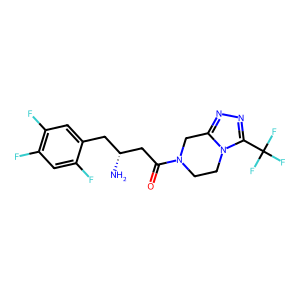

In [110]:
# Convert the SMILES string to an RDKit molecule objects and show it
ligand_mol = Chem.MolFromSmiles(ligand_smiles)

img = Draw.MolToImage(ligand_mol)
display(img)

In [111]:
#  don't forget to add explicit hydrogens before calculations and comparisons
ligand_mol = Chem.AddHs(ligand_mol)

In [112]:
# generate the maccs for ligand molecule (100% known that it's interact with target)
molecule_query_maccs = MACCSkeys.GenMACCSKeys(ligand_mol)

# and the list of maccs for all molecules in the dataset (all other molecules in the dataset).
molecule_list_maccs = cleaned_df["MACCS"].values
print("Query:", molecule_query_maccs)
print("List:", molecule_list_maccs)


Query: <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x17f69bc30>
List: [<rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x18021d770>
 ...


If you want to compare a query (target) molecule with your molecule list, use `BulkTanimotoSimilarity` and `BulkDiceSimilarity` from `rdkit DataStructs` module that calculate the similarity of a query fingerprint with a list of fingerprints, based on a similarity measure. 

In [113]:
# Calculate similarty values between query and list elements and save in separate columns `tanimoto_maccs_fingerprint` and `dice_maccs_fingerprint` in cleaned_df
from rdkit import DataStructs

tanimoto_scores = []
dice_scores = []

# Loop Through MACCS of cleaned_df

for target_fp in molecule_list_maccs:
    tanimoto = DataStructs.TanimotoSimilarity(molecule_query_maccs,target_fp)
    dice = DataStructs.DiceSimilarity(molecule_query_maccs,target_fp)
    tanimoto_scores.append(tanimoto)
    dice_scores.append(dice)

cleaned_df["tanimoto_maccs_fingerprint"] = tanimoto_scores
cleaned_df["dice_maccs_fingerprint"] = dice_scores

cleaned_df.head(2)

molecule_chembl_id                                             smiles  \
0      CHEMBL2147056  Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2c3ccc(C(=...   
1       CHEMBL482154  Cl.N[C@@H](CC(=O)N1CCCN(C(=O)c2ccc(C(=O)O)cc2)...   

                                             Mol    IC50     pIC50  molLogP  \
0  <rdkit.Chem.rdchem.Mol object at 0x18021d8c0>    0.55  8.259637  3.43152   
1  <rdkit.Chem.rdchem.Mol object at 0x18021d930>  223.00  5.651695  2.85850   

     tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
0  106.38  499.974                  7           2              8   
1  103.94  499.917                  7           2              5   

   ro5_fulfilled                                              MACCS  \
0           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_int_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                              morgan_bit_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                                   rdkit_fingerprint  \
0  [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...   
1  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...   

                                      ap_fingerprint  \
0  [0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0,...   
1  [0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, ...   

                                      tt_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

   tanimoto_maccs_fingerprint  dice_maccs_fingerprint  
0                    0.658228                0.793893  
1                    0.671642                0.803571

Sort the DataFrame by the Tanimoto similarity of the MACCS fingerprints (show only name and similarity columns).

In [114]:
sorted_tanimoto = cleaned_df.sort_values(by="tanimoto_maccs_fingerprint",ascending=False)
sorted_dice = cleaned_df.sort_values(by="dice_maccs_fingerprint",ascending=False)

print(sorted_tanimoto.head(3))
print(sorted_dice.head(3))

     molecule_chembl_id                                             smiles  \
1688       CHEMBL388475   N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1ccccc1F   
53         CHEMBL558585  Cl.N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)C(F)(F)F)C...   
1153         CHEMBL1422  N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)...   

                                                Mol       IC50     pIC50  \
1688  <rdkit.Chem.rdchem.Mol object at 0x18025c200>  98.000000  6.008774   
53    <rdkit.Chem.rdchem.Mol object at 0x18021eff0>  71.000000  6.148742   
1153  <rdkit.Chem.rdchem.Mol object at 0x18028d5b0>  20.172174  6.695247   

      molLogP   tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
1688   1.7383  77.04  371.338                  5           1              5   
53     3.0736  77.04  493.786                  6           1              5   
1153   2.0165  77.04  407.318                  5           1              5   

      ro5_fulfilled                                              

Note that Tanimoto and Dice similarity measures by definition result in the same ranking of molecules, with higher values for the Dice similarity.

The first entry will be your reference molecule (real active ligand) - check if the other highly ranked ligands are actually structurally similar.  

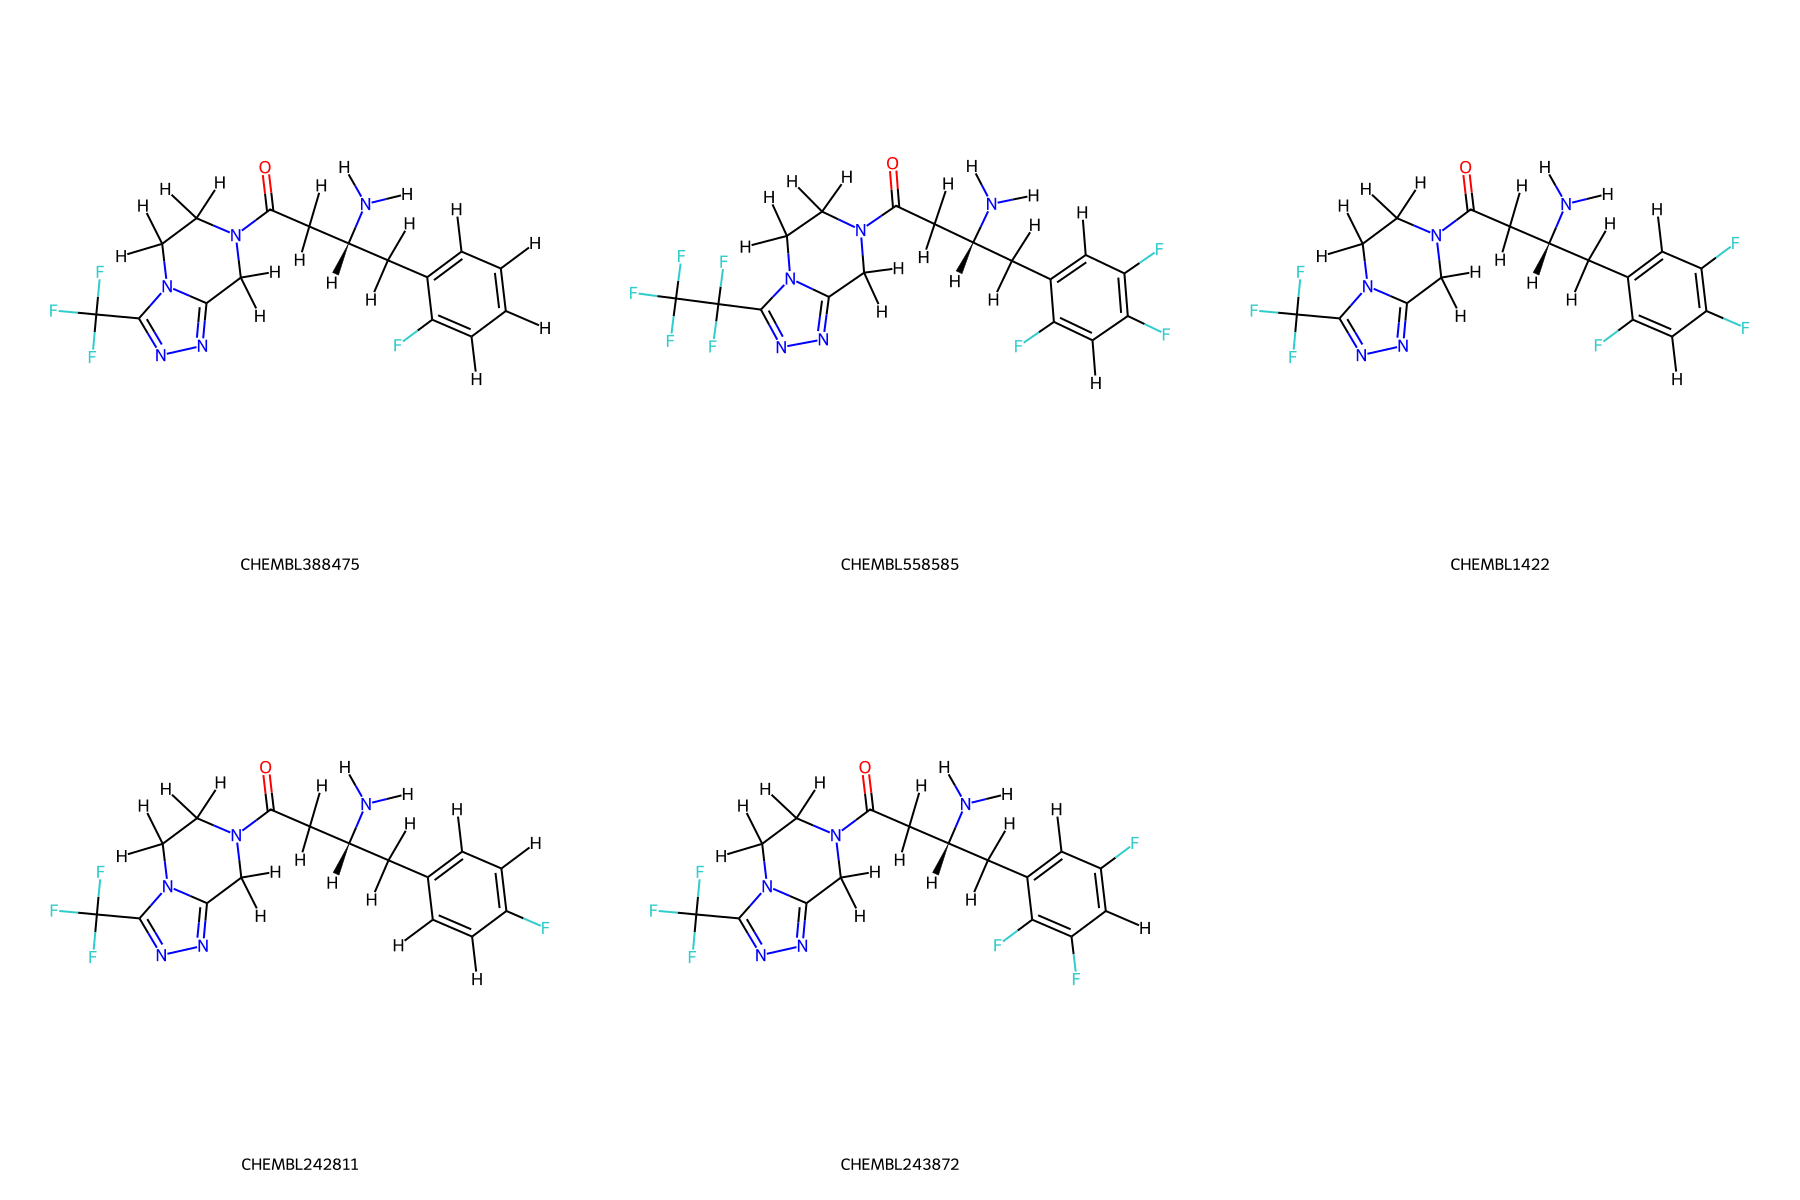

In [115]:
top_n = 5
top_ligands_tanimoto = sorted_tanimoto["Mol"].head(top_n)
top_legends_tanimoto = list(sorted_tanimoto["molecule_chembl_id"].head(top_n))

Draw.MolsToGridImage(mols=top_ligands_tanimoto,legends=top_legends_tanimoto,subImgSize=(600,600))


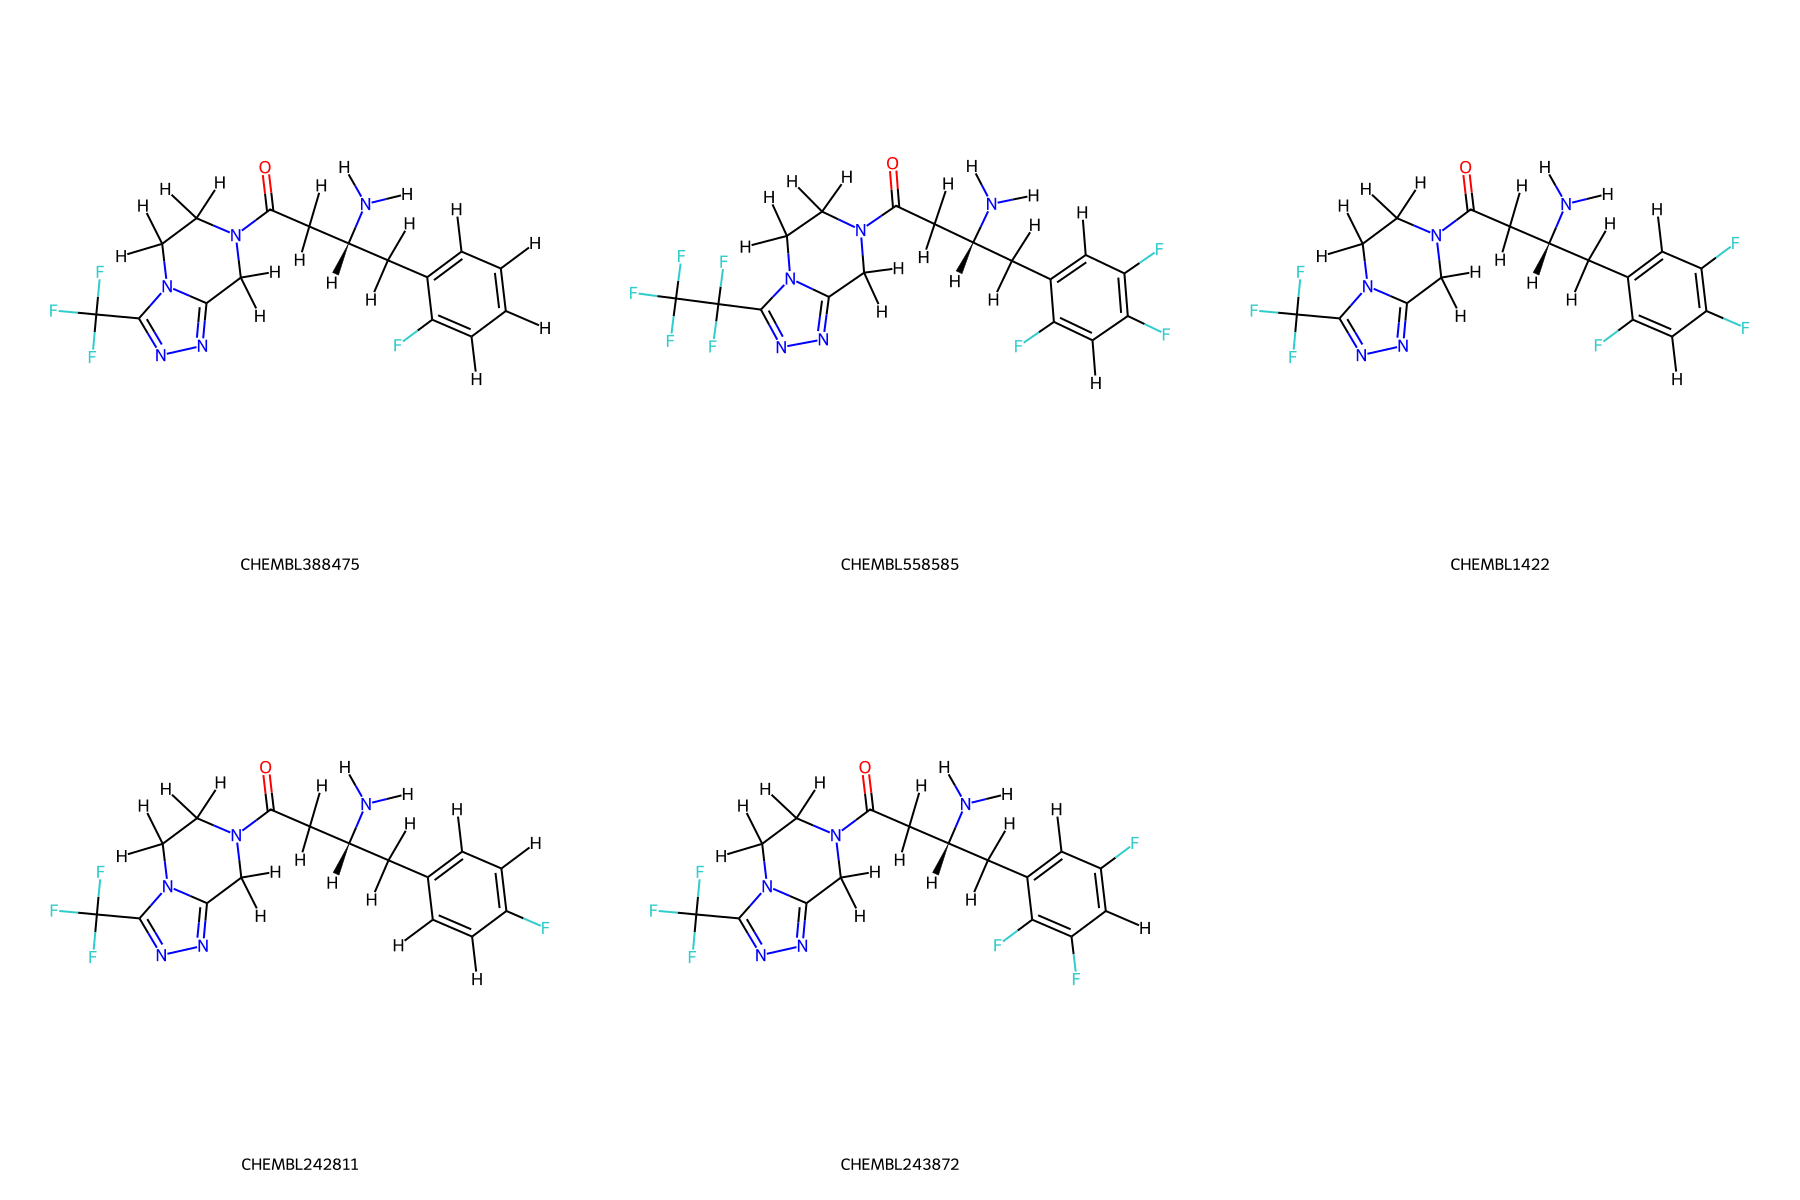

In [116]:
top_n = 5
top_ligands_dice = sorted_dice["Mol"].head(top_n)
top_legends_dice = list(sorted_dice["molecule_chembl_id"].head(top_n))

Draw.MolsToGridImage(mols=top_ligands_dice,legends=top_legends_dice,subImgSize=(600,600))

Write separate function `draw_ranked_molecules` to draw molecules ranked by the Tanimoto similarity of MACCS fingerprints.

In [117]:
def draw_ranked_molecules(molecules, sort_by_column):
    """
    Draw molecules sorted by a given column.

    Parameters
    ----------
    molecules : pandas.DataFrame
        Molecules (with "ROMol" and "name" columns and a column to sort by.
    sort_by_column : str
        Name of the column used to sort the molecules by.

    Returns
    -------
    Draw.MolsToGridImage
        2D visualization of sorted molecules.
    """

    # Sort molecules by the Column for example Tanimoto
    sorted_mols = molecules.sort_values(by=sort_by_column, ascending=False)

    # Extract molecule objects and names
    mols = sorted_mols["Mol"].tolist()
    names = sorted_mols["molecule_chembl_id"].tolist()

    img = Draw.MolsToGridImage(mols,molsPerRow=5, subImgSize=(600,600))
    return img

    # write code based on instruction

In [118]:
cleaned_df.head(1)

molecule_chembl_id                                             smiles  \
0      CHEMBL2147056  Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2c3ccc(C(=...   

                                             Mol  IC50     pIC50  molLogP  \
0  <rdkit.Chem.rdchem.Mol object at 0x18021d8c0>  0.55  8.259637  3.43152   

     tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
0  106.38  499.974                  7           2              8   

   ro5_fulfilled                                              MACCS  \
0           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_int_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_bit_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   rdkit_fingerprint  \
0  [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...   

                                      ap_fingerprint  \
0  [0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0,...   

                                      tt_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

   tanimoto_maccs_fingerprint  dice_maccs_fingerprint  
0                    0.658228                0.793893

/opt/anaconda3/envs/mol_mod/lib/python3.13/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


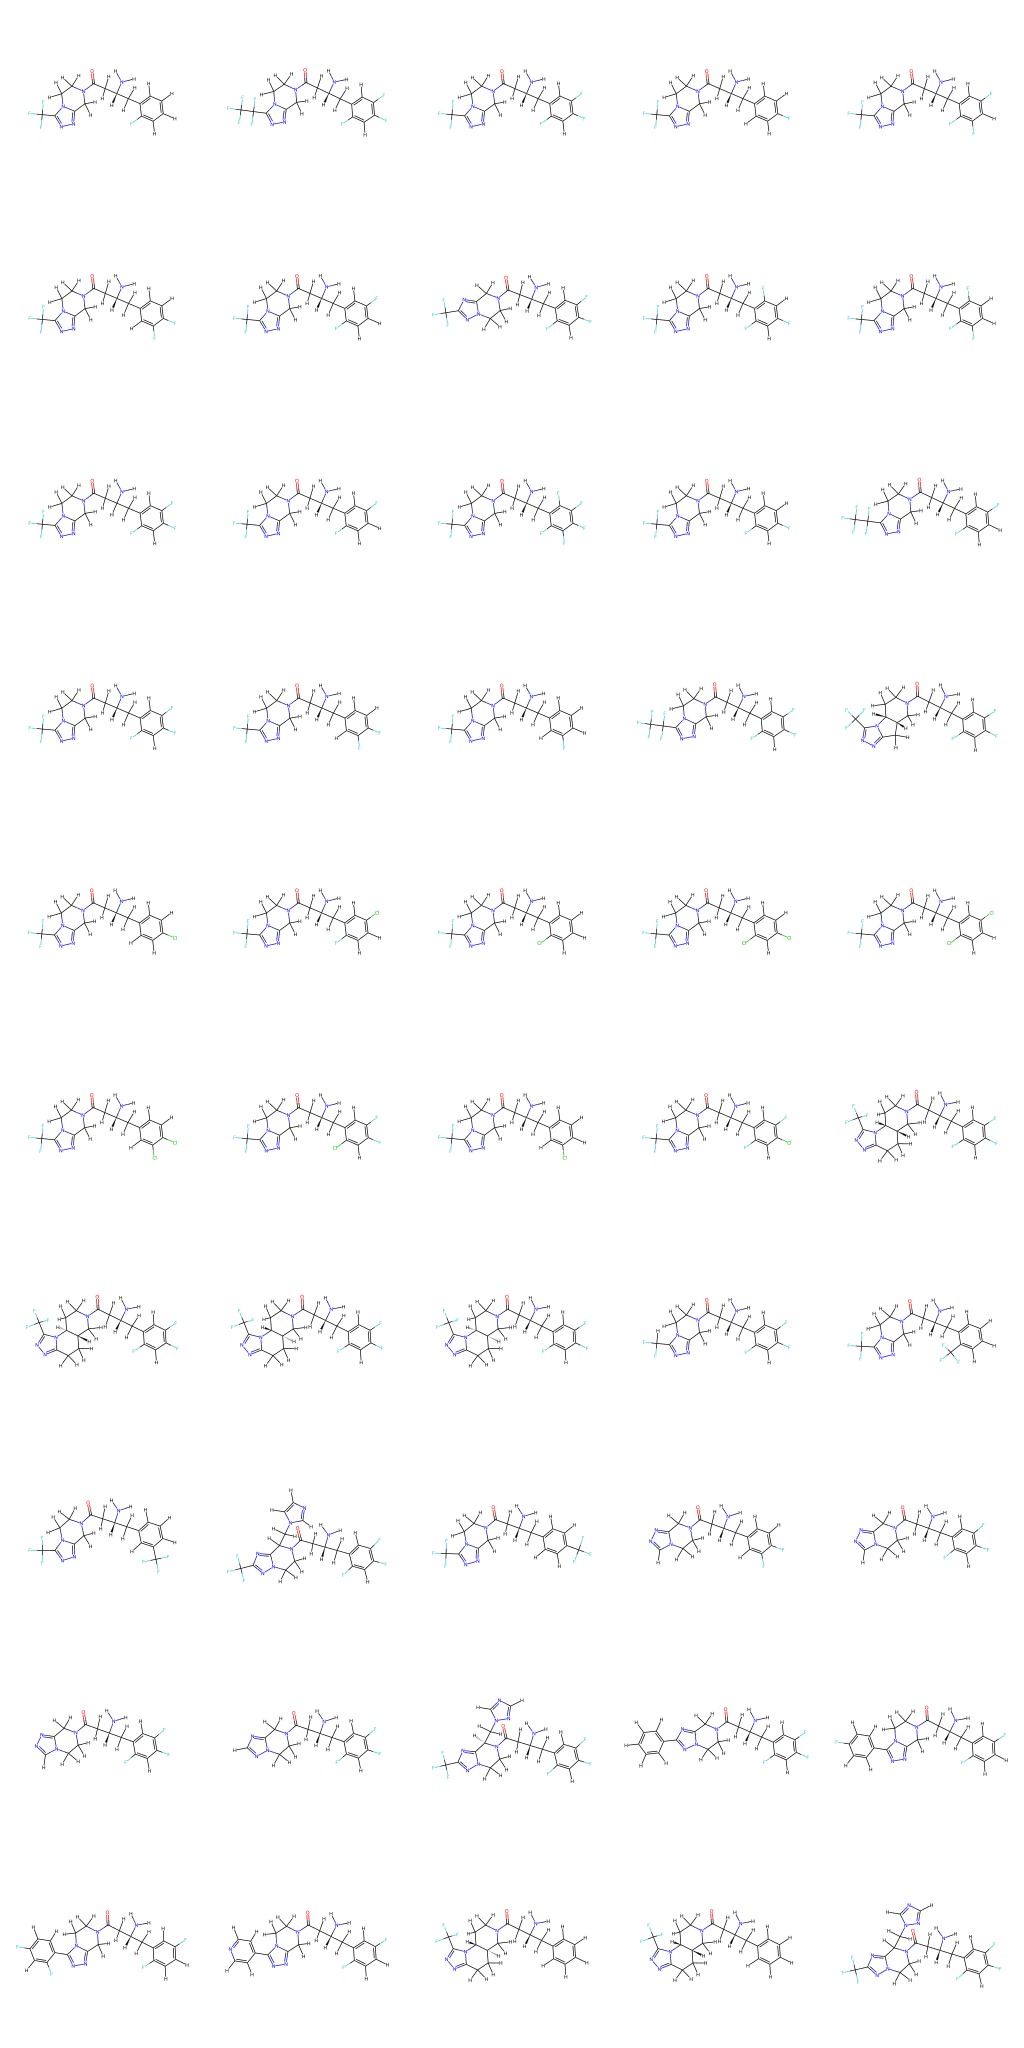

In [119]:
draw_ranked_molecules(cleaned_df, "tanimoto_maccs_fingerprint")

**Morgan fingerprints: Tanimoto similarity and Dice similarity**

Same way as before calculate and add the Tanimoto and Dice similarities between the Morgan fingerprints to the DataFrame (Morgan bit fingerprint).

In [120]:
print(ligand_mol)

# generation of the Morgan bit fingerprint for ligand molecule (100% known that it's interact with target)
molecule_query_morgan_bit = morgan_gen.GetFingerprint(ligand_mol)

# and the list of maccs for all molecules in the dataset (all other molecules in the dataset).
molecule_list_morgan_bit = cleaned_df["Mol"].apply(morgan_gen.GetFingerprint)

print("Query:", molecule_query_morgan_bit)
print("Search", molecule_list_morgan_bit)

Query: <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x181585f50>
Search 0       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...
2       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...
3       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...
4       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
                              ...                        
3088    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3089    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3090    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3091    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3092    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: Mol, Length: 3093, dtype: object


In [121]:
# Calculate similarty values between query and list elements and save in separate columns `tanimoto_morgan_fingerprint_bit` and `dice_morgan_fingerprint_bit` in cleaned_df

tanimoto_morgan = []
dice_morgan = []

for fp in molecule_list_morgan_bit:
    tanimoto = DataStructs.TanimotoSimilarity(molecule_query_morgan_bit, fp)
    dice = DataStructs.DiceSimilarity(molecule_query_morgan_bit, fp)
    tanimoto_morgan.append(tanimoto)
    dice_morgan.append(dice)

cleaned_df["tanimoto_morgan"] = tanimoto_morgan
cleaned_df["dice_morgan"] = dice_morgan

Sort the DataFrame by the Tanimoto similarity of the Morgan fingerprints.

In [122]:
sorted_tanimoto_morgan = cleaned_df.sort_values(by="tanimoto_morgan",ascending=False)
sorted_dice_morgan = cleaned_df.sort_values(by="dice_morgan",ascending=False)

Draw molecules ranked by the Tanimoto similarities of Morgan fingerprints.

/opt/anaconda3/envs/mol_mod/lib/python3.13/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


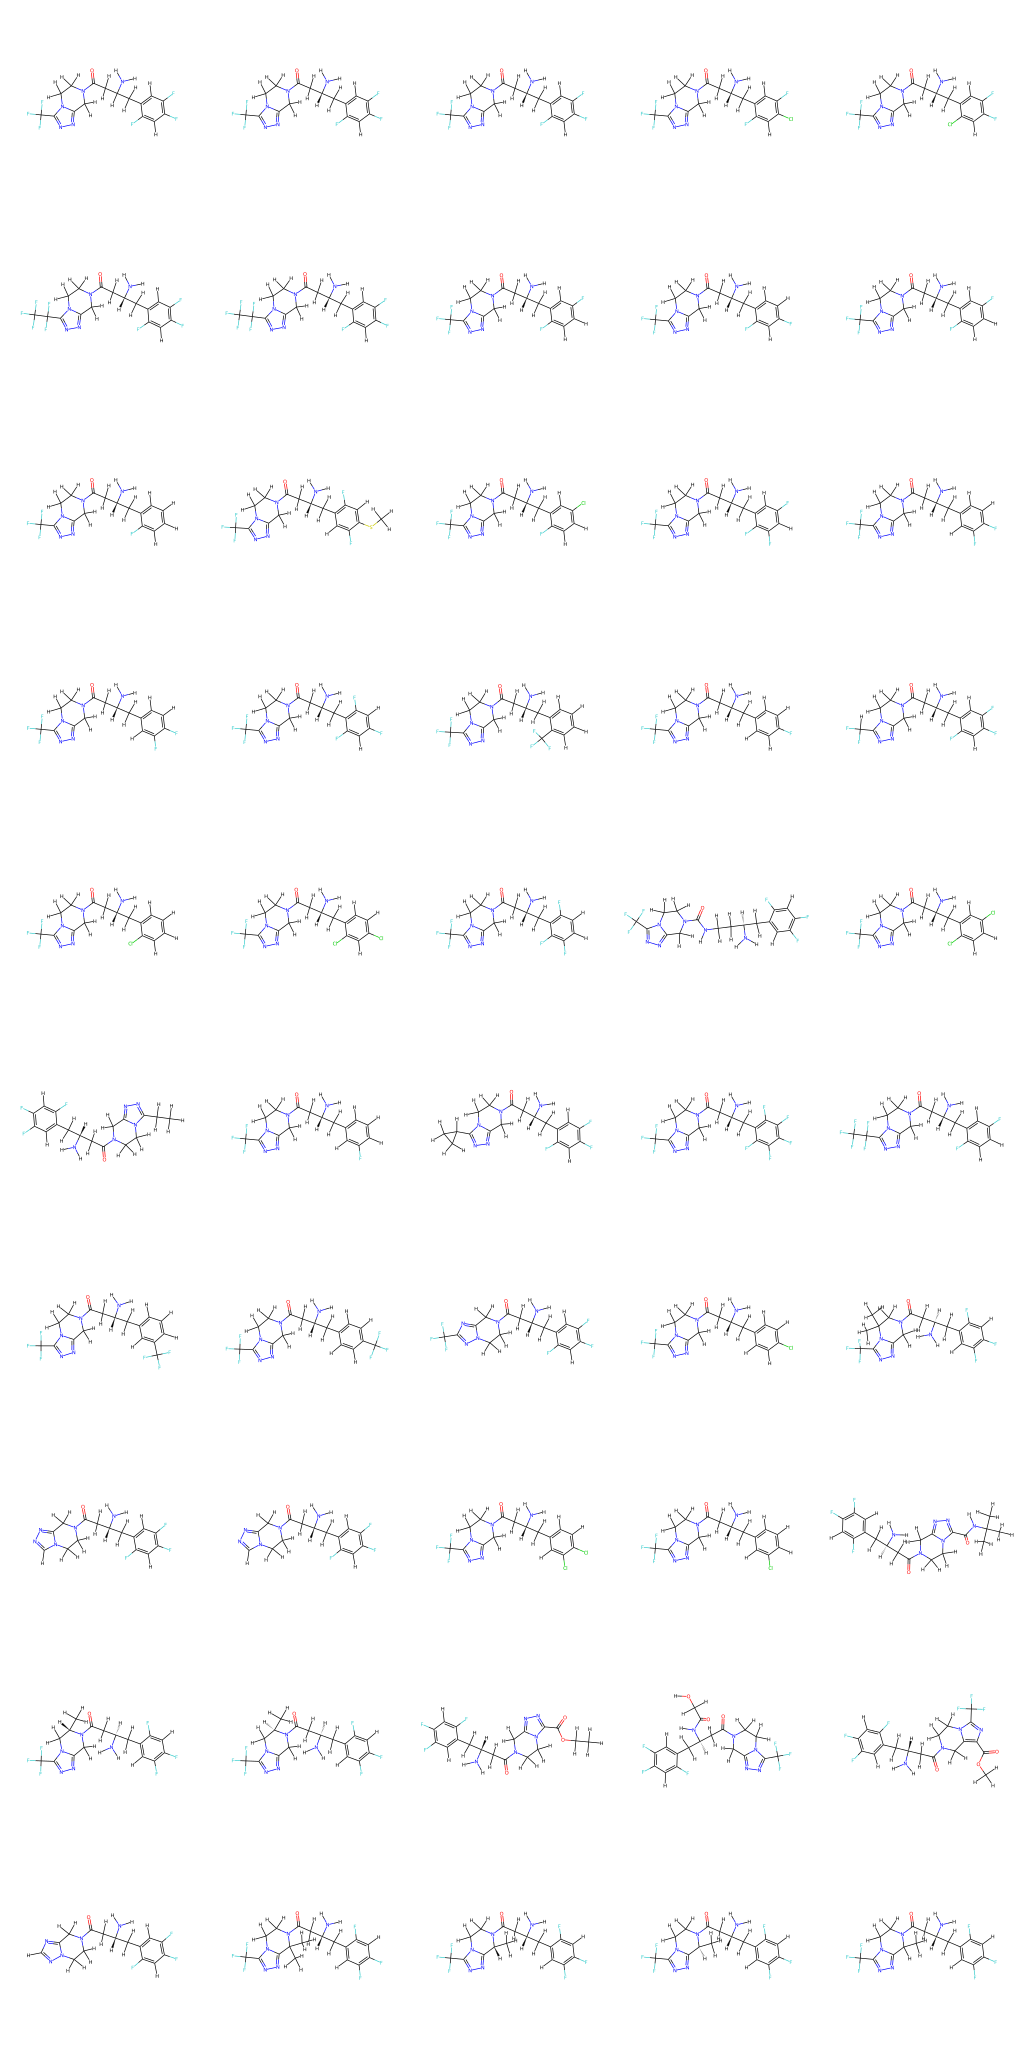

In [123]:
draw_ranked_molecules(cleaned_df, "tanimoto_morgan")

In [124]:
cleaned_df.head(1)

molecule_chembl_id                                             smiles  \
0      CHEMBL2147056  Cc1ccc(F)cc1Cn1c(N2CCC[C@@H](N)C2)nc2c3ccc(C(=...   

                                             Mol  IC50     pIC50  molLogP  \
0  <rdkit.Chem.rdchem.Mol object at 0x18021d8c0>  0.55  8.259637  3.43152   

     tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
0  106.38  499.974                  7           2              8   

   ro5_fulfilled                                              MACCS  \
0           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_int_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_bit_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   rdkit_fingerprint  \
0  [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...   

                                      ap_fingerprint  \
0  [0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0,...   

                                      tt_fingerprint  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

   tanimoto_maccs_fingerprint  dice_maccs_fingerprint  tanimoto_morgan  \
0                    0.658228                0.793893         0.173913   

   dice_morgan  
0     0.296296

The top ranked molecules for AFATINIB are AFATINIB entries (rank 1 and 2) in our dataset, followed by alterations of AFATINIB, e.g. different benzole substitution patterns. 

Now you can compare the Tanimoto similarities based on MACCS and Morgan bit fingerprints. 

Therefore, let's plot the Tanimoto similarities based on Morgen fingerprints vs. the Tanimoto simlarities based on MACCS fingerprints.

# Compare the Similarity of Dice and Tanimoto of all the Fingerprints

What i do in this section is to calculate the Tanimoto and Dice similarity of all the finerprints

In [125]:
# convert ligand into query for Morgan, MACCS, RDKit, AtomPair and TopologicalTorsion fingerprints

# generation of the Morgan bit fingerprint for ligand molecule (100% known that it's interact with target)
molecule_query_morgan_bit = morgan_gen.GetFingerprint(ligand_mol)
molecule_query_maccs = MACCSkeys.GenMACCSKeys(ligand_mol)
molecule_query_rdkit = rdkit_gen.GetFingerprint(ligand_mol)
molecule_query_ap = ap_gen.GetFingerprint(ligand_mol)
molecule_query_tt = tt_gen.GetFingerprint(ligand_mol)

molecule_list_morgan_bit = cleaned_df["Mol"].apply(morgan_gen.GetFingerprint)
molecule_list_maccs = cleaned_df["Mol"].apply(MACCSkeys.GenMACCSKeys)
molecule_list_rdkit = cleaned_df["Mol"].apply(rdkit_gen.GetFingerprint)
molecule_list_ap = cleaned_df["Mol"].apply(ap_gen.GetFingerprint)
molecule_list_tt = cleaned_df["Mol"].apply(tt_gen.GetFingerprint)



# Calculate Dice and Tanimoto For all fingerprints

def calculate_fingerprints_similarity(molecule_list, query_molecule):
    """
    Calculate Tanimoto and Dice similarity for a list of fingerprints against a query fingerprint.

    Parameters
    ----------
    molecule_list : list
        List of fingerprints to compare against the query.
    query_molecule : rdkit.Chem.rdchem.Mol
        Query fingerprint.

    Returns
    -------
    tuple
        Tuple containing two lists: Tanimoto and Dice similarity scores.
    """
    tanimoto_scores = []
    dice_scores = []

    for fp in molecule_list:
        tanimoto = DataStructs.TanimotoSimilarity(query_molecule, fp)
        dice = DataStructs.DiceSimilarity(query_molecule, fp)
        tanimoto_scores.append(tanimoto)
        dice_scores.append(dice)

    return tanimoto_scores, dice_scores


# Calculate Tanimoto and Dice similarity for all fingerprints
tanimoto_morgan, dice_morgan = calculate_fingerprints_similarity(molecule_list_morgan_bit, molecule_query_morgan_bit)


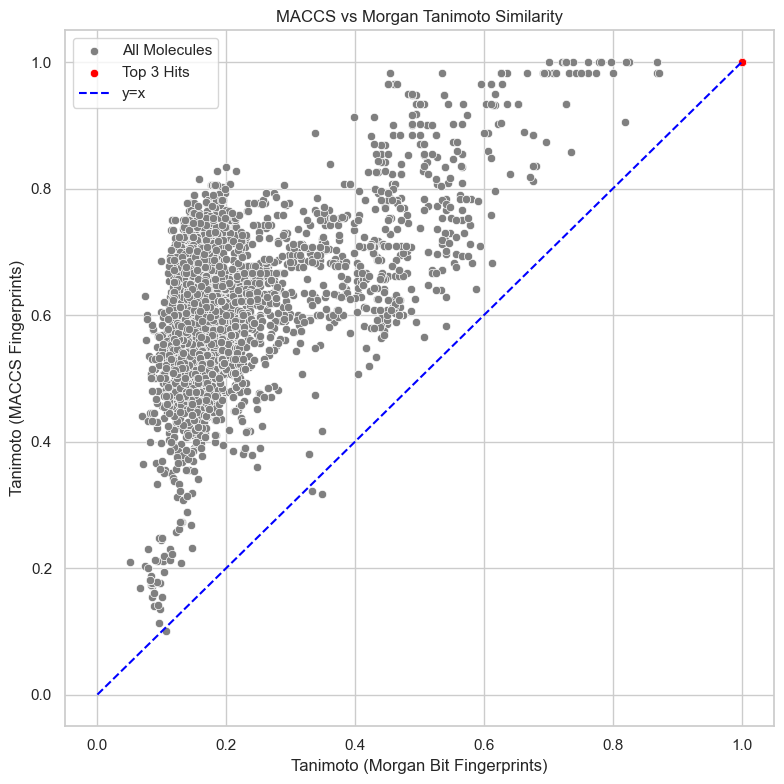

In [126]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,8))
sns.scatterplot(
    x="tanimoto_morgan",
    y="tanimoto_maccs_fingerprint",
    label="All Molecules",
    color="gray",
    data=cleaned_df
)

top_n = 3
top_hits = cleaned_df.sort_values(by="tanimoto_morgan",ascending=False).head(top_n)

sns.scatterplot(
    data=top_hits,
    x="tanimoto_morgan",
    y="tanimoto_maccs_fingerprint",
    label=f"Top {top_n} Hits",
    color="red"
)

# Diagonal Reference Line
plt.plot([0,1],[0,1],ls="--",color="blue",label="y=x")


plt.xlabel("Tanimoto (Morgan Bit Fingerprints)")
plt.ylabel("Tanimoto (MACCS Fingerprints)")
plt.title("MACCS vs Morgan Tanimoto Similarity")
plt.tight_layout()
plt.legend()
plt.show()

Make conclusions based on this plot.

**Distribution of similarity values**

As mentioned previously, compared for the same fingerprint (e.g. MACCS fingerprints), Tanimoto similarity values are lower than Dice similarity values. Also, comparing two different fingerprints (e.g. MACCS and Morgan fingerprints), the similarity measure values (e.g. Tanimotot similarity) vary.

We can have a look at the distributions by plotting histograms.

First, we can plot distribution of Tanimoto similarity of MACCS fingerprints using histogram

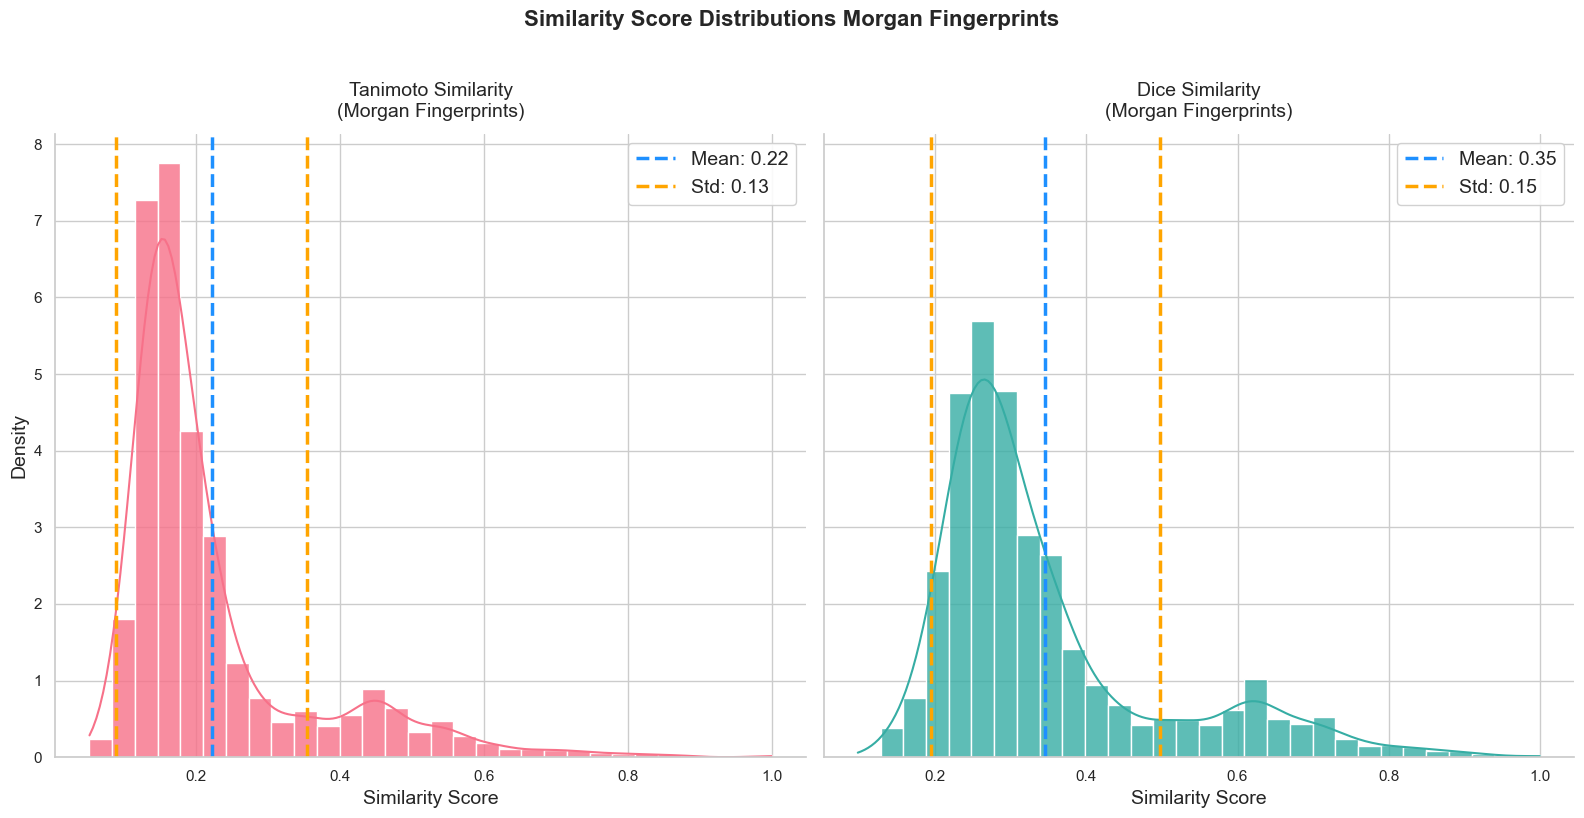

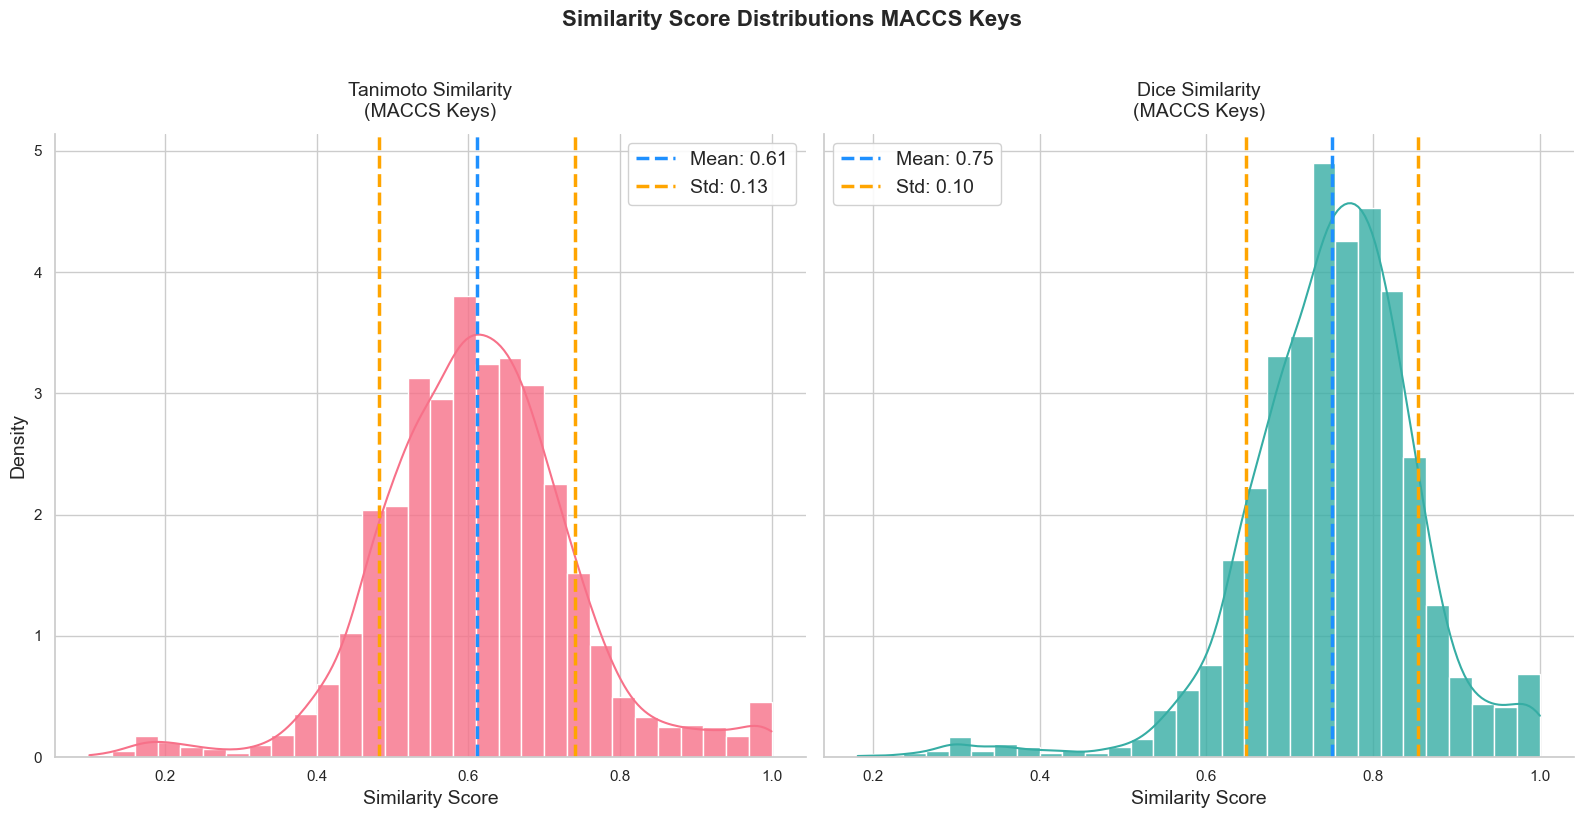

In [127]:
# Compare Distribution of Tanimoto and Dice Similarity Scores in Side by Side Plot

def plot_tanimoto_dice_distribution(df, tanimoto_col, dice_col, title_suffix=""):
    """
    Plot enhanced distribution of Tanimoto and Dice similarity scores with statistical annotations.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the similarity scores.
    tanimoto_col : str
        Column name for Tanimoto similarity scores.
    dice_col : str
        Column name for Dice similarity scores.
    title_suffix : str, optional
        Additional text to append to plot titles (e.g., fingerprint type).
    """
    # Set style and palette
    sns.set_style("whitegrid")
    palette = sns.color_palette("husl", 2)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
    fig.suptitle(f'Similarity Score Distributions {title_suffix}', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # Plot Tanimoto distribution
    sns.histplot(
        data=df, 
        x=tanimoto_col, 
        bins=30, 
        kde=True,
        ax=ax1,
        color=palette[0],
        edgecolor='white',

        alpha=0.8,
        stat='density',
    )
    
    # Add statistical annotations for Tanimoto
    tanimoto_mean = df[tanimoto_col].mean()
    # add std
    tanimoto_std = df[tanimoto_col].std()
    ax1.axvline(tanimoto_mean, color='dodgerblue', linestyle='--', linewidth=2.5, 
                label=f'Mean: {tanimoto_mean:.2f}')
    ax1.axvline(tanimoto_mean + tanimoto_std, color='orange', linestyle='--', linewidth=2.5,
                label=f'Std: {tanimoto_std:.2f}')
    ax1.axvline(tanimoto_mean - tanimoto_std, color='orange', linestyle='--', linewidth=2.5)
    
    ax1.set_title(f"Tanimoto Similarity\n({title_suffix})", fontsize=14, pad=12)
    ax1.set_xlabel("Similarity Score", fontsize=14)
    ax1.set_ylabel("Density", fontsize=14)
    ax1.legend(fontsize=14, framealpha=0.9)
    
    # Plot Dice distribution
    sns.histplot(
        data=df, 
        x=dice_col, 
        bins=30, 
        kde=True,
        ax=ax2,
        color=palette[1],
        edgecolor='white',
        alpha=0.8,
        stat='density',
    )
    
    # Add statistical annotations for Dice
    dice_mean = df[dice_col].mean()
    # add std
    dice_std = df[dice_col].std()
    ax2.axvline(dice_mean, color='dodgerblue', linestyle='--', linewidth=2.5, 
                label=f'Mean: {dice_mean:.2f}')
    ax2.axvline(dice_mean + dice_std, color='orange', linestyle='--', linewidth=2.5,
                label=f'Std: {dice_std:.2f}')
    ax2.axvline(dice_mean - dice_std, color='orange', linestyle='--', linewidth=2.5)


    ax2.set_title(f"Dice Similarity\n({title_suffix})", fontsize=14, pad=12)
    ax2.set_xlabel("Similarity Score", fontsize=14)
    ax2.legend(fontsize=14, framealpha=0.9)
    
  
    
    # Adjust layout
    plt.tight_layout()
    sns.despine()
    plt.savefig(f"tanimoto_dice_distribution_{title_suffix}.png", dpi=300, bbox_inches='tight')
    
    plt.show()

# Example usage
plot_tanimoto_dice_distribution(cleaned_df, "tanimoto_morgan", "dice_morgan", "Morgan Fingerprints")
plot_tanimoto_dice_distribution(cleaned_df, "tanimoto_maccs_fingerprint", "dice_maccs_fingerprint", "MACCS Keys")



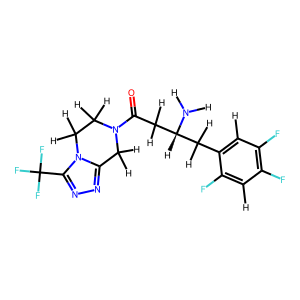

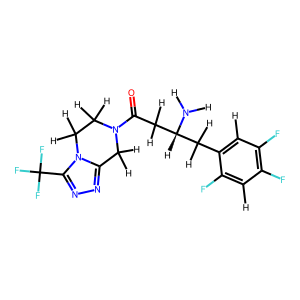

In [128]:
# obtain structure with the highest Tanimoto and Dice similarity scores

def get_top_molecules(df, tanimoto_col, dice_col, top_n=1):
    """
    Get the top N molecules based on Tanimoto and Dice similarity scores.
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the similarity scores.
    tanimoto_col : str
        Column name for Tanimoto similarity scores.
    dice_col : str
        Column name for Dice similarity scores.
    top_n : int
        Number of top molecules to retrieve.
    Returns
    -------
    pandas.DataFrame
        DataFrame containing the top N molecules based on Tanimoto and Dice scores.
    """
    # Sort the DataFrame by Tanimoto and Dice scores
    sorted_df = df.sort_values(by=[tanimoto_col, dice_col], ascending=False)
    
    
    # Get the top N molecules
    top_molecules = sorted_df.head(top_n)
    return top_molecules

# Plot the Top 1 Molecule Based on Tanimoto and Dice Similarity Scores
top_molecule_tanimoto = get_top_molecules(cleaned_df, "tanimoto_morgan", "dice_morgan", top_n=1)
top_molecule_dice = get_top_molecules(cleaned_df, "tanimoto_morgan", "dice_morgan", top_n=1)
top_molecule_tanimoto = top_molecule_tanimoto.iloc[0]
top_molecule_dice = top_molecule_dice.iloc[0]
top_molecule_tanimoto_mol = top_molecule_tanimoto["Mol"]
top_molecule_dice_mol = top_molecule_dice["Mol"]
top_molecule_tanimoto_name = top_molecule_tanimoto["molecule_chembl_id"]
top_molecule_dice_name = top_molecule_dice["molecule_chembl_id"]
top_molecule_tanimoto_img = Draw.MolToImage(top_molecule_tanimoto_mol, size=(300, 300))
top_molecule_dice_img = Draw.MolToImage(top_molecule_dice_mol, size=(300, 300))
display(top_molecule_tanimoto_img)
display(top_molecule_dice_img)

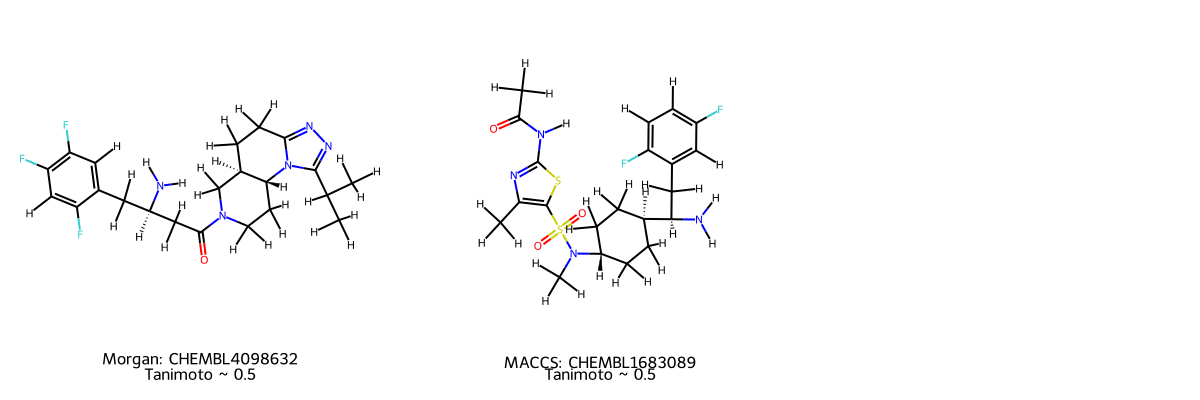

In [129]:
from rdkit.Chem import Draw

# Function to find a molecule with Tanimoto similarity close to a target value
def find_molecule_with_similarity(df, similarity_column, target_similarity, tolerance=0.01):
    """
    Find a molecule with a similarity value close to the target similarity.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing similarity values.
    similarity_column : str
        Column name for the similarity values.
    target_similarity : float
        Target similarity value to search for.
    tolerance : float, optional
        Tolerance for matching the similarity value, by default 0.01.

    Returns
    -------
    pandas.Series
        Row of the DataFrame corresponding to the molecule.
    """
    return df[(df[similarity_column] >= target_similarity - tolerance) & 
              (df[similarity_column] <= target_similarity + tolerance)].iloc[0]

# Find molecules with Tanimoto similarity ~0.5 for Morgan and MACCS fingerprints
target_similarity = 0.5
molecule_morgan = find_molecule_with_similarity(cleaned_df, "tanimoto_morgan", target_similarity)
molecule_maccs = find_molecule_with_similarity(cleaned_df, "tanimoto_maccs_fingerprint", target_similarity)

# Extract the molecules and their names
morgan_mol = molecule_morgan["Mol"]
morgan_name = molecule_morgan["molecule_chembl_id"]

maccs_mol = molecule_maccs["Mol"]
maccs_name = molecule_maccs["molecule_chembl_id"]

# Plot the molecules
img = Draw.MolsToGridImage(
    [morgan_mol, maccs_mol],
    legends=[f"Morgan: {morgan_name}\n \nTanimoto ~ {target_similarity}",
             f"MACCS: {maccs_name}\n \nTanimoto ~ {target_similarity}"],
    subImgSize=(400, 400)
)
img

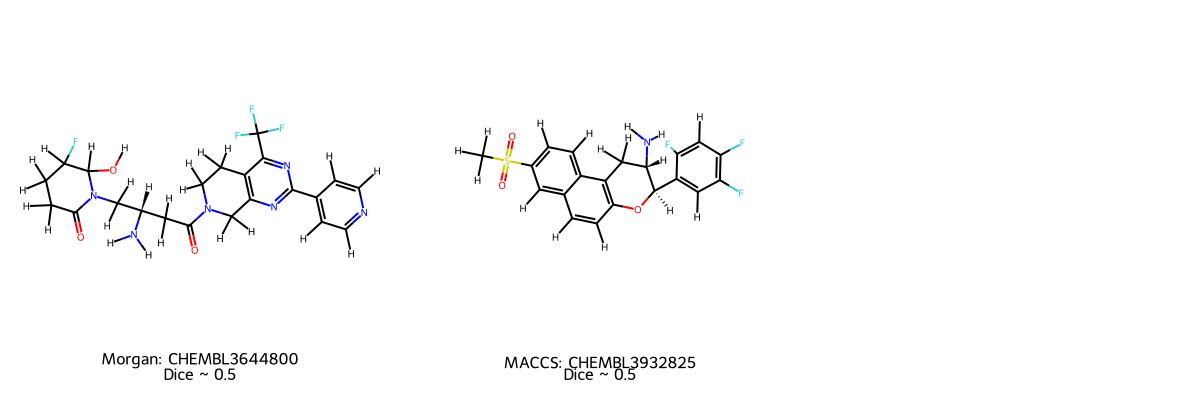

In [130]:
# now do the same for Dice similarity
# Find molecules with Dice similarity ~0.5 for Morgan and MACCS fingerprints
target_similarity = 0.5
molecule_morgan_dice = find_molecule_with_similarity(cleaned_df, "dice_morgan", target_similarity)
molecule_maccs_dice = find_molecule_with_similarity(cleaned_df, "dice_maccs_fingerprint", target_similarity)
# Extract the molecules and their names
morgan_mol_dice = molecule_morgan_dice["Mol"]
morgan_name_dice = molecule_morgan_dice["molecule_chembl_id"]
maccs_mol_dice = molecule_maccs_dice["Mol"]
maccs_name_dice = molecule_maccs_dice["molecule_chembl_id"]
# Plot the molecules
img = Draw.MolsToGridImage(
    [morgan_mol_dice, maccs_mol_dice],
    legends=[f"Morgan: {morgan_name_dice}\n \nDice ~ {target_similarity}",
             f"MACCS: {maccs_name_dice}\n \nDice ~ {target_similarity}"],
    subImgSize=(400, 400)
)
img

**Task**: Make conclusions based on this plots about measuring similarity using different similarity metrics and fingerprints (to calculate this metrics).

Second, you can compare similarities using scatter plot. 

This time, let’s directly compare Tanimoto and Dice similarities for the two fingerprints.

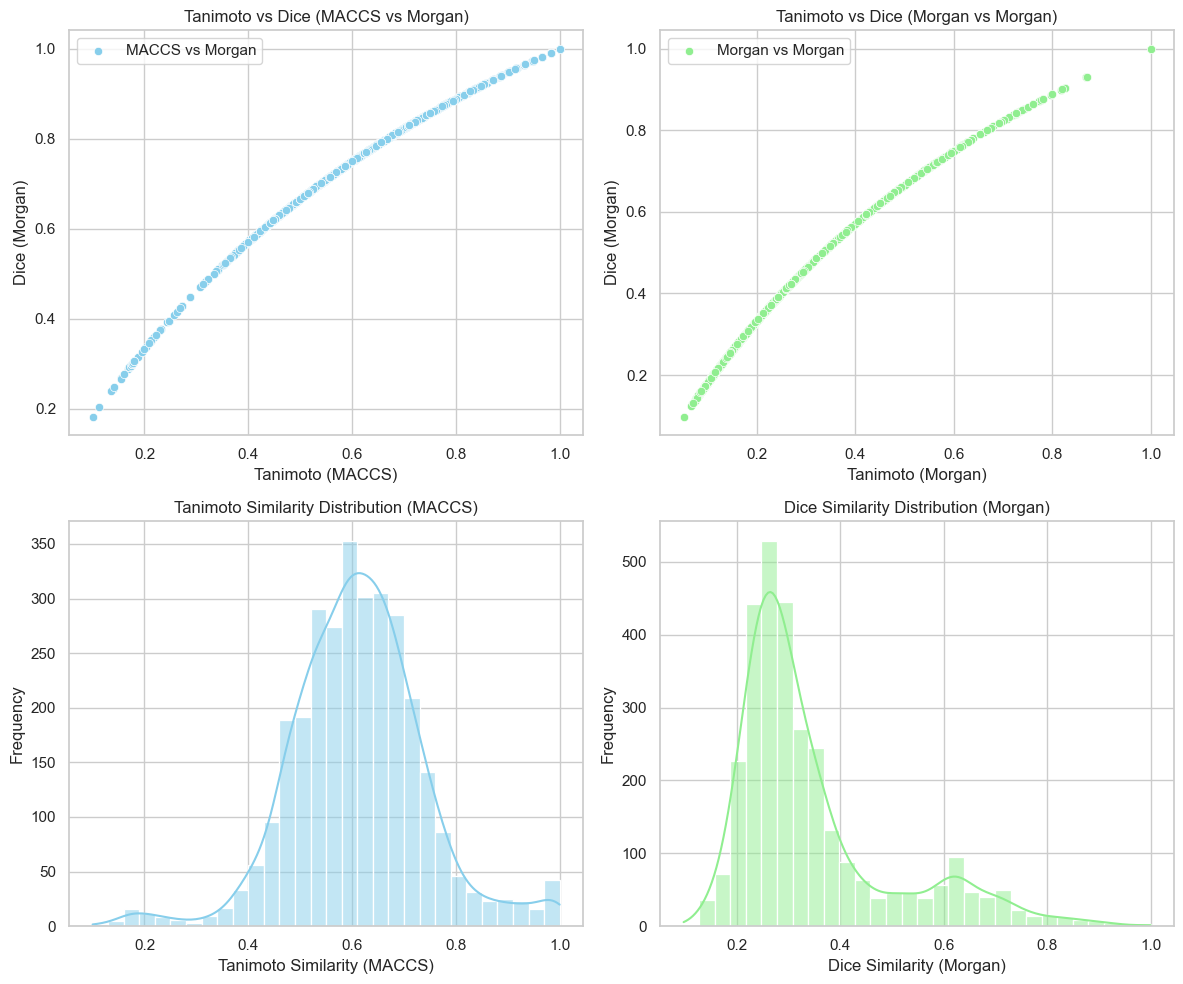

In [131]:
# code for scatter plots that compare Tanimoto and Dice similarities for the two different fingerprints (MACCS and Morgan)


# Create subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot of Tanimoto vs Dice (MACCS)
sns.scatterplot(
    x=cleaned_df["tanimoto_maccs_fingerprint"], y=cleaned_df["dice_maccs_fingerprint"], ax=axes[0, 0],
    color="skyblue", label="MACCS vs Morgan"
)
axes[0, 0].set_xlabel("Tanimoto (MACCS)")
axes[0, 0].set_ylabel("Dice (Morgan)")
axes[0, 0].set_title("Tanimoto vs Dice (MACCS vs Morgan)")

# Scatter plot of Tanimoto vs Dice (Morgan)
sns.scatterplot(
    x=cleaned_df["tanimoto_morgan"], y=cleaned_df["dice_morgan"], ax=axes[0, 1],
    color="lightgreen", label="Morgan vs Morgan"
)
axes[0, 1].set_xlabel("Tanimoto (Morgan)")
axes[0, 1].set_ylabel("Dice (Morgan)")
axes[0, 1].set_title("Tanimoto vs Dice (Morgan vs Morgan)")

# Histogram of Tanimoto similarity for MACCS
sns.histplot(cleaned_df["tanimoto_maccs_fingerprint"], bins=30, kde=True, color="skyblue", ax=axes[1, 0])
axes[1, 0].set_xlabel("Tanimoto Similarity (MACCS)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Tanimoto Similarity Distribution (MACCS)")

# Histogram of Dice similarity for Morgan
sns.histplot(cleaned_df["dice_morgan"], bins=30, kde=True, color="lightgreen", ax=axes[1, 1])
axes[1, 1].set_xlabel("Dice Similarity (Morgan)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Dice Similarity Distribution (Morgan)")

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

The scatter plots compares Tanimoto and Dice similarities for the two different fingerprints (MACCS and Morgan).

**Task**: Make conclusions based on this plots about measuring similarity using different similarity metrics and fingerprints (to calculate this metrics).

# Enrichment plots and their role in validating virtual screening results

Now let's check how well the similarity search is able to distinguish between active and inactive molecules based on our dataset (using similarity and EC50 values). 

In order to validate your virtual screening and see the ratio of detected active molecules, let's generate an enrichment plot.

- Enrichment plots are graphical representations commonly used in the field of computational biology, cheminformatics, and drug discovery.

- They serve as a valuable tool for assessing the effectiveness of virtual screening methods.

- The primary goal of enrichment plots is to evaluate how well virtual screening performs in identifying active compounds (e.g., potential drug candidates) from a large dataset.

- Enrichment plots provide a visual way to evaluate the performance of virtual screening approaches, helping researchers make informed decisions during drug discovery.

An enrichment plot typically consists of two axes:

- **X-Axis (Ranked Dataset Percentage)**: the ratio of top-ranked molecules from the whole dataset
    - Represents the percentage of ranked molecules from the entire dataset by the virtual screening method. So, 0.1 on the x-axis would represent the top 10% of the ranked molecules after a virtual screening experiment.
    - Ranges from 0% (no molecules ranked) to 100% (all molecules ranked).

- **Y-Axis (True Actives Identified Percentage)**: the ratio of active molecules from the whole dataset
    - represents the proportion of active molecules (true positives) found within that percentage. In other words, it shows how enriched the top-ranked list is with active molecules compared to the overall dataset.
    - Also ranges from 0% to 100%.

The plot shows how well the method prioritizes active compounds at different levels of ranking.

An optimal enrichment plot demonstrates the following characteristics:

- Steep initial slope: At the beginning, a high proportion of true actives should be identified. This indicates that the method effectively captures the most promising compounds early on. Steeper the slope - higher enrichment factor --> the rate of discovering true active compounds is most efficient here. This early enrichment region is particularly valuable in virtual screening campaigns, as it allows researchers to focus experimental testing on a small fraction of the database while still capturing a substantial portion of the active compounds. The molecules in this range would have the highest calculated similarity scores to the reference ligand.

- Plateau: As the ranking progresses, the curve levels off. This plateau represents the less informative portion of the ranked dataset.

- Comparison to Random Curve: The enrichment plot is often compared to a random curve (expected performance by chance). A good method should significantly outperform randomness. Line for random curve represents a random selection of molecules. If your enrichment plot follows this line, it means finding active molecules is no better than random chance.

- Comparison to Optimal Curve: The optimal curve represents an ideal scenario where all true actives are identified within a small subset of the ranked dataset. The ideal plot would sharply curve upwards at the beginning, indicating a high concentration of active molecules in the top-ranked positions. As you move down the ranked list (increasing percentage on the x-axis), the curve flattens out as you encounter less frequent active molecules.
While achieving this is unlikely, the method’s performance should approach the optimal curve.



***Example of the plot***

The plot shows three lines:
- Tanimoto/MACCS (blue) and Tanimoto/Morgan (orange) represent virtual screening results using different fingerprint types (MACCS and Morgan) with the Tanimoto coefficient for similarity.
- Random curve (grey dashed) represents the random selection scenario.

In this example, the Tanimoto/Morgan enrichment plot curves upwards more significantly at the beginning, indicating a potentially better performance in identifying active molecules compared to the Tanimoto/MACCS approach.

However, it's important to consider the entire curve and compare it to the random selection line to draw more definitive conclusions.


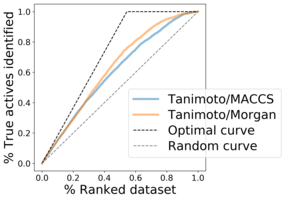

Consider a virtual screening experiment where a large chemical library is ranked based on predicted binding affinity to a specific protein target.
The enrichment plot would show how well the top-ranked compounds (e.g., top 5%, 10%, etc.) capture the true active compounds (known binders to the target).
If the curve rises steeply initially and then levels off, it suggests effective enrichment.
Deviations from the optimal curve indicate the method’s limitations.

Researchers use enrichment plots to:

- Validate virtual screening methods.

- Compare different scoring functions or fingerprint types.

- Optimize parameters (e.g., similarity thresholds) for virtual screening.

- Assess the trade-off between sensitivity and specificity.

Let's compare the Tanimoto similarity for MACCS and Morgan fingerprints.

In [132]:
def get_enrichment_data(molecules, similarity_measure, pic50_cutoff):
    """
    Calculates x and y values for enrichment plot:
        x - % ranked dataset
        y - % true actives identified

    Parameters
    ----------
    molecules : pandas.DataFrame
        Molecules with similarity values to a query molecule.
    similarity_measure : str
        Column name which will be used to sort the DataFrame．
    pic50_cutoff : float
        pIC50 cutoff value used to discriminate active and inactive molecules.

    Returns
    -------
    pandas.DataFrame
        Enrichment data: Percentage of ranked dataset by similarity vs. percentage of identified true actives.
    """

    # Get number of molecules in data set
    molecules_all = len(molecules)

    # Get number of active molecules in data set
    actives_all = sum(molecules["pIC50"] >= pic50_cutoff)

    # Initialize a list that will hold the counter for actives and molecules while iterating through our dataset
    actives_counter_list = []

    # Initialize counter for actives
    actives_counter = 0

    # Note: Data must be ranked for enrichment plots:
    # Sort molecules by selected similarity measure
    molecules.sort_values([similarity_measure], ascending=False, inplace=True)

    # Iterate over the ranked dataset and check each molecule if active (by checking bioactivity)
    for value in molecules["pIC50"]:
        if value >= pic50_cutoff:
            actives_counter += 1
        actives_counter_list.append(actives_counter)

    # Transform number of molecules into % ranked dataset
    molecules_percentage_list = [i / molecules_all for i in range(1, molecules_all + 1)]

    # Transform number of actives into % true actives identified
    actives_percentage_list = [i / actives_all for i in actives_counter_list]

    # Generate DataFrame with x and y values as well as label
    enrichment = pd.DataFrame(
        {
            "% ranked dataset": molecules_percentage_list,
            "% true actives identified": actives_percentage_list,
        }
    )

    return enrichment

Set the pIC50 cutoff used to discriminate active and inactive molecules…

In order to decide whether we treat a molecule as active or inactive, we apply the commonly used pIC50 cutoff value of 6.3. Although there are several suggestions ranging from an pIC50 cutoff values of 5 to 7 in the literature or even to define an exclusion range, following cutoff is reasonable. 

You can evaluate as active molecules with pIC50 >= 7, as inactive pIC50 <= 5, in beetween - through away. You can select this border between active and inactive - depending on research question, dataset, etc. Your decision should be based on pIC50 distribution of your dataset. Think about it.

In [197]:
pic50_cutoff =6.5

In [198]:
cleaned_df.head(2)

molecule_chembl_id                                             smiles  \
1154      CHEMBL3185489  NC(CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F   
629        CHEMBL539077  Cl.N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc...   

                                                Mol  IC50     pIC50  molLogP  \
1154  <rdkit.Chem.rdchem.Mol object at 0x18028d620>  18.0  6.744727   2.0165   
629   <rdkit.Chem.rdchem.Mol object at 0x180202e30>  18.0  6.744727   2.4383   

       tpsa    MolWT  NumRotatableBonds  NumHDonors  NumHAcceptors  \
1154  77.04  407.318                  5           1              5   
629   77.04  443.779                  5           1              5   

      ro5_fulfilled                                              MACCS  \
1154           True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
629            True  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                 morgan_int_fingerprint  \
1154  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
629   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                 morgan_bit_fingerprint  \
1154  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
629   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                      rdkit_fingerprint  \
1154  [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
629   [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   

                                         ap_fingerprint  \
1154  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, ...   
629   [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, ...   

                                         tt_fingerprint  \
1154  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
629   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

      tanimoto_maccs_fingerprint  dice_maccs_fingerprint  tanimoto_morgan  \
1154                         1.0                     1.0              1.0   
629                          1.0                     1.0              1.0   

      dice_morgan  
1154          1.0  
629           1.0

…and get the enrichment for MACCS and Morgan fingerprints (using the Tanimoto similarity).

In [212]:
enrichment_data_maccs = get_enrichment_data(cleaned_df,"tanimoto_maccs_fingerprint",pic50_cutoff)

enrichment_data_morgan = get_enrichment_data(cleaned_df,"tanimoto_morgan",pic50_cutoff)

In [219]:
print(enrichment_data_maccs.head(5))
print(enrichment_data_morgan.head(5))

   % ranked dataset  % true actives identified
0          0.000323                   0.000845
1          0.000647                   0.000845
2          0.000970                   0.000845
3          0.001293                   0.000845
4          0.001617                   0.000845
   % ranked dataset  % true actives identified
0          0.000323                   0.000845
1          0.000647                   0.001691
2          0.000970                   0.002536
3          0.001293                   0.002536
4          0.001617                   0.002536


Show example enrichment data.

In [200]:
enrichment_data = {
    "tanimoto_maccs_fingerprint": enrichment_data_maccs,
    "tanimoto_morgan_fingerprint": enrichment_data_morgan
}

Plot the enrichment data next to the optimal and random enrichment curve.

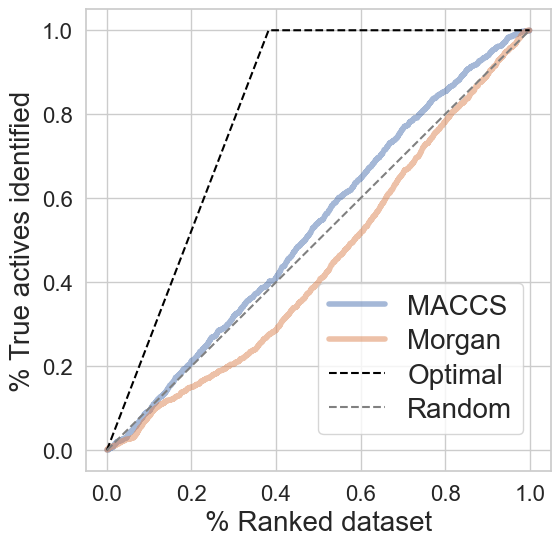

In [201]:
fig, ax = plt.subplots(figsize=(6, 6))

fontsize = 20

# Plot enrichment data
for similarity_measure, enrichment in enrichment_data.items():
    ax = enrichment.plot(
        ax=ax,
        x="% ranked dataset",
        y="% true actives identified",
        label=similarity_measure,
        alpha=0.5,
        linewidth=4,
    )
ax.set_ylabel("% True actives identified", size=fontsize)
ax.set_xlabel("% Ranked dataset", size=fontsize)

# Plot optimal curve: Ratio of actives in dataset
ratio_actives = sum(cleaned_df["pIC50"] >= pic50_cutoff) / len(cleaned_df)
ax.plot(
    [0, ratio_actives, 1],
    [0, 1, 1],
    label="Optimal curve",
    color="black",
    linestyle="--",
)

# Plot random curve
ax.plot([0, 1], [0, 1], label="Random curve", color="grey", linestyle="--")

plt.tick_params(labelsize=16)
plt.legend(
    labels=["MACCS", "Morgan", "Optimal", "Random"],
    loc=(0.5, 0.08),
    fontsize=fontsize,
    labelspacing=0.3,
)

plt.show()

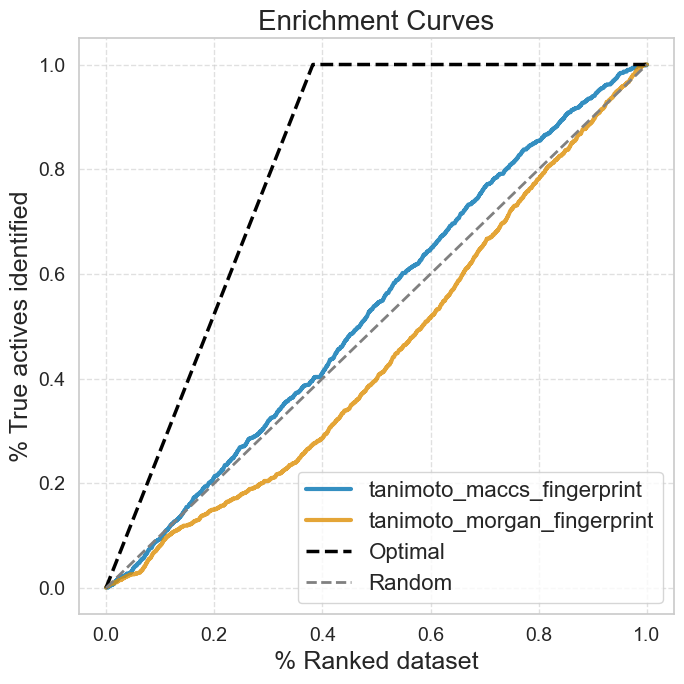

In [202]:
# Use a clean style
sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(7, 7))  # Slightly larger for better spacing
fontsize = 18

# Plot enrichment data
color_palette = sns.color_palette("colorblind", len(enrichment_data))
for (similarity_measure, enrichment), color in zip(enrichment_data.items(), color_palette):
    ax = enrichment.plot(
        ax=ax,
        x="% ranked dataset",
        y="% true actives identified",
        label=similarity_measure,
        alpha=0.8,
        linewidth=3,
        color=color,
    )

# Axis labels
ax.set_ylabel("% True actives identified", size=fontsize)
ax.set_xlabel("% Ranked dataset", size=fontsize)

# Plot optimal curve
ratio_actives = sum(cleaned_df["pIC50"] >= pic50_cutoff) / len(cleaned_df)
ax.plot(
    [0, ratio_actives, 1],
    [0, 1, 1],
    label="Optimal",
    color="black",
    linestyle="--",
    linewidth=2.5,
)

# Plot random curve
ax.plot([0, 1], [0, 1], label="Random", color="grey", linestyle="--", linewidth=2)

# Adjust ticks and legend
ax.tick_params(labelsize=14)
ax.legend(loc="lower right", fontsize=fontsize - 2, frameon=True)

# Optional: Add grid and title
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_title("Enrichment Curves", fontsize=fontsize + 2)

plt.tight_layout()
plt.savefig("enrichment_curves.png", dpi=300, bbox_inches='tight')
plt.show()

**Task**: Make conclusions based on this plot and answer following questions:
1) Which fingerprints show better performance? why? 
2) How did you understand it?
3) Which other conclusions you can make based on it?
4) Where on this plot you can see most active molecules with highest similarity to real ligand?

### Enrichment factor


The (experimental) enrichment factor (EF) is used to access a methods success by a single number rather than a plot. The idea is to determine the percentage of active molecules in the top x% (e.g. 5%, 10%, etc) of ranked molecules, as defined by the following helper function.

The Enrichment Factor at x% is calculated as: `EF(x%) = (% of actives found at x% of dataset) / x%`

For example, if your MACCS fingerprint has an EF at 5% of 7.0/5.0 = 1.4, meaning it's finding actives at 1.4× the rate of random selection.

Now let's alculate enrichment factors

In [221]:
def calculate_enrichment_factor(enrichment, ranked_dataset_percentage_cutoff):
    """
    Get the experimental enrichment factor for a given percentage of the ranked dataset.

    Parameters
    ----------
    enrichment : pd.DataFrame
        Enrichment data: Percentage of ranked dataset by similarity vs. percentage of
        identified true actives.
    ranked_dataset_percentage_cutoff : float or int
        Percentage of ranked dataset to be included in enrichment factor calculation.

    Returns
    -------
    float
        Experimental enrichment factor.
    """
    ranked_dataset_percentage_cutoff = float(ranked_dataset_percentage_cutoff)/100
    

    subset = enrichment[enrichment["% ranked dataset"] <= ranked_dataset_percentage_cutoff]
    max_active = subset["% true actives identified"].max()
    enrichment_factor = max_active / ranked_dataset_percentage_cutoff
    return enrichment_factor 

This helper function calculates the random enrichment of active molecules in the top x% of ranked molecules (random enrichment factor).

In [222]:
def calculate_enrichment_factor_random(ranked_dataset_percentage_cutoff):
    """
    Get the random enrichment factor for a given percentage of the ranked dataset.

    Parameters
    ----------
    ranked_dataset_percentage_cutoff : float or int
        Percentage of ranked dataset to be included in enrichment factor calculation.

    Returns
    -------
    float
        Random enrichment factor.
    """

    return 1.0

And this helper function calculates the optimal enrichment of active molecules in the top x% of ranked molecules (optimal enrichment factor). The random and optimal enrichment factors are needed to judge how good the experimental enrichment factor for a method is.

In [223]:
def calculate_enrichment_factor_optimal(molecules, ranked_dataset_percentage_cutoff, pic50_cutoff):
    """
    Get the optimal random enrichment factor for a given percentage of the ranked dataset.

    Parameters
    ----------
    molecules : pandas.DataFrame
        the DataFrame with all the molecules and pIC50.
    ranked_dataset_percentage_cutoff : float or int
        Percentage of ranked dataset to be included in enrichment factor calculation.
    activity_cutoff: float
        pIC50 cutoff value used to discriminate active and inactive molecules

    Returns
    -------
    float
        Optimal enrichment factor.
    """

    ratio = sum(molecules["pIC50"] >= pic50_cutoff) / len(molecules) * 100
    if ranked_dataset_percentage_cutoff <= ratio:
        enrichment_factor_optimal = round(100 / ratio * ranked_dataset_percentage_cutoff, 1)
    else:
        enrichment_factor_optimal = 100.0
    return enrichment_factor_optimal

After preparation all of the helper functions let's calculate the experimental enrichment factor (EF) for 5% of ranked dataset.

In [224]:
ranked_dataset_percentage_cutoff = 5

In [225]:
for similarity_measure, enrichment in enrichment_data.items():
    enrichment_factor = calculate_enrichment_factor(enrichment, ranked_dataset_percentage_cutoff)
    print(
        f"Experimental EF for {ranked_dataset_percentage_cutoff}% of ranked dataset ({similarity_measure}): {enrichment_factor}"
    )

Experimental EF for 5% of ranked dataset (tanimoto_maccs_fingerprint): 0.7269653423499578
Experimental EF for 5% of ranked dataset (tanimoto_morgan_fingerprint): 0.5240912933220625


And now let's compare it to the random and optimal enrichment factor.

In [226]:
enrichment_factor_random = calculate_enrichment_factor_random(ranked_dataset_percentage_cutoff)
print(
    f"Random EF for {ranked_dataset_percentage_cutoff}% of ranked dataset: {enrichment_factor_random}"
)
enrichment_factor_optimal = calculate_enrichment_factor_optimal(
    cleaned_df, ranked_dataset_percentage_cutoff, pic50_cutoff
)
print(
    f"Optimal EF for {ranked_dataset_percentage_cutoff}% of ranked dataset: {enrichment_factor_optimal}"
)

Random EF for 5% of ranked dataset: 1.0
Optimal EF for 5% of ranked dataset: 13.1


**Task**: how to check where/when (on which %) highest-similarity active compounds ends?

For that you need to analyze how the Enrichment Factor (EF) changes across different percentage thresholds.  

So calculate EF for range (5, 50) with step 5:
1) 5%
2) 5+5=10%
3) 10%+5%=15%
...
4) 50%

and you can see and evaluate changing in EF to easily say where/when (on which %) highest-similarity active compounds ends.

In [227]:
# Calculate EFs (experimental) for range of percentage

enrichment_data_maccs = get_enrichment_data(cleaned_df,"tanimoto_maccs_fingerprint",pic50_cutoff)

enrichment_data_morgan = get_enrichment_data(cleaned_df,"tanimoto_morgan",pic50_cutoff)
# Calculate EFs (experimental) for range of percentages
# Calculate enrichment ratio (experimental/random)
# Analyse changes in them to answer the question

# code for that
def calculate_enrichment_over_range(enrichment_df,method_name=""):
    """ 
    Calculates the Enrichment Factor for a given method with a ratio over 5 % to 50%
    """
    results = []
    for cutoff in range(5,51,1):
        experimental_ef = calculate_enrichment_factor(enrichment_df,cutoff)
        random_ef = 1.0
        ratio = experimental_ef / random_ef
        results.append({
            "Cutoff (%)": cutoff,
            "Experimental EF": round(experimental_ef,3),
            "Random EF": round(random_ef,3),
            "Enrichment Ratio": round(ratio,3)

        })
    df_results = pd.DataFrame(results)
    print(f"\n ===== Enrichment Analysis for {method_name} =====")
    print(df_results.to_string(index=False))
    return df_results

ef_results_maccs = calculate_enrichment_over_range(enrichment_data_maccs,method_name="Tanimoto Maccs")
ef_results_morgan = calculate_enrichment_over_range(enrichment_data_morgan,method_name="Tanimoto Morgan")

# Check if entries of Expermental are the same in both dataframes

print("Experimental EF for Maccs and Morgan are the same")
print(ef_results_maccs["Experimental EF"].equals(ef_results_morgan["Experimental EF"]))



# code for that


 ===== Enrichment Analysis for Tanimoto Maccs =====
 Cutoff (%)  Experimental EF  Random EF  Enrichment Ratio
          5            0.727        1.0             0.727
          6            0.789        1.0             0.789
          7            0.809        1.0             0.809
          8            0.930        1.0             0.930
          9            0.958        1.0             0.958
         10            0.930        1.0             0.930
         11            0.984        1.0             0.984
         12            1.000        1.0             1.000
         13            0.988        1.0             0.988
         14            0.996        1.0             0.996
         15            1.031        1.0             1.031
         16            1.041        1.0             1.041
         17            1.049        1.0             1.049
         18            1.057        1.0             1.057
         19            1.050        1.0             1.050
         20        

Analyse received data and make conclusions based on it.

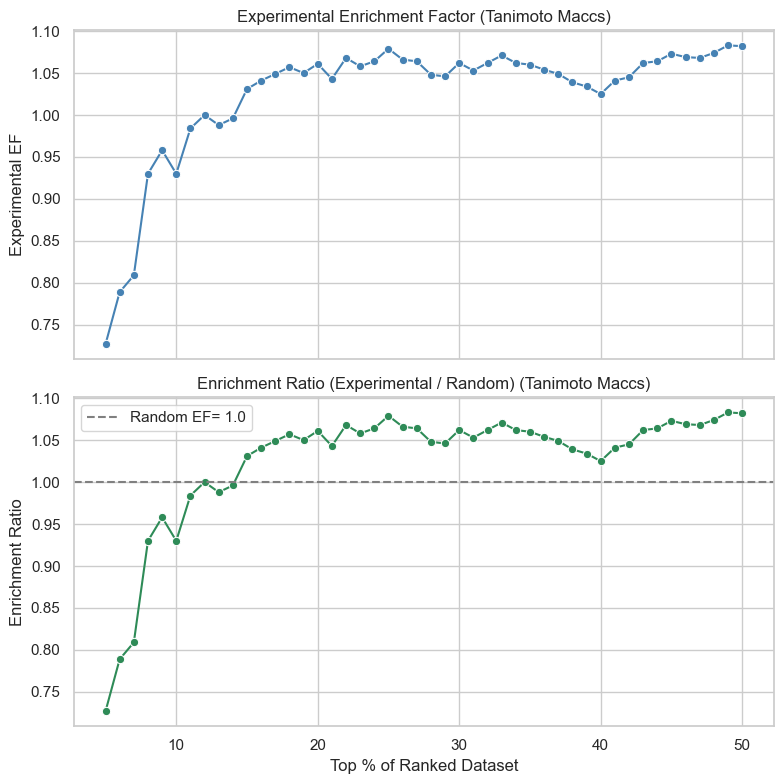

In [228]:
def plot_ef_and_ratio(df_results, method_name):
    """
    Plots both Experimental EF and Enrichment Ratio vs Ranked Dataset %
    """

    sns.set(style="whitegrid")
    fix,axes = plt.subplots(2,1, figsize=(8,8), sharex=True)

    # Plot Experimental EF
    sns.lineplot(
        x="Cutoff (%)",
        y = "Experimental EF",
        data=df_results,
        marker="o",
        ax=axes[0],
        color="steelblue"
    )
    axes[0].set_title(f"Experimental Enrichment Factor ({method_name})")
    axes[0].set_ylabel("Experimental EF")

    # plot enrichment Ratio
    sns.lineplot(
        x="Cutoff (%)",
        y = "Enrichment Ratio",
        data=df_results,
        marker="o",
        ax=axes[1],
        color="seagreen"
    )
    axes[1].axhline(1.0, color="gray", linestyle="--",label="Random EF= 1.0")
    axes[1].set_title(f"Enrichment Ratio (Experimental / Random) ({method_name})")
    axes[1].set_xlabel("Top % of Ranked Dataset")
    axes[1].set_ylabel("Enrichment Ratio")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_ef_and_ratio(ef_results_maccs,method_name="Tanimoto Maccs")

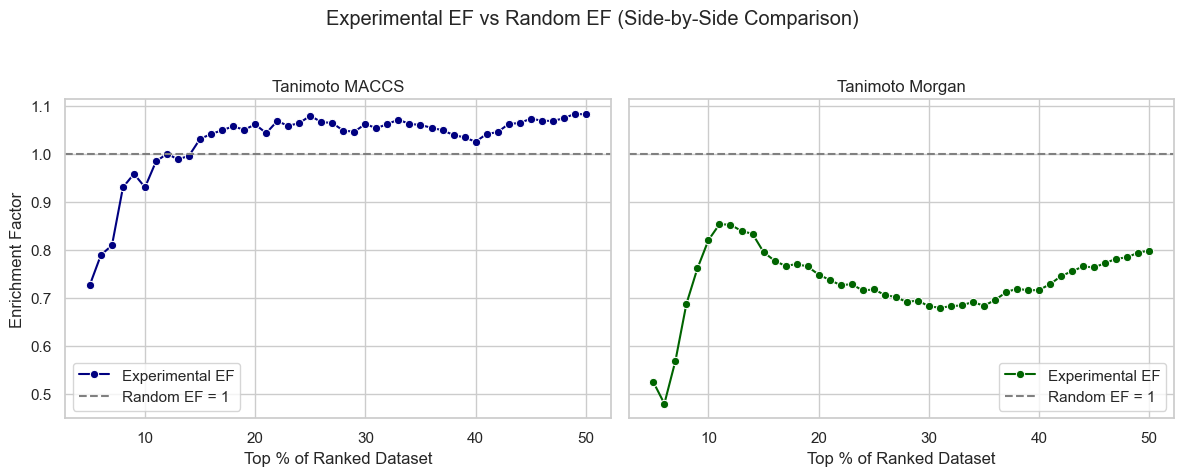

In [229]:
def plot_ef_side_by_side(df_maccs,df_morgan, method1="Tanimoto MACCS", method2="Tanimoto Morgan"):
    """
    Side-by-side plot of Experimental EF vs. % Ranked Dataset for two fingerprint methods.
    """
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # MACCS Plot
    sns.lineplot(
        x="Cutoff (%)", 
        y="Experimental EF", 
        data=df_maccs, 
        marker="o", 
        ax=axes[0], 
        color="navy",
        label="Experimental EF"
    )
    axes[0].axhline(1.0, color='gray', linestyle='--', label='Random EF = 1')
    axes[0].set_title(method1)
    axes[0].set_xlabel("Top % of Ranked Dataset")
    axes[0].set_ylabel("Enrichment Factor")
    axes[0].legend()

    # Morgan Plot
    sns.lineplot(
        x="Cutoff (%)", 
        y="Experimental EF", 
        data=df_morgan, 
        marker="o", 
        ax=axes[1], 
        color="darkgreen",
        label="Experimental EF"
    )
    axes[1].axhline(1.0, color='gray', linestyle='--', label='Random EF = 1')
    axes[1].set_title(method2)
    axes[1].set_xlabel("Top % of Ranked Dataset")
    axes[1].legend()

    plt.suptitle("Experimental EF vs Random EF (Side-by-Side Comparison)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("enrichment_factor.png", dpi=700, bbox_inches="tight")
    plt.show()


plot_ef_side_by_side(ef_results_maccs,ef_results_morgan)

**Virtual screening using molecular fingerprints like MACCS and Morgan (ECFP) is a common approach in drug design, but it's just one tool in an increasingly sophisticated toolkit.**

**Result of your today's work PART 5**: you have learned how to use fingerprints and similarity measures to compare a query molecule with a dataset of molecules and rank the molecule by similarity. This approach is an example for virtual screening of molecules. Enrichment plots and enrichment factors can be used to assess the performance.

A drawback of a similarity search with molecular fingerprints is that it is based on molecular similarity and thus does not yield any novel structures. Another challenge when working with molecular similarity are so-called activity cliffs, i.e. a small change in a functional group of a molecule may initiate a jump in bioactivity.

**Questions to answer**:
- What could be a starting point to circumvent activity cliffs?
    - A bit explanation: activity cliffs represent one of the most challenging phenomena in drug discovery - regions where small structural changes in molecules lead to dramatic differences in biological activity. These cliffs pose particular problems for fingerprint-based methods, as they violate the fundamental "similarity principle" that underpins most virtual screening approaches.
- What are the advantages and disadvantages of MACCS and Morgan fingerprints compared to each other fingerprints?
- How can you explain the different orders in the similarity dataframe depending on the fingerprint used?